# Nanoplastics scRNA-seq — immune response to polystyrene nanoparticles

Single-cell RNA-seq of human PBMCs from **one donor**, exposed to carboxylated
polystyrene nanoparticles (PSNPs) of differing size.

| Sample label | Exposure | Source file |
|---|---|---|
| `40nm` | 40 nm PSNPs | `filtered_feature_bc_matrix.h5ad` |
| `200nm` | 200 nm PSNPs | `filtered_feature_bc_matrix_Sample2.h5ad` |
| `mixture` | 40 nm + 200 nm | `filtered_feature_bc_matrix_Sample3.h5ad` |
| `control` | no exposure | `filtered_feature_bc_matrix_Sample4.h5ad` |

The research question is how **particle size** shapes the immune response.

> **Known limitation, stated up front:** all four samples come from a single donor.
> There is no donor-level biological replication anywhere in this dataset. This
> constrains every statistical claim made later, especially the differential
> expression in Section 13, and is flagged again there rather than papered over.


---

## Section 1 — Load the four samples

**Task 1 — QC & preprocessing**

These `.h5ad` files already went through a Seurat pipeline — `X` is Seurat's own
normalized/log data, and `obs`/`obsm`/`var` carry its QC calls, HVGs, PCA/UMAP and
clusters. **We reprocess from `layers['counts']` instead**, ignoring all of that:
choosing our own QC, normalization, HVG, batch correction and clustering *is*
Tasks 1–2, so inheriting Seurat's would skip the assignment.

**A `Sample` label is attached at load time**, before anything merges — no
sample/condition column exists in any of the four files, and Section 4's
concatenation would make that information unrecoverable once merged. We use an
explicit label→filename mapping rather than parsing it from the filename, since the
filenames (`Sample2`/`Sample3`/`Sample4`) don't encode particle size.

**Samples stay separate through Sections 1–3**, not bundled into one loading
function — QC thresholds must be picked from each sample's own distribution,
which means stopping to look at four distributions before filtering anything.


In [1]:
from importlib.metadata import version
from pathlib import Path

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

sc.settings.verbosity = 1

# Read versions from package metadata rather than `sc.__version__`, which scanpy
# 1.11 has deprecated and which emits a FutureWarning on access.
for pkg in ('scanpy', 'anndata', 'numpy', 'pandas'):
    print(f'{pkg:<8} {version(pkg)}')

scanpy   1.11.5
anndata  0.11.4
numpy    1.26.4
pandas   2.3.3


In [2]:
# Paths are relative to the notebook so this runs unchanged on Windows and Linux.
DATA_DIR = Path.cwd()

# Explicit label -> filename mapping. The labels, not the filenames, are what every
# later section groups by, so they name the exposure rather than the file order.
SAMPLES = {
    '40nm':    'filtered_feature_bc_matrix.h5ad',
    '200nm':   'filtered_feature_bc_matrix_Sample2.h5ad',
    'mixture': 'filtered_feature_bc_matrix_Sample3.h5ad',
    'control': 'filtered_feature_bc_matrix_Sample4.h5ad',
}

# Cell counts expected from inspecting the files. Asserting against these catches a
# silently mis-read or truncated file, which would otherwise surface much later as an
# unexplained composition shift in Task 4.
EXPECTED_CELLS = {'40nm': 8729, '200nm': 12676, 'mixture': 6157, 'control': 6516}

for label, filename in SAMPLES.items():
    status = 'found' if (DATA_DIR / filename).exists() else 'MISSING'
    print(f'{label:<8} {filename:<45} {status}')

40nm     filtered_feature_bc_matrix.h5ad               found
200nm    filtered_feature_bc_matrix_Sample2.h5ad       found
mixture  filtered_feature_bc_matrix_Sample3.h5ad       found
control  filtered_feature_bc_matrix_Sample4.h5ad       found


### Which inherited columns to carry forward

Keep `predicted.celltype` + its confidence score (Azimuth benchmark for Section 11b);
drop everything else — duplicated, recomputed by us later, or not present in all 4
files anyway.


In [3]:
# Which inherited Seurat obs columns to carry forward.
#
# Kept - these are the benchmark. The files already contain a completed Azimuth run
# against the PBMC reference, done by someone else. Section 11b uses it to check our
# own annotation, so it must survive the reduction to counts.
#   'predicted.celltype'        the inherited label itself
#   'predicted.celltype.score'  its confidence, so we can ask whether disagreements
#                               concentrate in low-confidence cells (informative) or
#                               in high-confidence ones (a real problem)
#
# Dropped, with reasons:
#   'predicted.id'              duplicates 'predicted.celltype' in Azimuth output
#   'prediction.score.max'      duplicates 'predicted.celltype.score'
#   'seurat_clusters',          Seurat's clustering. We produce our own in Section 9;
#   'RNA_snn_res.0.3'           keeping theirs only invites confusing the two
#   'nCount_RNA',               Seurat's depth/complexity metrics. Section 3
#   'nFeature_RNA'              recomputes equivalents from our counts as
#                               'total_counts'/'n_genes_by_counts'
#   'prediction.score.<type>'   not present in all four files, so sc.concat would
#                               drop them in Section 4 regardless
#
# The full original files stay on disk unchanged, so anything dropped here can be
# recovered by re-reading them - nothing is lost, only kept out of the working object.
OBS_KEEP = ['predicted.celltype', 'predicted.celltype.score']


def load_sample(filename, label):
    """Load one .h5ad, reduce it to raw counts + chosen metadata, and label it."""
    adata = sc.read_h5ad(DATA_DIR / filename)

    # Seurat left .X normalized and log-transformed. layers['counts'] holds the raw
    # integers, so promote those to .X - everything downstream starts from counts.
    # layers['counts'] is kept as well: CLAUDE.md requires raw counts stay available
    # for pseudobulk DE in Section 13.
    #
    # Downcast float64 -> float32 here. These are integer counts with a maximum around
    # 14,000, and float32 represents every integer exactly up to 2**24 = 16,777,216 --
    # so this is lossless, not a precision tradeoff. It halves memory for the rest of
    # the pipeline, and float32 is what scanpy works in internally; leaving float64
    # would only mean converting later, or carrying double the memory through Section 7
    # where scaling densifies the matrix.
    counts = adata.layers['counts'].astype(np.float32)
    adata.X = counts.copy()
    adata.layers['counts'] = counts

    # Drop Seurat's embeddings and variable-feature stats. We recompute all of it.
    for key in list(adata.obsm.keys()):
        del adata.obsm[key]
    for key in list(adata.varm.keys()):
        del adata.varm[key]
    adata.var = adata.var[[]].copy()   # keeps the gene index, drops the columns
    adata.uns = {}

    adata.obs = adata.obs[[c for c in OBS_KEEP if c in adata.obs.columns]].copy()
    adata.obs['Sample'] = label

    # Barcodes are only unique within a sample (all carry the same '-1' suffix), so
    # prefix them now. Section 4's concat would otherwise silently create duplicates.
    adata.obs_names = [f'{label}_{bc}' for bc in adata.obs_names]

    return adata

In [4]:
adatas = {label: load_sample(filename, label) for label, filename in SAMPLES.items()}

for label, adata in adatas.items():
    print(f'{label:<8} {adata.n_obs:>6,} cells x {adata.n_vars:,} genes')

40nm      8,729 cells x 22,613 genes
200nm    12,676 cells x 23,206 genes
mixture   6,157 cells x 21,715 genes
control   6,516 cells x 21,961 genes


### Verification

This guards against two pitfalls directly: **mismatched layers** (code that
references a different layer than it claims to), and steps that run without
doing what they appear to. So rather than trusting that `.X` now holds counts,
assert it: raw counts are non-negative whole numbers, whereas Seurat's
log-normalized `X` would contain fractional values.


In [5]:
for label, adata in adatas.items():
    x = adata.X
    data = x.data if hasattr(x, 'data') else np.asarray(x).ravel()

    is_integral = bool(np.all(data == np.floor(data)))
    is_nonneg = bool(data.min() >= 0)
    matches_counts_layer = data.sum() == (
        adata.layers['counts'].data.sum()
        if hasattr(adata.layers['counts'], 'data')
        else adata.layers['counts'].sum()
    )

    assert adata.n_obs == EXPECTED_CELLS[label], (
        f'{label}: expected {EXPECTED_CELLS[label]:,} cells, got {adata.n_obs:,}'
    )
    assert is_integral, f'{label}: .X is not integer-valued - still log-normalized?'
    assert (adata.obs['Sample'] == label).all(), f'{label}: Sample label not applied'

    print(
        f'{label:<8} cells={adata.n_obs:>6,}  integer={is_integral}  '
        f'nonneg={is_nonneg}  X==counts={matches_counts_layer}  '
        f'max={data.max():.0f}  dtype={data.dtype}'
    )

print(f'\ntotal cells loaded: {sum(a.n_obs for a in adatas.values()):,}')
print(f'obs columns carried forward: {list(adatas["40nm"].obs.columns)}')
print('\nAll Section 1 checks passed.')

40nm     cells= 8,729  integer=True  nonneg=True  X==counts=True  max=3174  dtype=float32
200nm    cells=12,676  integer=True  nonneg=True  X==counts=True  max=4160  dtype=float32
mixture  cells= 6,157  integer=True  nonneg=True  X==counts=True  max=6216  dtype=float32
control  cells= 6,516  integer=True  nonneg=True  X==counts=True  max=14292  dtype=float32

total cells loaded: 34,078
obs columns carried forward: ['predicted.celltype', 'predicted.celltype.score', 'Sample']

All Section 1 checks passed.


---

## Section 2 — Doublet detection

**Task 1 — QC & preprocessing**

A doublet (two cells captured under one barcode) can fabricate a fake intermediate
cell type, and — worse for Task 4 — its rate scales with cells loaded, so our ~2x
spread in recovered cells per sample would manufacture a size-dependent composition
difference out of nothing but loading concentration.

**Method: Scrublet, per sample, pre-merge.** Score only (auto-call is unreliable
here, see below); we threshold ourselves. Run before merging because doublets can
only combine two cells from the same droplet emulsion — post-merge scoring would
build chimeras that never existed. Chosen over the tutorial's scVI/SOLO to avoid
training a per-sample neural net for a step scanpy already ships built-in.


In [6]:
# 10x Chromium multiplet rate rises with the number of cells loaded: roughly 0.8% per
# 1,000 cells recovered. Our samples span 6,157 to 12,676 cells - a ~2x range - so a
# single expected rate cannot be right for all four.
DOUBLET_RATE_PER_1K = 0.008


def expected_doublet_rate(n_cells):
    """10x multiplet rate for a given recovered-cell count."""
    return DOUBLET_RATE_PER_1K * n_cells / 1_000


print(f'{"sample":<9}{"cells":>8}{"expected rate":>16}')
for label, adata in adatas.items():
    print(f'{label:<9}{adata.n_obs:>8,}{expected_doublet_rate(adata.n_obs):>16.1%}')

print(f'\nscanpy default would be 5.0% for every sample.')

sample      cells   expected rate
40nm        8,729            7.0%
200nm      12,676           10.1%
mixture     6,157            4.9%
control     6,516            5.2%

scanpy default would be 5.0% for every sample.


In [7]:
# Run Scrublet per sample, on RAW COUNTS.
#
# sc.pp.scrublet normalizes internally, so it must be given counts - handing it
# already-normalized data is a common and silent mistake. Our .X is counts (asserted
# at the end of Section 1), so this is correct as-is.
#
# This step SCORES only. Scrublet also makes its own doublet call, but we discard that
# and threshold ourselves below - see the next markdown cell for why its automatic
# threshold is unusable on this data. Separating scoring from calling also means
# changing a threshold later costs nothing, while re-scoring is the slow part
# (~1-3 min per sample).
#
# random_state is fixed so the simulated doublets, and therefore the scores, are
# reproducible. Defaults left alone and why:
#   sim_doublet_ratio=2.0   simulate 2x as many doublets as observed cells
#   n_prin_comps=30         PCs for the joint embedding
#   expected_doublet_rate   passed per sample; it shifts Scrublet's internal score
#                           calibration, and is also our sanity anchor later
for label, adata in adatas.items():
    sc.pp.scrublet(
        adata,
        expected_doublet_rate=expected_doublet_rate(adata.n_obs),
        random_state=0,
        verbose=False,
    )
    auto = adata.uns['scrublet'].get('threshold', float('nan'))
    obs_max = float(adata.obs['doublet_score'].max())
    flag = '  <-- ABOVE MAX, would call 0' if auto > obs_max else ''
    print(
        f'{label:<9}scored {adata.n_obs:>6,} cells  '
        f'scrublet_auto_threshold={auto:.3f}  max_observed={obs_max:.3f}{flag}'
    )

40nm     scored  8,729 cells  scrublet_auto_threshold=0.705  max_observed=0.637  <-- ABOVE MAX, would call 0
200nm    scored 12,676 cells  scrublet_auto_threshold=0.327  max_observed=0.701
mixture  scored  6,157 cells  scrublet_auto_threshold=0.563  max_observed=0.602
control  scored  6,516 cells  scrublet_auto_threshold=0.221  max_observed=0.623


### Scrublet's automatic threshold does not work on this data

Its auto-threshold (trough between two modes) assumes a bimodal score distribution;
ours is unimodal and right-skewed, because Scrublet only detects heterotypic doublets
(two different cell types) — homotypic ones are invisible to it, so the doublet
population never separates cleanly. Measured auto-thresholds ranged 0.22–0.70 across
four samples of the same donor/tissue — not biology, and using them would remove
wildly different fractions per sample, confounding Task 4.

**Method: fixed detection sensitivity (50th percentile of simulated-doublet scores)
per sample**, not a per-sample visual "shoulder". We tried the shoulder first: it gave
the largest sample (`200nm`, 12,676 cells) the weakest detection (42.7%), because
`doublet_score`'s discreteness makes histogram density — and so the shoulder's
position — depend on sample size. Fixing sensitivity instead cut that spread from ~7
points to ~2.


In [8]:
# Detection sensitivity we hold constant across samples.
#
# The simulated doublets are KNOWN positives, so the fraction of them above a cutoff is
# exactly the detection sensitivity at that cutoff. Taking the (1 - target) quantile of
# the simulated scores therefore pins sensitivity at `target` in every sample by
# construction - no tuning, no sample-specific drift.
#
# 0.50 (the median simulated score) is chosen because it is the natural centre of the
# positive distribution: it maximises the number of doublets caught without reaching
# into the region where simulated and observed distributions overlap heavily, which is
# where real singlets start being called.
SENSITIVITY_TARGET = 0.50


def sensitivity_threshold(sim_scores, target=SENSITIVITY_TARGET):
    """Doublet-score cutoff giving a fixed, sample-matched detection sensitivity."""
    return float(np.quantile(sim_scores, 1 - target))


# Set an entry here to override the automatic threshold for a given sample.
MANUAL_THRESHOLDS = {}

THRESHOLDS = {}
for label, adata in adatas.items():
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    THRESHOLDS[label] = MANUAL_THRESHOLDS.get(label, sensitivity_threshold(sim))

print(f'{"sample":<9}{"thresh":>8}{"sens":>8}{"call":>8}{"call%":>8}'
      f'{"implied true%":>15}{"10x est":>9}')
print('-' * 65)
for label, adata in adatas.items():
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]

    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())
    called_rate = n_called / len(obs)
    # Correcting the call rate by sensitivity estimates the TRUE doublet burden,
    # including the homotypic ones no expression-based method can see.
    implied_true = called_rate / sensitivity

    print(
        f'{label:<9}{thr:>8.3f}{sensitivity:>8.1%}{n_called:>8,}{called_rate:>8.1%}'
        f'{implied_true:>15.1%}{expected_doublet_rate(adata.n_obs):>9.1%}'
    )

# Sensitivity is matched by construction - verify rather than assume.
sens = [
    float((np.asarray(a.uns['scrublet']['doublet_scores_sim']) >= THRESHOLDS[l]).mean())
    for l, a in adatas.items()
]
print(f'\nsensitivity spread across samples: {min(sens):.1%} - {max(sens):.1%}')

sample     thresh    sens    call   call%  implied true%  10x est
-----------------------------------------------------------------
40nm        0.230   52.2%     618    7.1%          13.6%     7.0%
200nm       0.310   50.1%     898    7.1%          14.1%    10.1%
mixture     0.174   52.2%     358    5.8%          11.1%     4.9%
control     0.201   51.4%     365    5.6%          10.9%     5.2%

sensitivity spread across samples: 50.1% - 52.2%


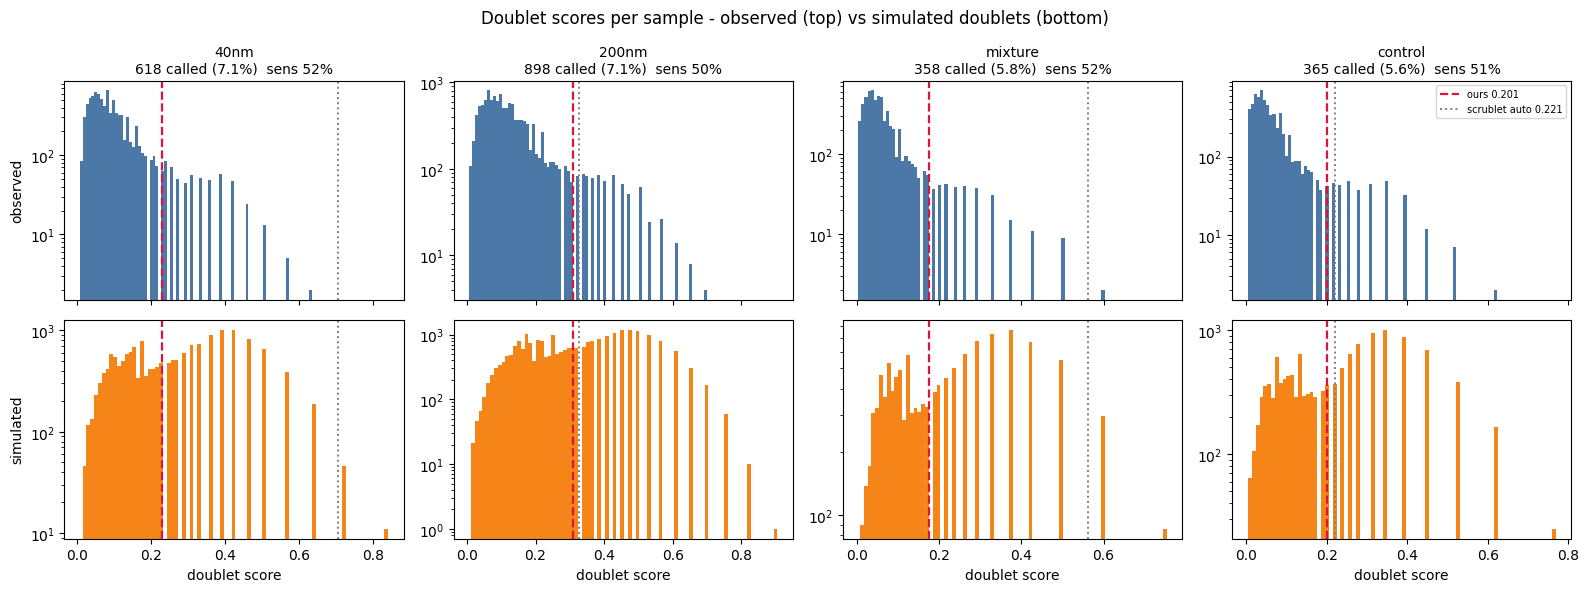

In [9]:
import matplotlib.pyplot as plt

# Top row: observed cells. Bottom row: simulated doublets - the known positives.
# Red dashed = our threshold (median simulated score, i.e. 50% sensitivity).
# Grey dotted = Scrublet's automatic threshold, shown so its failure is visible.
#
# Log y-scale throughout: without it the singlet peak flattens the tail we care about.
# Note the COMB of isolated spikes in the observed tail - doublet_score is a fraction of
# k nearest neighbours, so it takes discrete values. That comb is why a shoulder-based
# threshold ends up depending on cell count.
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex='col')

for j, (label, adata) in enumerate(adatas.items()):
    obs = adata.obs['doublet_score'].to_numpy()
    sim = np.asarray(adata.uns['scrublet']['doublet_scores_sim'])
    thr = THRESHOLDS[label]
    auto = adata.uns['scrublet'].get('threshold')
    sensitivity = float((sim >= thr).mean())
    n_called = int((obs >= thr).sum())

    for i, (scores, name, colour) in enumerate(
        [(obs, 'observed', '#4C78A8'), (sim, 'simulated', '#F58518')]
    ):
        ax = axes[i, j]
        ax.hist(scores, bins=80, color=colour, edgecolor='none')
        ax.axvline(thr, color='crimson', ls='--', lw=1.6, label=f'ours {thr:.3f}')
        if auto is not None:
            ax.axvline(auto, color='grey', ls=':', lw=1.4,
                       label=f'scrublet auto {auto:.3f}')
        ax.set_yscale('log')
        ax.set_ylabel(name if j == 0 else '')
        if i == 0:
            ax.set_title(
                f'{label}\n{n_called:,} called ({n_called / len(obs):.1%})  '
                f'sens {sensitivity:.0%}',
                fontsize=10,
            )
        else:
            ax.set_xlabel('doublet score')
        if i == 0 and j == 3:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle(
    'Doublet scores per sample - observed (top) vs simulated doublets (bottom)',
    fontsize=12,
)
fig.tight_layout()
plt.show()

### Applying the thresholds, and what the numbers say

Flag first, filter second — scores/calls stay in `obs` so the decision stays
inspectable. Sensitivity-corrected implied doublet burden comes out flat at ~11–14%
across all four samples, not the ~2x spread the 10x loading model predicts — most
likely because recovery (viability/clumping), not loading, differed between channels.
The absolute value is probably an overestimate (simulated doublets are cleaner
hybrids than real ones, inflating measured sensitivity), so treat ~11–14% as an upper
bound. Either way it shifts all four samples equally, so it doesn't bias the
cross-sample comparisons Tasks 4/6 depend on.

Since only heterotypic doublets are detected, roughly half the true burden survives
into clustering in every sample at matched sensitivity — checkable later in Section 12
via each sample's homotypic fraction (sum of squared cell-type proportions).


In [10]:
# Apply our sensitivity-matched thresholds, overwriting Scrublet's own unreliable call.
# (Not the shoulder rule - that was tried and rejected above, because the shoulder's
# position depends on cell count and so gave the largest sample the weakest detection.)
for label, adata in adatas.items():
    adata.obs['predicted_doublet'] = (
        adata.obs['doublet_score'] >= THRESHOLDS[label]
    )

# CLAUDE.md's named pitfall is a threshold that is present in code but numerically
# inert - it filters nothing, and the code running is mistaken for the filter working.
# That is exactly what Scrublet's automatic threshold did here (0 cells in 40nm), so
# print before/after counts and assert something was actually removed.
before = {label: adata.n_obs for label, adata in adatas.items()}

adatas = {
    label: adata[~adata.obs['predicted_doublet']].copy()
    for label, adata in adatas.items()
}

print(f'{"sample":<9}{"before":>9}{"removed":>9}{"after":>9}{"removed":>10}'
      f'{"10x est":>10}')
for label, adata in adatas.items():
    removed = before[label] - adata.n_obs
    print(
        f'{label:<9}{before[label]:>9,}{removed:>9,}{adata.n_obs:>9,}'
        f'{removed / before[label]:>10.1%}'
        f'{expected_doublet_rate(before[label]):>10.1%}'
    )
    assert removed > 0, (
        f'{label}: doublet filter removed nothing. The threshold is inert - '
        f'inspect the score distribution before continuing.'
    )
    # Sanity bound, not a target: detected rate should be within a factor of ~2 of the
    # loading estimate. Wider than that means the threshold, not the biology, is wrong.
    ratio = (removed / before[label]) / expected_doublet_rate(before[label])
    assert 0.4 < ratio < 2.0, (
        f'{label}: removed {removed / before[label]:.1%} against a 10x estimate of '
        f'{expected_doublet_rate(before[label]):.1%} (ratio {ratio:.2f}) - '
        f'inspect the threshold.'
    )

total_before, total_after = sum(before.values()), sum(a.n_obs for a in adatas.values())
print(
    f'\ntotal {total_before:,} -> {total_after:,} cells  '
    f'({total_before - total_after:,} doublets removed, '
    f'{(total_before - total_after) / total_before:.1%})'
)
print('\nSection 2 complete: doublets scored, thresholded per sample, and removed.')

sample      before  removed    after   removed   10x est
40nm         8,729      618    8,111      7.1%      7.0%
200nm       12,676      898   11,778      7.1%     10.1%
mixture      6,157      358    5,799      5.8%      4.9%
control      6,516      365    6,151      5.6%      5.2%

total 34,078 -> 31,839 cells  (2,239 doublets removed, 6.6%)

Section 2 complete: doublets scored, thresholded per sample, and removed.


---

## Section 3a — QC metrics and distribution inspection

**Task 1 — QC & preprocessing** · **tutorial reference:** cells 23–45

Filtered in 3b: count depth, genes detected, mito% — the three Task 1
criteria. Ribo% is computed but never filtered (why, below). Nothing is
filtered in 3a — it only measures and plots, so the counterfactual (what
would rule X remove) can still be checked before a choice is locked in.
After 3b drops cells, checking would mean re-running from Section 1 through
Scrublet.

**Why not the tutorial's hardcoded `mito < 20`, `ribo < 2`?** Traced through the
tutorial's own saved outputs, those two thresholds together removed 17 cells — 0.3% —
because its ribo% distribution already sat almost entirely under 2% for unrelated
reasons. That's the named pitfall found in the source we're adapting from: a
threshold present in code but numerically inert on the data it runs against.
Whole-cell PBMC data (ours) has much higher ribosomal content, so the same line is
inert there and would be catastrophic here.

**Why ribo% is computed but not filtered:** Task 1 doesn't call for it; high
ribo% tracks translational activity, so filtering on it would preferentially
delete *responding* lymphocytes in an activation study; and low-complexity
cells are already caught directly by `n_genes_by_counts`. It's kept as a
diagnostic only — a shifted ribo% in one sample would flag a processing
difference between channels, before Task 4 reads a composition difference as
an exposure effect.


In [11]:
# Flag the two gene families the QC percentages are computed over. Both flags go in
# .var, PER SAMPLE, because the four files still have different gene sets (22,613 /
# 23,206 / 21,715 / 21,961) and are not concatenated until Section 4.

# Mitochondrial: the 13 protein-coding genes on the mitochondrial chromosome, prefixed
# 'MT-' in current human nomenclature. Verified present and identically named in all
# four files - no legacy aliases (COX1, CYTB, ND1) anywhere.
#
# Ribosomal: KEGG_RIBOSOME from MSigDB, per PLAN.md row 3. Fetched ONCE here rather
# than inside the loop - it is the same list every time, and this notebook should not
# make four identical network calls.
#
# Why the curated list and not an 'RPS'/'RPL' prefix match, measured on this data:
# KEGG matches 85 of its 88 genes. The 3 misses - RPL10L, RPL3L, RSL24D1P11 - are
# tissue-specific paralogs and a pseudogene, genuinely absent from PBMCs rather than
# renamed. A prefix match instead picks up 102 genes but wrongly INCLUDES RPS6KA1 and
# RPS6KA2 (MAPK signalling kinases, named after the ribosomal protein they
# phosphorylate rather than being one), an antisense lncRNA and several pseudogenes,
# while wrongly EXCLUDING FAU and UBA52 - which encode ribosomal proteins S30 and L40
# under non-RP names. A prefix rule can only see spelling; the curated set encodes
# the biology, and here that is ~20x fewer errors.
RIBO_URL = (
    'http://software.broadinstitute.org/gsea/msigdb/download_geneset.jsp'
    '?geneSetName=KEGG_RIBOSOME&fileType=txt'
)

# skiprows=2 drops the set name and description lines; gene symbols follow. The Broad
# URL 301-redirects to gsea-msigdb.org, which pd.read_table follows by default.
ribo_genes = set(pd.read_table(RIBO_URL, skiprows=2, header=None)[0].values)
print(f'KEGG_RIBOSOME: {len(ribo_genes)} gene symbols fetched\n')

print(f'{"sample":<9}{"genes":>8}{"MT-":>6}{"ribo":>7}{"of KEGG":>10}')
for label, adata in adatas.items():
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    adata.var['ribo'] = adata.var_names.isin(ribo_genes)

    n_mt, n_ribo = int(adata.var['mt'].sum()), int(adata.var['ribo'].sum())
    print(f'{label:<9}{adata.n_vars:>8,}{n_mt:>6}{n_ribo:>7}'
          f'{n_ribo / len(ribo_genes):>10.0%}')

    # A silent match failure - wrong nomenclature, a changed separator, a download that
    # returned an error page - would leave these flags all-False and both percentages a
    # uniform 0.0. That looks like unusually clean data rather than a broken step, so
    # assert rather than trust. This is the same class of bug as Section 2's inert
    # threshold: code that runs successfully while doing nothing.
    assert n_mt == 13, f'{label}: expected 13 MT- genes, found {n_mt}'
    assert 80 <= n_ribo <= 90, (
        f'{label}: only {n_ribo} of {len(ribo_genes)} KEGG ribo genes matched - '
        f'check gene nomenclature before trusting pct_counts_ribo'
    )

print('\nGene family flags set on all four samples.')

KEGG_RIBOSOME: 88 gene symbols fetched

sample      genes   MT-   ribo   of KEGG
40nm       22,613    13     85       97%
200nm      23,206    13     87       99%
mixture    21,715    13     86       98%
control    21,961    13     86       98%

Gene family flags set on all four samples.


In [12]:
# Compute the per-cell QC metrics.
#
# calculate_qc_metrics must see RAW COUNTS. Every metric here is a count or a ratio of
# counts, so running it on normalized values would produce numbers that still look
# plausible but mean nothing - CLAUDE.md's "mismatched layers" pitfall exactly. Our .X
# is counts (asserted at the end of Section 1); we re-assert below rather than assume.
#
# log1p=True, where the tutorial uses False at its cell 31. We need it: the MAD-based
# candidate rule operates on log1p_total_counts and log1p_n_genes_by_counts. Count
# depth is roughly log-normal, so a SYMMETRIC outlier rule is only meaningful on the
# log scale - applied to raw counts it would flag far more cells above the median than
# below, purely from the right skew rather than from anything being wrong with them.
#
# percent_top=None skips the "fraction of counts in the top N genes" columns, which
# nothing downstream uses.
for label, adata in adatas.items():
    sc.pp.calculate_qc_metrics(
        adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=True, inplace=True
    )

# The four metrics Section 3 reasons about. The first three are CLAUDE.md's Task 1
# criteria and get filtered in 3b; pct_counts_ribo is diagnostic only.
QC_METRICS = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo']

for label, adata in adatas.items():
    data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
    assert np.all(data == np.floor(data)), (
        f'{label}: .X is no longer integer counts - QC metrics would be meaningless'
    )
    for metric in QC_METRICS:
        assert metric in adata.obs.columns, f'{label}: {metric} was not computed'
        # A constant metric means the .var flag never matched anything. Variance is the
        # cheapest test that the percentages carry real information.
        assert adata.obs[metric].var() > 0, (
            f'{label}: {metric} is constant - the gene flag did not land'
        )
    for pct in ('pct_counts_mt', 'pct_counts_ribo'):
        assert adata.obs[pct].between(0, 100).all(), f'{label}: {pct} outside [0, 100]'

print('QC metrics computed for all four samples.')
print('.X verified still raw integer counts.\n')
print('obs columns now:')
for col in adatas['40nm'].obs.columns:
    print(f'    {col}')

QC metrics computed for all four samples.
.X verified still raw integer counts.

obs columns now:
    predicted.celltype
    predicted.celltype.score
    Sample
    doublet_score
    predicted_doublet
    n_genes_by_counts
    log1p_n_genes_by_counts
    total_counts
    log1p_total_counts
    total_counts_mt
    log1p_total_counts_mt
    pct_counts_mt
    total_counts_ribo
    log1p_total_counts_ribo
    pct_counts_ribo


In [13]:
# Per-sample distribution summary, before any plot.
#
# CLAUDE.md requires thresholds picked from each sample's OWN distribution, so the
# first thing to establish is whether the four distributions actually differ. If they
# were near-identical, a single shared threshold would have been defensible after all;
# if they differ, that is precisely what rules it out. Either way it should be settled
# by looking, not assumed - so print the quantiles side by side and read them.
rows = []
for label, adata in adatas.items():
    for metric in QC_METRICS:
        v = adata.obs[metric]
        rows.append({
            'metric': metric,
            'sample': label,
            'cells': len(v),
            'min': v.min(),
            'p1': v.quantile(0.01),
            'p25': v.quantile(0.25),
            'median': v.median(),
            'p75': v.quantile(0.75),
            'p99': v.quantile(0.99),
            'max': v.max(),
        })

qc_summary = pd.DataFrame(rows).set_index(['metric', 'sample'])

with pd.option_context('display.float_format', '{:,.2f}'.format, 'display.width', 160):
    for metric in QC_METRICS:
        print(f'\n=== {metric} ===')
        print(qc_summary.loc[metric])

# The single number that decides whether per-sample thresholds are necessary: how much
# the medians move across samples, relative to the metric's own scale.
print('\n\n=== cross-sample spread of the median ===')
print(f'{"metric":<22}{"min median":>13}{"max median":>13}{"ratio":>9}')
for metric in QC_METRICS:
    meds = qc_summary.loc[metric, 'median']
    lo, hi = meds.min(), meds.max()
    ratio = hi / lo if lo > 0 else float('inf')
    print(f'{metric:<22}{lo:>13,.2f}{hi:>13,.2f}{ratio:>9.2f}x')


=== total_counts ===
         cells    min       p1      p25   median      p75       p99        max
sample                                                                        
40nm      8111 500.00   739.60 3,862.00 5,269.00 6,867.50 24,591.60 151,008.00
200nm    11778 504.00   970.00 3,248.00 4,334.00 5,818.00 25,650.16 103,502.00
mixture   5799 502.00   760.96 4,352.00 6,090.00 8,086.00 46,197.06 215,311.00
control   6151 514.00 1,076.00 5,441.50 7,674.00 9,678.50 55,434.00 202,274.00

=== n_genes_by_counts ===
         cells    min     p1      p25   median      p75      p99       max
sample                                                                    
40nm      8111 216.00 502.00 1,635.00 1,995.00 2,390.00 5,230.60 10,419.00
200nm    11778 204.00 614.77 1,466.00 1,768.00 2,167.00 5,505.23  9,687.00
mixture   5799 211.00 477.00 1,927.50 2,318.00 2,701.00 7,055.64 10,984.00
control   6151 203.00 521.50 2,260.50 2,601.00 3,023.00 7,528.00 10,910.00

=== pct_counts_mt ===
    

In [14]:
# Candidate rule: MAD-based outlier detection.
#
# NOTHING is applied in 3a. These helpers exist so we can MEASURE what each candidate
# rule would remove, and make the choice at review against real numbers.
#
# MAD = median absolute deviation. What matters is that BOTH the centre (median) and
# the spread (MAD) are robust: a handful of extreme cells shifts a mean and inflates a
# standard deviation, so an SD-based rule is partly calibrated by the very outliers it
# is trying to find - and quietly becomes more permissive the worse the contamination
# is. The median and MAD barely move, so the rule keeps its meaning.
#
# Against a percentile rule, the advantage is that MAD adapts to quality rather than to
# shape: it removes nothing from a clean sample, whereas a 1st/99th-percentile cut
# removes exactly 2% by construction whether or not anything is wrong with those cells.
# That is the same objection Section 2 raised against the shoulder rule.

def mad(values):
    """Median absolute deviation: a spread estimate that outliers cannot inflate."""
    values = np.asarray(values, dtype=float)
    return float(np.median(np.abs(values - np.median(values))))


def mad_bounds(values, nmads, side):
    """(lower, upper) cutoffs `nmads` MADs from the median. None means no bound."""
    values = np.asarray(values, dtype=float)
    centre, scale = float(np.median(values)), mad(values)
    lower = centre - nmads * scale if side in ('both', 'lower') else None
    upper = centre + nmads * scale if side in ('both', 'upper') else None
    return lower, upper


# Maps each plotted metric to the obs column its rule is evaluated on. Depth and genes
# detected use the log scale (see the log1p note above); mito% is already a bounded
# percentage and needs no transform. Ribo% has no rule at all - diagnostic only.
RULE_METRIC = {
    'total_counts':      'log1p_total_counts',
    'n_genes_by_counts': 'log1p_n_genes_by_counts',
    'pct_counts_mt':     'pct_counts_mt',
    'pct_counts_ribo':   None,
}

# Sidedness per metric. This is a real judgement call, not bookkeeping: a bound on a
# tail where nothing is actually wrong discards good cells for no reason.
#
# REVISED. Both depth rules were first set to 'both'. Measured against cell type once
# annotation existed, the UPPER bound removed 14% of monocytes and 0.0% of cytotoxic
# T cells - it was tracking cell SIZE, not doublets, since a monocyte carries ~3x the
# RNA of a small T cell (median 11,476 counts against 3,663). It also acted unevenly
# across samples - 42.6% of control monocytes against 12.3% of 200nm ones - which
# biases the cross-sample composition comparison Task 4 exists to make. Section 2's
# Scrublet pass already removed 2,239 doublets, so the upper tail was duplicating that
# work and doing it by cell type instead of by doublet evidence.
METRIC_RULES = {
    'log1p_total_counts':      (5, 'lower'),   # ambient droplets, not cells
    'log1p_n_genes_by_counts': (5, 'lower'),   # same population, complexity axis
    'pct_counts_mt':           (3, 'upper'),   # only the high tail is ever bad
}

# Percentile rule, for comparison. Fixed fraction by construction - stated here so the
# next cell can measure both against the same distributions.
PERCENTILE_BOUNDS = (0.01, 0.99)

_filled = all(n is not None for n, _ in METRIC_RULES.values())
print('METRIC_RULES filled:', _filled)
if not _filled:
    print('  -> plots below will render without MAD bands until it is filled in.')

METRIC_RULES filled: True


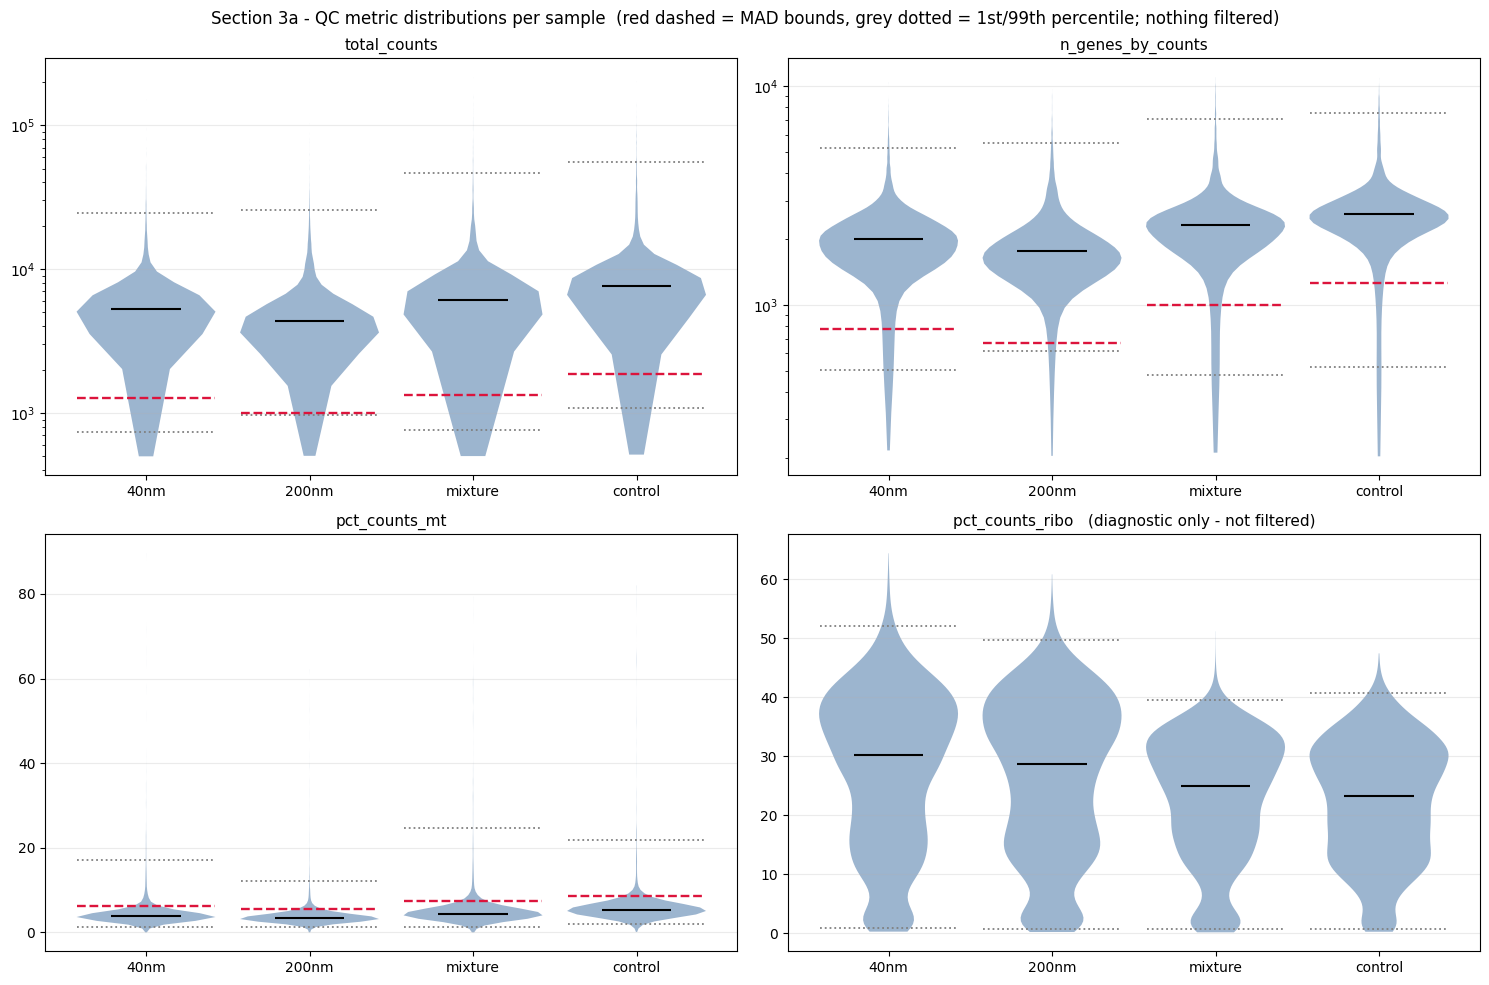

In [15]:
# Distribution plots - one panel per metric, four violins per panel (one per sample),
# so cross-sample differences are read directly rather than inferred across figures.
#
# Reference lines only. Red dashed = MAD bounds (once METRIC_RULES is filled), grey
# dotted = 1st/99th percentile. Nothing is filtered by this cell.
#
# Depth and genes-detected use a log y-axis: both span orders of magnitude, and on a
# linear axis the bulk of cells collapses into a line at the bottom while a few
# high-depth cells stretch the whole panel.
LABELS = list(adatas)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, metric in zip(axes.ravel(), QC_METRICS):
    series = [adatas[l].obs[metric].to_numpy() for l in LABELS]
    parts = ax.violinplot(series, positions=range(len(LABELS)),
                          showmedians=True, showextrema=False, widths=0.85)
    for body in parts['bodies']:
        body.set_facecolor('#4C78A8')
        body.set_alpha(0.55)
    parts['cmedians'].set_color('black')

    rule_col = RULE_METRIC[metric]
    for i, label in enumerate(LABELS):
        obs = adatas[label].obs

        # Percentile reference, drawn on the metric's own scale.
        for q in PERCENTILE_BOUNDS:
            ax.hlines(obs[metric].quantile(q), i - 0.42, i + 0.42,
                      color='grey', ls=':', lw=1.3, zorder=3)

        # MAD reference. Rules for depth and genes are evaluated on log1p values, so
        # the bound has to be mapped back with expm1 before it can be drawn on the raw
        # axis - otherwise the line lands in completely the wrong place.
        if rule_col is None:
            continue
        nmads, side = METRIC_RULES[rule_col]
        if nmads is None:
            continue
        lower, upper = mad_bounds(obs[rule_col], nmads, side)
        for bound in (lower, upper):
            if bound is None:
                continue
            drawn = np.expm1(bound) if rule_col.startswith('log1p_') else bound
            ax.hlines(drawn, i - 0.42, i + 0.42,
                      color='crimson', ls='--', lw=1.7, zorder=4)

    if metric in ('total_counts', 'n_genes_by_counts'):
        ax.set_yscale('log')
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS)
    ax.set_title(metric + ('   (diagnostic only - not filtered)'
                           if metric == 'pct_counts_ribo' else ''), fontsize=11)
    ax.grid(axis='y', alpha=0.25)

fig.suptitle('Section 3a - QC metric distributions per sample  '
             '(red dashed = MAD bounds, grey dotted = 1st/99th percentile; '
             'nothing filtered)', fontsize=12)
fig.tight_layout()
plt.show()

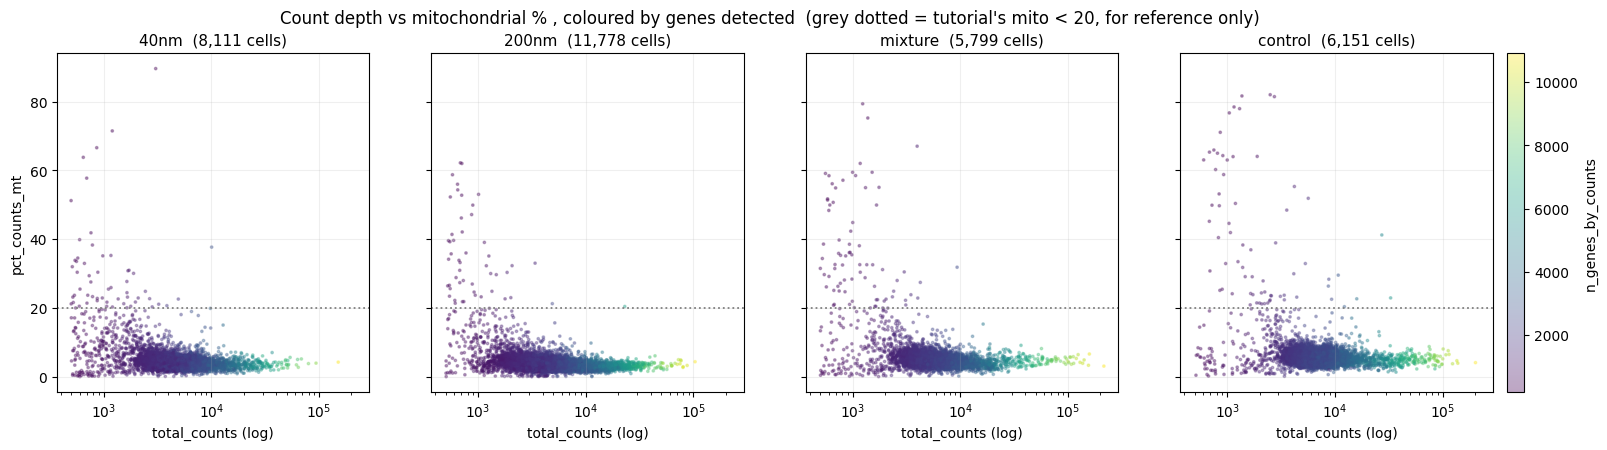

In [16]:
# Joint view: count depth vs mito%, coloured by genes detected.
#
# The violins above show each metric in isolation, but a threshold on one metric cuts
# across the others, and this is where that becomes visible. The shape to look for is
# a cluster at LOW depth and HIGH mito% - dying cells that lost cytoplasmic mRNA
# through a ruptured membrane while mitochondrial transcripts stayed trapped inside.
# Those cells are the ones a mito filter is actually for.
#
# The colour axis is what makes it readable: genuinely dying cells are low-depth,
# high-mito AND low-complexity (few genes), so they should appear as a dark clump. A
# high-mito cell that still detects many genes is a different animal - an intact cell
# with real mitochondrial content, which for this project might be exposure response
# rather than damage.
#
# This is a plot for choosing thresholds, NOT the joint mito%/complexity distress
# analysis CLAUDE.md defers to bonus #1. That analysis tests high-mito cells against a
# dissociation-stress gene signature to decide whether they are artefact or biology,
# and it needs the cell-type labels from Task 3 first.
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4), sharex=True, sharey=True)

for ax, label in zip(axes, LABELS):
    obs = adatas[label].obs
    sm = ax.scatter(obs['total_counts'], obs['pct_counts_mt'],
                    c=obs['n_genes_by_counts'], s=3, alpha=0.35,
                    cmap='viridis', rasterized=True)
    ax.set_xscale('log')
    ax.set_xlabel('total_counts (log)')
    ax.set_title(f'{label}  ({len(obs):,} cells)', fontsize=11)
    ax.grid(alpha=0.2)

    # Reference only: the tutorial's hardcoded mito cutoff, shown so its position
    # relative to OUR distributions is visible rather than assumed.
    ax.axhline(20, color='grey', ls=':', lw=1.3)

axes[0].set_ylabel('pct_counts_mt')
fig.colorbar(sm, ax=axes, label='n_genes_by_counts', fraction=0.015, pad=0.01)
fig.suptitle("Count depth vs mitochondrial % , coloured by genes detected  "
             "(grey dotted = tutorial's mito < 20, for reference only)", fontsize=12)
plt.show()

In [17]:
# What each candidate rule WOULD remove. Still nothing is applied.
#
# This is the whole point of splitting 3a from 3b: measuring the counterfactual while
# the cells are still in the object. After 3b drops them, asking "how many would the
# other rule have taken?" means re-running from Section 1, and Scrublet makes that the
# expensive direction.
#
# The union row matters more than the per-metric rows. Cells flagged by several metrics
# overlap heavily - a dying cell is low-depth AND low-complexity AND high-mito - so
# summing the individual counts badly overstates the real loss.

def flag_mask(values, lower, upper):
    """Boolean mask of cells outside (lower, upper). None means that side is open."""
    values = np.asarray(values, dtype=float)
    mask = np.zeros(len(values), dtype=bool)
    if lower is not None:
        mask |= values < lower
    if upper is not None:
        mask |= values > upper
    return mask


if not all(n is not None for n, _ in METRIC_RULES.values()):
    print('METRIC_RULES is not filled in yet - fill it in the cell above, then re-run '
          'this cell to see what each rule would remove.')
else:
    for label in LABELS:
        obs = adatas[label].obs
        n = len(obs)
        print(f'\n=== {label}  ({n:,} cells) ===')
        print(f'{"metric":<26}{"rule":<14}{"lower":>12}{"upper":>12}'
              f'{"flagged":>10}{"%":>8}')

        union_mad = np.zeros(n, dtype=bool)
        union_pct = np.zeros(n, dtype=bool)

        for metric, rule_col in RULE_METRIC.items():
            if rule_col is None:      # pct_counts_ribo - diagnostic only, no rule
                continue
            nmads, side = METRIC_RULES[rule_col]

            lo, hi = mad_bounds(obs[rule_col], nmads, side)
            m = flag_mask(obs[rule_col], lo, hi)
            union_mad |= m
            # Report bounds on the metric's own scale so they are comparable to the
            # summary table above, not as log values nobody can eyeball.
            shown = [None if b is None else
                     (np.expm1(b) if rule_col.startswith('log1p_') else b)
                     for b in (lo, hi)]
            print(f'{metric:<26}{f"MAD {nmads} {side}":<14}'
                  f'{"-" if shown[0] is None else f"{shown[0]:,.1f}":>12}'
                  f'{"-" if shown[1] is None else f"{shown[1]:,.1f}":>12}'
                  f'{m.sum():>10,}{m.sum() / n:>8.1%}')

            plo, phi = (obs[metric].quantile(q) for q in PERCENTILE_BOUNDS)
            mp = flag_mask(obs[metric], plo, phi)
            union_pct |= mp
            print(f'{"":<26}{"pct 1/99":<14}{plo:>12,.1f}{phi:>12,.1f}'
                  f'{mp.sum():>10,}{mp.sum() / n:>8.1%}')

        print(f'{"UNION across metrics":<26}{"MAD":<14}{"":>24}'
              f'{union_mad.sum():>10,}{union_mad.sum() / n:>8.1%}')
        print(f'{"":<26}{"pct 1/99":<14}{"":>24}'
              f'{union_pct.sum():>10,}{union_pct.sum() / n:>8.1%}')

# Separately: what the tutorial's two hardcoded cutoffs would do to OUR data. Its own
# outputs show they removed 17 cells (0.3%) there. The prediction here is that mito<20
# is roughly comparable while ribo<2 is catastrophic - but the whole point of Section 2
# and 3a is to check predictions against numbers rather than trust them.
print('\n\n=== the tutorial\'s hardcoded cutoffs, applied to our data (NOT used) ===')
print(f'{"sample":<10}{"mito >= 20":>14}{"":>7}{"ribo >= 2":>13}{"":>8}')
for label in LABELS:
    obs = adatas[label].obs
    n = len(obs)
    n_mt = int((obs['pct_counts_mt'] >= 20).sum())
    n_rb = int((obs['pct_counts_ribo'] >= 2).sum())
    print(f'{label:<10}{n_mt:>10,}{n_mt / n:>11.1%}{n_rb:>13,}{n_rb / n:>11.1%}')


=== 40nm  (8,111 cells) ===
metric                    rule                 lower       upper   flagged       %
total_counts              MAD 5 lower        1,263.1           -       215    2.7%
                          pct 1/99             739.6    24,591.6       164    2.0%
n_genes_by_counts         MAD 5 lower          774.2           -       210    2.6%
                          pct 1/99             502.0     5,230.6       163    2.0%
pct_counts_mt             MAD 3 upper              -         6.3       647    8.0%
                          pct 1/99               1.2        17.1       164    2.0%
UNION across metrics      MAD                                          736    9.1%
                          pct 1/99                                     300    3.7%

=== 200nm  (11,778 cells) ===
metric                    rule                 lower       upper   flagged       %
total_counts              MAD 5 lower        1,006.9           -       129    1.1%
                          p

In [18]:
# Not "how much are we cutting" but "WHAT are we cutting".
#
# Cell 24 gives counts. A count cannot distinguish "removed 4% debris" from "removed 4%
# of a small, low-RNA but perfectly real cell type" - and the second would delete a
# whole population from Task 4's composition comparison, which is exactly the artefact
# Section 2 worked to avoid. Platelets and small resting lymphocytes genuinely have low
# RNA, so a low-depth cell is not automatically junk.
#
# Two things below:
#   1. Split each flag into its LOW and HIGH tail. They remove different things - dying
#      cells at the bottom, probable multiplets at the top - and a single total hides
#      which of the two is doing the work.
#   2. Profile the flagged cells against the kept ones. A dying cell should show HIGH
#      mito%, LOW ribo% (cytoplasmic transcripts leaked out through the ruptured
#      membrane) and FEW genes. If the low tail instead looks compositionally normal,
#      we are cutting real biology and should loosen the bound.

for label in LABELS:
    obs = adatas[label].obs
    n = len(obs)
    low_any = np.zeros(n, dtype=bool)
    high_any = np.zeros(n, dtype=bool)

    print(f'\n=== {label}  ({n:,} cells) ===')
    print(f'{"metric":<24}{"cut low":>10}{"%":>8}{"cut high":>10}{"%":>8}')
    for metric, rule_col in RULE_METRIC.items():
        if rule_col is None:            # ribo - diagnostic only, never filtered
            continue
        nmads, side = METRIC_RULES[rule_col]
        lo, hi = mad_bounds(obs[rule_col], nmads, side)
        v = obs[rule_col].to_numpy()
        ml = (v < lo) if lo is not None else np.zeros(n, dtype=bool)
        mh = (v > hi) if hi is not None else np.zeros(n, dtype=bool)
        low_any |= ml
        high_any |= mh
        print(f'{metric:<24}{ml.sum():>10,}{ml.sum() / n:>8.1%}'
              f'{mh.sum():>10,}{mh.sum() / n:>8.1%}')

    keep = ~(low_any | high_any)
    print(f'{"UNION":<24}{low_any.sum():>10,}{low_any.sum() / n:>8.1%}'
          f'{high_any.sum():>10,}{high_any.sum() / n:>8.1%}')

    print(f'\n  {"group":<17}{"cells":>8}{"med counts":>13}{"med genes":>12}'
          f'{"med mito%":>12}{"med ribo%":>12}')
    for name, mask in (('cut - low tail', low_any & ~high_any),
                       ('cut - high tail', high_any),
                       ('KEPT', keep)):
        if int(mask.sum()) == 0:
            continue
        g = obs[mask]
        print(f'  {name:<17}{int(mask.sum()):>8,}'
              f'{g["total_counts"].median():>13,.0f}'
              f'{g["n_genes_by_counts"].median():>12,.0f}'
              f'{g["pct_counts_mt"].median():>12.1f}'
              f'{g["pct_counts_ribo"].median():>12.1f}')



=== 40nm  (8,111 cells) ===
metric                     cut low       %  cut high       %
total_counts                   215    2.7%         0    0.0%
n_genes_by_counts              210    2.6%         0    0.0%
pct_counts_mt                    0    0.0%       647    8.0%
UNION                          226    2.8%       647    8.0%

  group               cells   med counts   med genes   med mito%   med ribo%
  cut - low tail         89          842         606         2.3         9.7
  cut - high tail       647        2,627       1,372         8.2         6.1
  KEPT                7,375        5,477       2,043         3.7        31.6

=== 200nm  (11,778 cells) ===
metric                     cut low       %  cut high       %
total_counts                   129    1.1%         0    0.0%
n_genes_by_counts              145    1.2%         0    0.0%
pct_counts_mt                    0    0.0%       853    7.2%
UNION                          153    1.3%       853    7.2%

  group             

In [19]:
# Section 3a verification: assert that nothing was filtered.
#
# Every other section asserts that a step DID something. This one asserts the opposite,
# and it is the same discipline: 3a's contract is that it only measures, so an
# accidental filter here would silently change what 3b is choosing between.
EXPECTED_AFTER_DOUBLETS = {'40nm': 8111, '200nm': 11778, 'mixture': 5799, 'control': 6151}

print(f'{"sample":<10}{"cells":>9}{"expected":>10}{"MT-":>6}{"ribo":>6}')
for label, adata in adatas.items():
    print(f'{label:<10}{adata.n_obs:>9,}{EXPECTED_AFTER_DOUBLETS[label]:>10,}'
          f'{int(adata.var["mt"].sum()):>6}{int(adata.var["ribo"].sum()):>6}')
    assert adata.n_obs == EXPECTED_AFTER_DOUBLETS[label], (
        f'{label}: 3a changed the cell count ({adata.n_obs:,} vs '
        f'{EXPECTED_AFTER_DOUBLETS[label]:,}) - it must only measure, never filter'
    )

total = sum(a.n_obs for a in adatas.values())
assert total == 31_839, f'expected 31,839 cells after Section 2, got {total:,}'

print(f'\ntotal {total:,} cells - unchanged from Section 2.')
print('Section 3a complete: metrics computed, distributions plotted, nothing filtered.')
print('Thresholds are chosen at review, then applied in Section 3b.')

sample        cells  expected   MT-  ribo
40nm          8,111     8,111    13    85
200nm        11,778    11,778    13    87
mixture       5,799     5,799    13    86
control       6,151     6,151    13    86

total 31,839 cells - unchanged from Section 2.
Section 3a complete: metrics computed, distributions plotted, nothing filtered.
Thresholds are chosen at review, then applied in Section 3b.


### Section 3a review — what to read off the output above

**Stop here** — 3b's thresholds are chosen from these answers, from real numbers,
not assumed.

1. Do the four distributions actually differ? (cross-sample median spread table)
2. Is there a low-depth / high-mito clump in the joint scatter — the population a
   mito filter exists to remove?
3. Do high-mito cells also show low gene count (dying) or normal gene count
   (possibly real exposure stress — input to bonus #1 later)?
4. Where does the tutorial's `mito < 20` line sit relative to our distributions?
5. What does `ribo >= 2` actually remove here, against the tutorial's 0.3%?
6. Does any one sample's ribo% look shifted from the other three (processing
   artefact check)?
7. MAD vs. percentile — which removes more, and are they removing the same cells?

3b applies whichever rule these answers justify, with before/after counts and an
inertness check.


---

## Section 3b — Applying the QC thresholds

**Task 1** · thresholds chosen at the 3a review, from the distributions

### The rule

**MAD-based outlier detection, per sample.** A cell is removed if a metric lies more
than *n* MADs from **that sample's own median** — per-sample because depth alone
varies up to 1.77x between samples; a shared threshold would cut unevenly and
manufacture a composition difference Task 4 would misread as exposure.

| metric | setting | why |
|---|---|---|
| `log1p_total_counts` | 5 MADs, lower only | Low tail is ambient RNA (genes-per-count 0.6-0.7 vs ~0.35 in real cells) — not cells. No upper bound (see revision below). |
| `log1p_n_genes_by_counts` | 5 MADs, lower only | Same ambient population, complexity axis. |
| `pct_counts_mt` | 3 MADs, upper only | Low mito% is healthy. The cut cells carry ~11% ribo vs ~32% kept — the leaked-cytoplasm signature of a compromised cell, not the shoulder of the healthy population. |

`pct_counts_ribo` stays unfiltered (Section 3a) — it's what confirmed the mito cut
targets genuinely compromised cells rather than the healthy edge.

### Revision — why the upper depth bound was dropped

Depth was originally bounded on **both** ends, the high side meant to catch
multiplets Scrublet missed. Checked against cell type once Task 3 existed, it didn't
hold — it tracked cell *size*, not doublet evidence:

| cell type | median counts | flagged "too high" |
|---|---|---|
| Cytotoxic T | 3,663 | 0.0% |
| CD4 T | 5,875 | 1.0% |
| B | 6,924 | 5.6% |
| **Monocyte** | **11,476** | **14.0%** |

Worse, it bit unevenly across samples (42.6% of control monocytes vs 12.3% of
200nm's) — exactly the composition confound Task 4 exists to measure, not
manufacture. The per-sample removal-rate guard (7.7-9.4%, looked fine) didn't catch
this because the bias was confined to ~6% of cells and averaged away at that
resolution — it now reports removal rate per cell type too, not just per sample.
Dropping the upper bound recovers 309 monocytes, 150 B cells, 247 CD4 T cells.
Doublet removal is left entirely to Section 2, which has actual per-cell evidence
rather than a size proxy.

### Limitations carried forward

- Mito filtering removes slightly more from exposed samples (7.2-8.2%) than control
  (6.5%) — consistent in direction across all three. Bonus #1 (deferred) asks whether
  this is technical damage or real exposure-induced mitochondrial stress.
- The low end was already filtered upstream before these files reached us (visible
  as a flat truncation at ~500 counts/~200 genes in Section 3a's violins) — our
  lower bound is a second pass on already-cleaned data, hence how little it removes.


In [20]:
# Section 3b - apply the QC thresholds.
#
# Flag first, filter second, exactly as Section 2 did: every per-metric flag stays in
# .obs, so the decision remains inspectable afterwards rather than buried inside a
# filtering expression. No threshold is hardcoded here - all bounds are recomputed per
# sample from METRIC_RULES, so changing the rule above and re-running is the only edit
# ever needed.

qc_before = {label: adata.n_obs for label, adata in adatas.items()}
qc_bounds = {}

for label, adata in adatas.items():
    n = adata.n_obs
    flagged = np.zeros(n, dtype=bool)
    qc_bounds[label] = {}

    for rule_col, (nmads, side) in METRIC_RULES.items():
        lo, hi = mad_bounds(adata.obs[rule_col], nmads, side)
        m = flag_mask(adata.obs[rule_col], lo, hi)
        adata.obs[f'qc_out_{rule_col}'] = m
        flagged |= m
        qc_bounds[label][rule_col] = (lo, hi)

    adata.obs['qc_outlier'] = flagged

# Per-metric contributions BEFORE removing anything. These overlap heavily - a dying
# cell is low-depth AND low-complexity AND high-mito - so they do not sum to the union.
print('cells flagged per metric (overlapping), then their union:\n')
print(f'{"sample":<10}'
      + ''.join(f'{c.replace("log1p_", ""):>26}' for c in METRIC_RULES)
      + f'{"UNION":>17}')
for label, adata in adatas.items():
    row = f'{label:<10}'
    for rule_col in METRIC_RULES:
        m = adata.obs[f'qc_out_{rule_col}']
        row += f'{m.sum():>17,}{m.mean():>9.1%}'
    u = adata.obs['qc_outlier']
    row += f'{u.sum():>10,}{u.mean():>7.1%}'
    print(row)

# Filter.
adatas = {
    label: adata[~adata.obs['qc_outlier']].copy()
    for label, adata in adatas.items()
}

print(f'\n{"sample":<10}{"before":>9}{"removed":>9}{"after":>9}{"removed":>11}')
for label, adata in adatas.items():
    removed = qc_before[label] - adata.n_obs
    print(f'{label:<10}{qc_before[label]:>9,}{removed:>9,}{adata.n_obs:>9,}'
          f'{removed / qc_before[label]:>11.1%}')
    # CLAUDE.md's named pitfall: a threshold present in code but numerically inert.
    # Section 2's first attempt filtered zero cells while completing successfully.
    assert removed > 0, (
        f'{label}: QC filter removed nothing - the bounds are inert. Inspect the '
        f'distributions before continuing.'
    )

rates = [(qc_before[l] - a.n_obs) / qc_before[l] for l, a in adatas.items()]
print(f'\nremoval rate across samples: {min(rates):.1%} - {max(rates):.1%}  '
      f'(spread {100 * (max(rates) - min(rates)):.1f} pp)')

# Task 4 compares cell-type proportions across these same four samples. If QC removed
# wildly different fractions per sample, the filtering itself would shift the
# composition it is meant to leave intact - the identical argument Section 2 made for
# matching doublet detection sensitivity across samples.
assert max(rates) - min(rates) < 0.05, (
    f'QC removal differs by {100 * (max(rates) - min(rates)):.1f} pp across samples - '
    f'inspect before trusting any Task 4 composition comparison'
)

total_before = sum(qc_before.values())
total_after = sum(a.n_obs for a in adatas.values())
print(f'\ntotal {total_before:,} -> {total_after:,} cells  '
      f'({total_before - total_after:,} removed, '
      f'{(total_before - total_after) / total_before:.1%})')

# Layer integrity, CLAUDE.md's other named pitfall: subsetting must not have disturbed
# the counts. Everything downstream - HVG selection in Section 6, pseudobulk DE in
# Section 13 - depends on .X still being raw integers.
for label, adata in adatas.items():
    data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
    assert np.all(data == np.floor(data)), f'{label}: .X is no longer integer counts'
    assert adata.layers['counts'].shape == adata.X.shape, f'{label}: counts layer desynced'

print('\n.X verified still raw integer counts; counts layer intact.')
print('Section 3 complete - QC metrics computed, thresholds applied, cells filtered.')


cells flagged per metric (overlapping), then their union:

sample                  total_counts         n_genes_by_counts             pct_counts_mt            UNION
40nm                    215     2.7%              210     2.6%              647     8.0%       736   9.1%
200nm                   129     1.1%              145     1.2%              853     7.2%       902   7.7%
mixture                 130     2.2%              188     3.2%              473     8.2%       545   9.4%
control                 124     2.0%              182     3.0%              402     6.5%       499   8.1%

sample       before  removed    after    removed
40nm          8,111      736    7,375       9.1%
200nm        11,778      902   10,876       7.7%
mixture       5,799      545    5,254       9.4%
control       6,151      499    5,652       8.1%

removal rate across samples: 7.7% - 9.4%  (spread 1.7 pp)

total 31,839 -> 29,157 cells  (2,682 removed, 8.4%)

.X verified still raw integer counts; counts layer i

---

## Section 4 — Concatenate the four samples

**Tasks 1–2** · **tutorial reference:** cells 73–85

**Why merge now, not earlier:** clustering, composition (Task 4) and DE (Task 5) all
require one shared label space across samples — only possible after merging. Doublet
detection (Section 2) and QC thresholds (Section 3) required the opposite: samples had
to stay separate, since doublets only form within one droplet emulsion and per-sample
thresholds are required. Both are now done, so this is the first point merging is
possible.

**`join='outer'`, not `inner`.** The four files carry different gene sets
(22.6k–23.2k) because each was independently gene-filtered upstream at evidently
`min.cells=3` — so "absent from a sample" means "seen in ≤2 cells there," a near-zero
measurement, not missing data. Outer's zero-fill misstates at most those 2 cells per
sample (always toward zero); inner deletes the gene from all four samples, so it can
never be tested. This was originally `inner`, reversed after measuring: 2,419 genes
are absent from control but present in an exposed sample, 288 of those detected in
10+ cells — the top one being `PTGES` (66 cells), an NF-κB-driven inflammation gene
of exactly the kind Tasks 5–6 exist to find. The real gene-count decision is
`min_cells=10` below, applied once to the merged object — one explicit, stated
threshold rather than an inherited one.

**Gene filtering (`sc.pp.filter_genes`) lives here**, not in Section 3 or 5: it must
run on the merged object (a gene needs `min_cells` across all 29,157 cells, not
within each sample) and must finish *before* Section 5's `normalize_total`, which
divides each cell by a sum over present genes. `min_cells=10`, chosen because the
binding constraint is annotating rare cell types, not noise removal — pDCs are ~0.3%
of PBMCs (~85 cells here), and their markers (`LILRA4`, `CLEC4C`) sit in about that
many cells; `min_cells=100` would erase that population before Task 3 could ever
name it.

**Legacy gene symbols:** `CXCL8` looks absent from all four samples, but it isn't
lost — this data uses the pre-2017 HGNC symbol `IL8` instead. 1,400 of 21,862 genes
(6.4%) carry a retired symbol, harmless for QC but a real risk at Sections 14/16,
where MSigDB ships current symbols and a stale name silently fails to match with no
warning. (An earlier spot-check here sampled only genes *known* to have been renamed
and reported "14/14 legacy" — a reminder that a check built from cases pre-selected
for having a property can't come out any other way.)

**Carried to Section 8:** Section 3a found a depth gradient that lines up with
exposure — control deepest, then mixture, 40nm, 200nm (1.77x spread). Depth
confounded with condition is exactly the case where over-aggressive batch correction
erases the biological signal, so Section 8's method choice has to account for it.


In [21]:
# Concatenate the four QC'd samples into one object.
#
# join='outer' keeps the UNION of genes, filling absent ones with zeros. This was 'inner'
# until we measured what inner discarded, and the measurement reversed the call.
#
# The four files carry different gene sets (22,613 / 23,206 / 21,715 / 21,961) because each
# was gene-filtered independently upstream, before we saw them, at what is evidently
# min.cells=3: among the genes that differ, the lowest detection anywhere is exactly 3
# cells. So a gene "absent" from a sample was seen in AT MOST 2 of that sample's cells. It
# is a near-zero measurement, not missing data.
#
# That bounds the error each join makes, and the bound is what decides it:
#   outer's zero-fill misstates at most 2 cells per sample, always toward zero - it can
#     understate a difference, never manufacture one.
#   inner DELETES the gene from all four samples, so it can never be tested at all.
# The earlier argument here was that outer "invents" a fold change. It does not: the
# invented quantity is bounded by 2 cells out of several thousand, while inner's loss is
# total.
#
# Measured on this data: 2,419 genes are absent from control but present in an exposed
# sample, and 288 of those are detected in 10+ cells - enough to clear the min_cells=10
# filter applied two cells below. The most-detected is PTGES (66 cells), prostaglandin E
# synthase, an NF-kB-driven inflammation gene of exactly the kind Task 5/6 exists to find.
#
# min_cells=10 on the MERGED object is the right place to make this call: one explicit
# threshold, applied to all four samples at once, stated in this notebook. The inner join
# was making the same call implicitly, using a rule inherited from whoever preprocessed
# the files.
#
# merge='same' keeps .var columns that are identical across all four - our 'mt' and
# 'ribo' flags, which are derived from gene names and so agree by construction. Without
# it, anndata drops .var entirely and both flags would have to be recomputed.
#
# Barcodes were prefixed per sample in Section 1 ('40nm_AAACCC...'), so the four files
# reusing the '-1' suffix cannot collide here.

gene_sets = {label: set(a.var_names) for label, a in adatas.items()}
union = set.union(*gene_sets.values())
inter = set.intersection(*gene_sets.values())

print('gene sets before concat:')
for label, gs in gene_sets.items():
    # How many genes would be recovered if this sample were excluded - i.e. what each
    # sample individually costs the intersection.
    others = set.intersection(*[g for l, g in gene_sets.items() if l != label])
    print(f'  {label:<9}{len(gs):>8,} genes   costs the intersection '
          f'{len(others) - len(inter):>5,}')
print(f'\n  union        {len(union):>8,}   <- kept, join="outer"')
print(f'  intersection {len(inter):>8,}   inner would have dropped '
      f'{len(union) - len(inter):,} ({(len(union) - len(inter)) / len(union):.1%})')

adata = sc.concat(list(adatas.values()), join='outer', merge='same')

# merge='same' carries a .var column only where all four objects agree on it, which
# under an outer join no longer holds for a gene missing from one of them. Both flags
# are functions of the gene name alone, so recompute on the merged index rather than
# depend on the merge - otherwise they arrive part-NaN and the asserts below misfire.
adata.var['mt'] = adata.var_names.str.startswith('MT-')
adata.var['ribo'] = adata.var_names.isin(ribo_genes)

print(f'\nconcatenated: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(adata.obs['Sample'].value_counts().reindex(list(SAMPLES)).to_string())

assert adata.n_vars == len(union), 'concat gene count disagrees with the union'
assert adata.n_obs == sum(a.n_obs for a in adatas.values()), 'cells lost in concat'
assert adata.obs_names.is_unique, 'duplicate barcodes after concat'
assert 'counts' in adata.layers, 'the raw counts layer did not survive concat'
assert 'mt' in adata.var and 'ribo' in adata.var, (
    'gene family flags did not survive concat - merge="same" failed'
)
print(f'\nMT- genes: {int(adata.var["mt"].sum())}   '
      f'ribo genes: {int(adata.var["ribo"].sum())}')

# Which genes actually survived the join.
#
# PLAN.md's Section 1 note says to check TNF, IL6 and CXCL8 survive. Run as written
# that FALSE-ALARMS: CXCL8 is absent from all four samples, not because the join lost
# it but because this data uses pre-2017 gene symbols and calls it IL8. A 14-pair spot
# check of well-known HGNC renames came back 14/14 legacy, 0/14 current - SEPT7 (not
# SEPTIN7), HIST1H1C (not H1-2), GPR56, CD97, FYB, KIAA0101, WHSC1 among them.
#
# This is harmless here but comes due at Sections 14/16: MSigDB ships CURRENT symbols,
# so gseapy and sc.tl.score_genes will silently fail to match IL8 against Hallmark's
# CXCL8 and report enrichment over only the genes that did match, with no warning.
CYTOKINES = ['TNF', 'IL6', 'IL8', 'IL1B', 'IL10', 'NFKB1', 'TNFAIP3',
             'CCL2', 'CCL3', 'CCL4', 'CXCL1', 'CXCL2', 'JUN', 'FOS']
CELLTYPE_MARKERS = ['CD3E', 'CD8A', 'IL7R', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A',
                    'NKG7', 'GNLY', 'FCER1A', 'CST3', 'PPBP', 'LILRA4', 'CLEC4C']

present = set(adata.var_names)
for name, genes in (('cytokines / NF-kB', CYTOKINES),
                    ('cell-type markers', CELLTYPE_MARKERS)):
    missing = [g for g in genes if g not in present]
    status = 'all present' if not missing else f'MISSING: {missing}'
    print(f'{name:<20}{len(genes) - len(missing)}/{len(genes)}  {status}')

assert 'CXCL8' not in present and 'IL8' in present, (
    'gene nomenclature assumption changed - re-check the legacy symbol handling'
)


gene sets before concat:
  40nm       22,613 genes   costs the intersection   209
  200nm      23,206 genes   costs the intersection   117
  mixture    21,715 genes   costs the intersection   528
  control    21,961 genes   costs the intersection   525

  union          24,380   <- kept, join="outer"
  intersection   20,388   inner would have dropped 3,992 (16.4%)

concatenated: 29,157 cells x 24,380 genes
Sample
40nm        7375
200nm      10876
mixture     5254
control     5652

MT- genes: 13   ribo genes: 87
cytokines / NF-kB   14/14  all present
cell-type markers   14/14  all present


In [22]:
# Gene filtering, on the MERGED object.
#
# PLAN.md assigns this step to no section at all, so it lands here by argument: after
# the outer join, a gene needs `min_cells` cells across all 29,157 rather than that
# many within every sample individually. Run per sample before the join, a gene weak in
# one sample alone would be dropped from all four.
#
# Everything that changes the GENE SET must finish before Section 5, because
# normalize_total divides each cell by a sum over the genes present - filtering
# afterwards would leave every cell scaled by a denominator including genes no longer
# in the object. Cell filtering is the opposite and could safely run per sample in
# Section 3, since removing a cell changes no other cell's total.
#
# Choosing the value: the tutorial uses min_cells=3 in its single-sample teaching pass
# (cell 33) but 10 then 100 in its actual integration pass (cells 75, 85), the latter
# on 98,979 cells. Scaled by cell count that is ~29 for us. We measure all of them
# below rather than argue, then take 10, because:
#   - 10 of 29,157 cells is 0.034%. A gene below that cannot support a cluster marker,
#     a pseudobulk DE test, or a signature score, so nothing downstream loses anything.
#   - Task 3 has to annotate RARE populations. pDCs are ~0.3% of PBMCs, so ~85 cells
#     here; their markers (LILRA4, CLEC4C) sit in roughly that many cells. min_cells=100
#     would remove them outright and make that population un-annotatable.
# So the constraint that binds is rare-cell-type annotation, not noise removal.

n_cells_per_gene = np.asarray((adata.X > 0).sum(axis=0)).ravel()

print(f'{"min_cells":>10}{"genes kept":>13}{"removed":>10}{"% removed":>11}')
for candidate in (3, 10, 30, 100):
    kept = int((n_cells_per_gene >= candidate).sum())
    print(f'{candidate:>10}{kept:>13,}{adata.n_vars - kept:>10,}'
          f'{(adata.n_vars - kept) / adata.n_vars:>11.1%}')

MIN_CELLS = 10

genes_before = adata.n_vars
sc.pp.filter_genes(adata, min_cells=MIN_CELLS)

print(f'\napplied min_cells={MIN_CELLS}: {genes_before:,} -> {adata.n_vars:,} genes '
      f'({genes_before - adata.n_vars:,} removed)')

# CLAUDE.md's named pitfall: a threshold present in code but numerically inert.
assert adata.n_vars < genes_before, (
    f'min_cells={MIN_CELLS} removed no genes - the filter is inert'
)

# The genes Tasks 3-6 depend on must survive their own filter, not just the join.
still_present = set(adata.var_names)
lost = [g for g in CYTOKINES + CELLTYPE_MARKERS if g not in still_present]
assert not lost, f'min_cells={MIN_CELLS} removed load-bearing genes: {lost}'
print('all cytokine and cell-type marker genes survived the filter')

# Cell filtering is NOT this step's job and must not happen as a side effect.
assert adata.n_obs == sum(a.n_obs for a in adatas.values()), (
    'gene filtering changed the cell count'
)
print(f'cells unchanged: {adata.n_obs:,}')

 min_cells   genes kept   removed  % removed
         3       24,032       348       1.4%
        10       21,862     2,518      10.3%
        30       19,118     5,262      21.6%
       100       15,821     8,559      35.1%

applied min_cells=10: 24,380 -> 21,862 genes (2,518 removed)
all cytokine and cell-type marker genes survived the filter
cells unchanged: 29,157


In [23]:
# Verification, and a checkpoint.
#
# Layer integrity is CLAUDE.md's named pitfall and the concat is where it is most
# likely to break silently: everything downstream reads .X expecting raw counts until
# Section 5 deliberately changes that.
data = adata.X.data if hasattr(adata.X, 'data') else np.asarray(adata.X).ravel()
assert np.all(data == np.floor(data)), '.X is not integer counts after concat'
assert data.min() >= 0, 'negative values in .X'
assert adata.layers['counts'].shape == adata.X.shape, 'counts layer desynced from .X'

counts_data = adata.layers['counts']
counts_data = counts_data.data if hasattr(counts_data, 'data') else counts_data.ravel()
assert data.sum() == counts_data.sum(), '.X and layers["counts"] disagree'

print(f'merged object: {adata.n_obs:,} cells x {adata.n_vars:,} genes')
print(f'  .X            raw integer counts, max {data.max():,.0f}')
print(f'  layers        {list(adata.layers)}')
print(f'  obs columns   {len(adata.obs.columns)}')
print(f'  var columns   {list(adata.var.columns)}')

# Per-sample sequencing depth, carried forward as a caveat for Section 8.
#
# Section 3a found a systematic gradient: control has the deepest cells, then mixture,
# 40nm, 200nm - a 1.77x spread in median counts that lines up with exposure. This
# matters for batch correction: depth differences CONFOUNDED with condition are exactly
# the case where over-correcting erases the biological signal CLAUDE.md warns about.
# State it here so Section 8 does not rediscover it.
print(f'\n{"sample":<10}{"cells":>8}{"med counts":>13}{"med genes":>12}{"med mito%":>12}')
for label in SAMPLES:
    g = adata.obs[adata.obs['Sample'] == label]
    print(f'{label:<10}{len(g):>8,}{g["total_counts"].median():>13,.0f}'
          f'{g["n_genes_by_counts"].median():>12,.0f}'
          f'{g["pct_counts_mt"].median():>12.2f}')

# Checkpoint. The tutorial does the same at its cell 80 (combined.h5ad), and this is
# the natural place: everything expensive - Scrublet above all - is behind us, and the
# merged object is a clean restart point.
#
# Deliberately WRITE-ONLY. Nothing below auto-loads it, because a checkpoint that
# reloads itself is the same bug as a stale output: change a threshold above, and the
# notebook silently keeps using the old result while looking perfectly healthy. To use
# it after a kernel crash, load it BY HAND:
#     adata = sc.read_h5ad(CHECKPOINT)
# results/ is git-ignored, so this never enters the repo.
CHECKPOINT = Path('results') / 'combined_after_qc.h5ad'
CHECKPOINT.parent.mkdir(exist_ok=True)
adata.write_h5ad(CHECKPOINT)
print(f'\ncheckpoint written: {CHECKPOINT}  '
      f'({CHECKPOINT.stat().st_size / 1e6:.0f} MB)')

print('\nSection 4 complete - four samples merged on the union of their gene sets, '
      'genes filtered, counts intact.')


merged object: 29,157 cells x 21,862 genes
  .X            raw integer counts, max 6,244
  layers        ['counts']
  obs columns   19
  var columns   ['mt', 'ribo', 'n_cells']

sample       cells   med counts   med genes   med mito%
40nm         7,375        5,477       2,043        3.72
200nm       10,876        4,440       1,799        3.33
mixture      5,254        6,373       2,366        4.33
control      5,652        7,852       2,635        5.24

checkpoint written: results/combined_after_qc.h5ad  (1083 MB)

Section 4 complete - four samples merged on the union of their gene sets, genes filtered, counts intact.


---

## Section 5 — Normalization

**Task 1** · **tutorial reference:** cells 46–52 and 88

Sequencing depth is capture efficiency, not biology. `normalize_total` divides each
cell by its own total counts and rescales; `log1p` then compresses the dynamic range
so a few very high genes don't dominate distance metrics.

**`target_sum=1e4`, not scanpy's default (median total).** CellTypist (Section 11)
documents CP10K + log1p as its required input, and Seurat's `NormalizeData` default
matches — which matters because Seurat's default is what produced the inherited
Azimuth labels benchmarked against in Section 11b. Scanpy's own default would quietly
break that.

**Layer contract from here on:**

| slot | contents | consumed by |
|---|---|---|
| `layers['counts']` | raw integers | HVG `seurat_v3` (6), pseudobulk DE (13) |
| `layers['normlog']` | log1p of CP10K, unscaled | CellTypist (11), `score_genes` (16), marker plots |
| `.X` | equals `normlog`, stays that way | PCA, clustering |

DE must never run on scaled or Pearson-residual data. Section 7 goes further —
it never scales `adata` in place at all; `sc.pp.scale` runs on a throwaway
HVG-only copy and only the PCA coordinates come back, so there is never a
scaled matrix in `.X` to read by mistake.


In [24]:
# target_sum=1e4 is not a free choice: CellTypist (Section 11) documents log1p-normalized
# to 10,000 counts/cell as its required input. Seurat's default and the tutorial agree.
#
# Both layers must survive - raw counts for pseudobulk DE (Section 13), log-normalized
# unscaled for everything that compares cells. Section 7 does NOT overwrite .X: it
# scales a throwaway HVG-only copy and keeps only the PCA coordinates, so .X stays
# normlog for the rest of the pipeline. normlog is the named, explicit copy of it.

depth_before = np.asarray(adata.X.sum(axis=1)).ravel()
counts_sum_before = adata.layers['counts'].sum()

sc.pp.normalize_total(adata, target_sum=1e4)
cell_sums = np.asarray(adata.X.sum(axis=1)).ravel()
assert np.allclose(cell_sums, 1e4, rtol=1e-3), (
    f'cells do not sum to 1e4: {cell_sums.min():,.0f} - {cell_sums.max():,.0f}'
)

sc.pp.log1p(adata)
adata.layers['normlog'] = adata.X.copy()

# normalize_total and log1p write only .X, but mismatched layers is CLAUDE.md's named
# pitfall and a silently modified counts layer would corrupt Section 13.
counts = adata.layers['counts']
cdata = counts.data if hasattr(counts, 'data') else np.asarray(counts).ravel()
assert counts.sum() == counts_sum_before, 'counts layer was modified'
assert np.all(cdata == np.floor(cdata)), 'counts layer is no longer raw integers'

nl = adata.layers['normlog']
print(f'depth before     median {np.median(depth_before):,.0f}   '
      f'range {depth_before.min():,.0f} - {depth_before.max():,.0f}')
print(f'layers[counts]   raw integers, max {cdata.max():,.0f}')
print(f'layers[normlog]  log1p scale,  max {nl.data.max():.2f}')
print(f'.X is normlog    {np.array_equal(adata.X.data, nl.data)}')


depth before     median 5,541   range 1,011 - 215,297
layers[counts]   raw integers, max 6,244
layers[normlog]  log1p scale,  max 8.47
.X is normlog    True


---

## Section 6 — Highly variable gene selection

**Task 2** · **tutorial reference:** cell 91 (its commented-out multi-batch line)

Clustering on all 21,862 genes is worse than a subset — most genes are housekeeping,
distances stop discriminating in very high dimensions, and lowly-expressed genes vary
mostly from Poisson sampling. So we select genes that vary **more than their
expression level predicts** — ranking by raw variance would just return the most
highly expressed (ribosomal/housekeeping) genes, since variance scales with mean in
count data. `seurat_v3` fits that mean-variance relationship with a loess curve and
ranks standardized residual variance against it; chosen over the older
dispersion/binning `seurat` flavor as more stable under zero-inflation.

**`layer='counts'`** — required; `seurat_v3` models counting statistics that
normalization destroys, and without this argument it silently reads normalized `.X`
and returns a subtly wrong list with no error.

**`batch_key='Sample'`** — computes HVGs within each sample, ranks genes by how many
samples they're variable in. Without it, genes that differ *between* samples (partly
technical, given our measured 1.77x depth gradient that lines up with exposure) get
selected, and clustering would separate by sample rather than cell type.

**`subset=False`** — flag only, never discard, because Sections 10/13/16 (marker
genes, pseudobulk DE, Hallmark scoring) need the full 21,862-gene matrix at full
precision. `sc.tl.pca` reads `var['highly_variable']` automatically, so flagging is
enough — HVG selection constrains what **clustering can discover**, not what we can
**measure** once cells are grouped.

**`n_top_genes=3000`**, matching the tutorial. Only 6/12 canonical markers land in the
HVG list (`CD3E`, `CD8A`, `IL7R`, `FCGR3A`, `NKG7`, `LILRA4` are all missing) — and
that's fine, not a problem to fix: NK cells still cluster cleanly because `GNLY`
carries the same axis `NKG7` would have. The one real cost: cluster 2's later CD4/CD8
split is unresolvable, because the graph was never given that axis to work with.

New dependency: `seurat_v3` needs `scikit-misc` for its loess fit (a soft scanpy
dependency — imports fine, fails only at call time). Pinned in `requirements.txt`.


In [25]:
# layer='counts' is not optional. seurat_v3 models counting statistics that
# normalization destroys, and without this argument it silently reads the normalized .X
# and returns a subtly wrong gene list with no error.
#
# batch_key='Sample' computes HVGs within each sample and ranks genes by how many
# samples they are variable in. Without it our 1.77x depth gradient - which lines up
# with exposure - would push sample-distinguishing genes into the list, and Section 8
# would spend its effort undoing what Section 6 created.
#
# subset=False: flag only, never discard. Sections 10, 13 and 16 need the full gene set
# for marker genes, pseudobulk DE and Hallmark scoring. sc.tl.pca reads
# var['highly_variable'] automatically, so flagging is enough.
N_TOP_GENES = 3000

genes_before = adata.n_vars
sc.pp.highly_variable_genes(
    adata, n_top_genes=N_TOP_GENES, flavor='seurat_v3',
    layer='counts', batch_key='Sample', subset=False,
)

hvg = adata.var['highly_variable']
assert adata.n_vars == genes_before, 'gene set shrank - subset=False was not honoured'
assert hvg.sum() == N_TOP_GENES, f'expected {N_TOP_GENES} HVGs, got {int(hvg.sum())}'

# Did the mean-variance correction actually work? If it had not, ribosomal genes would
# dominate the list purely for being highly expressed - they are the textbook example of
# high absolute variance carrying no information about cell identity.
n_ribo_hvg = int((hvg & adata.var['ribo']).sum())
n_mt_hvg = int((hvg & adata.var['mt']).sum())

MARKERS = ['CD3E', 'CD8A', 'IL7R', 'MS4A1', 'CD14', 'LYZ', 'FCGR3A',
           'NKG7', 'GNLY', 'FCER1A', 'PPBP', 'LILRA4']
markers_hvg = [g for g in MARKERS if g in hvg.index and hvg[g]]

print(f'{int(hvg.sum()):,} HVGs flagged of {adata.n_vars:,} genes')
print(f'variable in all 4 samples: '
      f'{int((adata.var["highly_variable_nbatches"] == 4).sum()):,}')
print(f'ribosomal among HVGs:      {n_ribo_hvg} of {int(adata.var["ribo"].sum())}')
print(f'mitochondrial among HVGs:  {n_mt_hvg} of {int(adata.var["mt"].sum())}')
print(f'cell-type markers flagged: {len(markers_hvg)}/{len(MARKERS)}  {markers_hvg}')


3,000 HVGs flagged of 21,862 genes
variable in all 4 samples: 1,558
ribosomal among HVGs:      4 of 85
mitochondrial among HVGs:  0 of 13
cell-type markers flagged: 6/12  ['MS4A1', 'CD14', 'LYZ', 'GNLY', 'FCER1A', 'PPBP']


---

## Section 7 — Scaling and PCA

**Task 2**

**Scaling** z-scores each gene across cells (Section 5 made every *cell* comparable;
this makes every *gene* comparable) — without it PCA is dominated by whichever genes
have the largest absolute spread, still the highly-expressed housekeeping ones even in
log space. **PCA** then compresses ~3,000 scaled HVG dimensions to a few dozen
components where correlated gene *programs* live rather than per-gene noise.
Everything downstream (Scanorama, neighbor graph, UMAP, Leiden) runs on this embedding
and never touches genes again.

**No `regress_out`** on depth/mito%/ribo%, unlike the tutorial. Median depth tracks
exposure almost exactly (control 7,852 > mixture 6,373 > 40nm 5,477 > 200nm 4,440), so
regressing out depth would also regress out most of the exposure signal.
`normalize_total` already handled depth (Section 5); ribo% is deliberately unfiltered
activation signal (Section 3); mito% outliers are already removed.

**Scaling runs on a disposable HVG-only copy**, never on `adata` itself — `sc.tl.pca`
only reads the 3,000 HVG columns anyway, so scaling all 21,862 genes would z-score 85%
of the matrix purely to discard it. More importantly, `.X` never becomes scaled data,
so nothing downstream can silently read z-scores as if they were expression.

**`max_value=10` is measured, not assumed.** Unscaled clipping gives a z-range of
-4.32 to 108.54 — asymmetric because expression has a floor at zero but no ceiling.

| cutoff | values clipped | % of all | genes affected |
|---|---|---|---|
| 5 | 473,500 | 0.555% | 2,774/3000 |
| **10** | **116,207** | **0.136%** | **2,081/3000** |
| 20 | 24,539 | 0.029% | 1,444/3000 |
| 50 | 897 | 0.001% | 409/3000 |

Not numerically inert — the clipped genes (`BPI`, `APOD`, `ANXA3`) are near-binary,
detected in only 10-25 cells; a tiny denominator (SD) is what manufactures a z of 108,
not real biology. Unclipped, that one cell would carry ~118x the PCA leverage of a
cell at z=10. Clipping still leaves it maximal for its gene (so rare populations stay
findable later), it just stops it from single-handedly bending a component. 5 was
rejected — it clips 4x more values across 92% of genes, well into the range of an
ordinary real marker.


In [26]:
# sc.pp.scale is deliberately NEVER called on `adata`. It runs on an HVG-only copy, and
# only the PCA coordinates travel back. Two consequences:
#   1. .X stays log-normalized for the rest of the pipeline, so the mislabeled-layer bug
#      CLAUDE.md names as a pitfall stops being reachable rather than merely avoided.
#   2. PCA reads var['highly_variable'] anyway, so scaling all 21,862 genes would
#      z-score 86% of the matrix purely to discard it.
#
# No regress_out: median depth tracks exposure (7,852 / 6,373 / 5,477 / 4,440), so
# regressing out total_counts would subtract the exposure effect along with it.
N_PCS_COMPUTED = 50
MAX_VALUE = 10

# Measured: scale returns float64 whatever the input dtype, so the 3,000-gene block
# is 682 MB dense and the full 21,862-gene matrix would be ~4.9 GB.
hv = adata[:, adata.var['highly_variable']].copy()

sc.pp.scale(hv, max_value=MAX_VALUE)
sc.tl.pca(hv, n_comps=N_PCS_COMPUTED, svd_solver='arpack')  # arpack is deterministic

adata.obsm['X_pca'] = hv.obsm['X_pca']
adata.uns['pca'] = hv.uns['pca']
del hv                            # the scaled matrix is not kept

# The assertion this whole design exists to make true.
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is no longer normlog'
assert adata.obsm['X_pca'].shape == (adata.n_obs, N_PCS_COMPUTED)

vr = adata.uns['pca']['variance_ratio']
print(f'X_pca {adata.obsm["X_pca"].shape} from '
      f'{int(adata.var["highly_variable"].sum()):,} scaled HVGs')
print(f'.X still normlog: min {adata.X.min():.2f}  max {adata.X.max():.2f}')
print(f'variance captured by {N_PCS_COMPUTED} PCs: {vr.sum():.1%}')

/usr/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


X_pca (29157, 50) from 3,000 scaled HVGs
.X still normlog: min 0.00  max 8.47
variance captured by 50 PCs: 22.8%


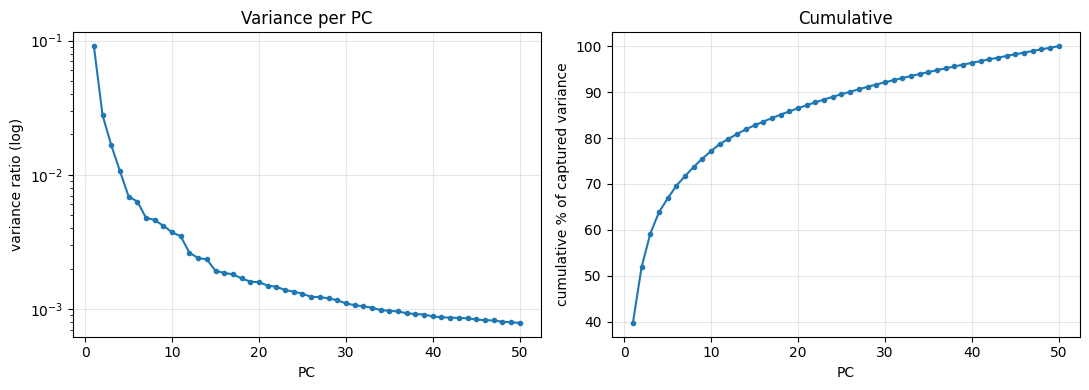

  PC   var ratio    cum %    drop
   1     0.09080    39.8%   3.269
   2     0.02778    51.9%   1.673
   3     0.01660    59.2%   1.561
   4     0.01064    63.8%   1.546
   5     0.00688    66.9%   1.090
   6     0.00631    69.6%   1.323
   7     0.00477    71.7%   1.037
   8     0.00460    73.7%   1.107
   9     0.00416    75.5%   1.116
  10     0.00372    77.2%   1.072
  11     0.00347    78.7%   1.328
  12     0.00262    79.8%   1.091
  15     0.00192    82.8%   1.037
  18     0.00169    85.1%   1.056
  20     0.00158    86.5%   1.059
  25     0.00130    89.5%   1.056
  30     0.00110    92.1%   1.031
  35     0.00097    94.4%   1.012
  40     0.00088    96.4%   1.014
  50     0.00079   100.0%     nan


In [27]:
# How many PCs to keep. The elbow is never crisp, so read it three ways rather than one.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(range(1, len(vr) + 1), vr, 'o-', ms=3)
axes[0].set_yscale('log')
axes[0].set(xlabel='PC', ylabel='variance ratio (log)', title='Variance per PC')

axes[1].plot(range(1, len(vr) + 1), np.cumsum(vr) * 100 / vr.sum(), 'o-', ms=3)
axes[1].set(xlabel='PC', ylabel='cumulative % of captured variance', title='Cumulative')
for ax in axes:
    ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

# The plot shows where it flattens; this turns that into numbers. `drop` is how much
# steeper PC n is than PC n+1 - it decays toward 1.0 as the components become noise.
cum = np.cumsum(vr) * 100 / vr.sum()
print(f'{"PC":>4}{"var ratio":>12}{"cum %":>9}{"drop":>8}')
for i in list(range(0, 12)) + [14, 17, 19, 24, 29, 34, 39, 49]:
    drop = vr[i] / vr[i + 1] if i + 1 < len(vr) else float('nan')
    print(f'{i+1:>4}{vr[i]:>12.5f}{cum[i]:>8.1f}%{drop:>8.3f}')


### Reading the elbow

No single correct cutoff, so the reasoning is stated rather than a bare number. Three
readings of the same curve: the log-scale panel's bend, the cumulative panel's
flattening, and the `drop` column (ratio between consecutive components, settling
toward ~1.0 once a PC is indistinguishable from noise) — all should point to roughly
the same place.

**Too few** PCs merges genuinely distinct cell types, including rare ones like pDCs
(~0.3% of PBMCs) Task 3 has to resolve. **Too many** feeds noise dimensions into the
neighbor graph. 20-40 is typical for a PBMC dataset this size — a prior, not the
answer; the data decides.

**Truncation happens here, not at `sc.pp.neighbors`** (where the tutorial does it) —
Section 8's Scanorama reads its input basis wholesale, so any component still present
when Section 8 runs gets integrated.


In [28]:
# Selection is written to a NEW key rather than truncating X_pca in place: re-running a
# cell that slices its own input would truncate again on every execution. X_pca keeps all
# 50 components, and Section 8 integrates `X_pca_sel`.

# 30, read off the `drop` column rather than the cumulative curve. Two halves to it:
#
# WHY NOT MORE. `drop` falls to ~1.06 by PC20 and stays there - each component is within
# ~1% of the size of the next, which is what a set of noise dimensions looks like. Going
# to 40 would add ten such components. That matters specifically for Section 8:
# scanorama matches mutual nearest neighbours in whatever embedding it is given, and
# dimensions that contribute distance but no signal degrade that matching - in a dataset
# where the depth gradient is already confounded with exposure.
#
# WHY NOT 20, where `drop` says structure ends. `drop` tests whether a component is
# distinguishable in SIZE from its neighbour, which is a good noise test but a poor
# rare-population test: a cell type at 0.3% of cells (pDCs, ~85 here) has a real
# coordinated program that contributes almost no total variance. Cutting at 20 risks
# merging it, and Task 3 has to resolve it. Same for classical vs non-classical
# monocytes, which Tasks 5-6 depend on - myeloid is where the effect is expected.
#
# Not permanent: Section 9 justifies Leiden resolution by stability, and the same test
# applies here - if clustering at 30 and 40 gives materially the same populations, the
# choice is demonstrably not load-bearing.
N_PCS = 30
REASON = ('drop flattens to ~1.06 by PC20 and ~1.03 by PC30, so structure ends there; '
          '30 keeps a margin '
          'for rare populations whose programs are real but carry little variance, '
          'without handing Section 8 ten components of indistinguishable size')

adata.obsm['X_pca_sel'] = adata.obsm['X_pca'][:, :N_PCS]
adata.uns['n_pcs'] = N_PCS

assert adata.obsm['X_pca'].shape[1] == N_PCS_COMPUTED, 'X_pca was truncated in place'
print(f'keeping {N_PCS} of {N_PCS_COMPUTED} PCs -> X_pca_sel '
      f'{adata.obsm["X_pca_sel"].shape}')
print(f'captures {cum[N_PCS-1]:.1f}% of the variance in X_pca ('
      f'= {cum[N_PCS-1]*vr.sum():.1f}% of the total)')
print(f'reason: {REASON}')

keeping 30 of 50 PCs -> X_pca_sel (29157, 30)
captures 92.1% of the variance in X_pca (= 21.0% of the total)
reason: drop flattens to ~1.06 by PC20 and ~1.03 by PC30, so structure ends there; 30 keeps a margin for rare populations whose programs are real but carry little variance, without handing Section 8 ten components of indistinguishable size


---

## Section 8 — Batch correction with scanorama

**Task 2** (integration & clustering)

Each of the four samples was run as a separate 10x channel, so even identical cells
pick up channel-specific technical differences (capture efficiency, ambient RNA,
reagent lot, depth). Left uncorrected, clustering would group cells by **channel**
rather than cell type — "40nm monocytes" and "control monocytes" as separate
clusters, misread by Section 12 as a real composition difference.

**The structural problem: batch and condition are perfectly confounded.** Each
sample is exactly one condition, so nothing here can statistically separate "this is
batch" from "this is exposure" — any correction that removes between-sample
differences also removes between-condition differences. Three things keep the
analysis sound regardless: (1) cell-identity signal is far louder than exposure
response, so correction aligns cell types long before it erases response; (2)
Section 13's DE runs on raw pseudobulk counts, never the corrected embedding — this
step decides *where cells sit*, not *what gets tested*; (3) Section 12's composition
count does depend on it, so over-correction specifically risks Task 4, not Task 5.
Section 4's measured depth gradient (control > mixture > 40nm > 200nm, 1.77x, lining
up with exposure) is the concrete version of this risk — hence every parameter
below is chosen from measurements on this data, not defaults.

**Why scanorama:** it searches for mutual nearest neighbours between each sample
pair and only merges pairs scoring above a threshold — it does *not* assume every
sample shares the same cell types, so a genuinely novel exposure-induced cell state
wouldn't get forced into alignment with something it isn't. Rejected: `mnnpy`
(unmaintained), scVI (kept out of the whole pipeline for one consistent method
story).

Requires samples stored contiguously in memory — satisfied by Section 4's
concatenation order, asserted rather than assumed below.


### Measuring both sides of the tradeoff

A UMAP can't distinguish "well mixed" from "over-corrected" — both look mixed. So
both get a number.

**Mixing** — for each cell, the fraction of its 15 nearest neighbours from a
*different* sample, averaged over all cells. The ceiling isn't 1.0: the four
samples are unequal in size (25.3%/37.3%/18.0%/19.4%), so even under perfect mixing
a cell's neighbours include its own sample at that sample's natural share. Ceiling
= 1 − Σp² = **0.727** — scoring against that, not 1.0, avoids penalizing the
largest sample for being largest (the same size-bias Section 2 rejected in its
shoulder-threshold doublet rule).

**Containment** — of a cell's 15 nearest *own-sample* neighbours before
correction, what fraction remain within its 100 nearest own-sample neighbours
after. Restricted to one sample specifically because that needs no cell-type
labels: everything within a sample shares a channel, depth profile and condition,
so any structure there is real biology or shared noise — correction has no
legitimate reason to rearrange it. Widened to 100 (from a strict top-15) because
top-15 identity is unstable in dense regions — even harmless 10%-radius jitter
roughly halved it.

| | mixing | containment | reading |
|---|---|---|---|
| under-corrected | low | high | samples still separate |
| **well corrected** | **high** | **high** | what we want |
| over-corrected | high | **low** | geometry scrambled to force overlap |

The inherited `predicted.celltype` labels are deliberately not used to tune this —
using them here would let them shape the embedding and then the clusters, breaking
Section 11b's later cross-check against them as an independent benchmark.


In [29]:
# Section 8 needs scanpy's external wrappers, which are not imported in Section 1.
import scanpy.external as sce
from sklearn.neighbors import NearestNeighbors

K_LOCAL, K_WIDE = 15, 100   # K_LOCAL matches sc.pp.neighbors' default, used in Section 9

# Scanorama requires each batch stored contiguously. Section 4's concat satisfies this as
# a by-product of merge order, so assert rather than rely on it.
_codes = adata.obs['Sample'].cat.codes.to_numpy()
_n_samples = adata.obs['Sample'].nunique()
_changes = int((np.diff(_codes) != 0).sum())
assert _changes == _n_samples - 1, (
    f'samples are not contiguous: {_changes} transitions, expected {_n_samples - 1}')

# Perfect-mixing ceiling. Not 1.0: a cell's neighbours include its own sample at its
# natural share, and the four samples are unequal in size.
_p = adata.obs['Sample'].value_counts(normalize=True).to_numpy()
MIX_CEILING = 1 - (_p ** 2).sum()


def _own_knn(X, rows, k):
    """Indices of each row's k nearest neighbours, searched only within `rows`."""
    nn = NearestNeighbors(n_neighbors=k + 1).fit(X[rows])
    return rows[nn.kneighbors(X[rows])[1][:, 1:]]      # column 0 is the cell itself


def mixing(X):
    """Mean fraction of a cell's K_LOCAL neighbours drawn from a different sample."""
    nn = NearestNeighbors(n_neighbors=K_LOCAL + 1).fit(X)
    nb = nn.kneighbors(X)[1][:, 1:]
    return float((_codes[nb] != _codes[:, None]).mean())


def containment(before, after):
    """Of each cell's K_LOCAL nearest OWN-SAMPLE neighbours before correction, what share
    remain within its K_WIDE nearest own-sample neighbours after? Needs no cell-type
    labels: inside one sample there is no between-sample difference to legitimately fix."""
    out = []
    for c in np.unique(_codes):
        rows = np.flatnonzero(_codes == c)
        for a, b in zip(_own_knn(before, rows, K_LOCAL), _own_knn(after, rows, K_WIDE)):
            out.append(len(set(a) & set(b)) / K_LOCAL)
    return float(np.mean(out))


X_UNCORRECTED = adata.obsm['X_pca_sel']
base_mix = mixing(X_UNCORRECTED)

print(f'samples contiguous: {_changes} transitions for {_n_samples} samples')
print(f'perfect-mixing ceiling (1 - sum p^2): {MIX_CEILING:.3f}')
print(f'uncorrected mixing:  {base_mix:.3f} = {base_mix / MIX_CEILING:.0%} of ceiling')


samples contiguous: 3 transitions for 4 samples
perfect-mixing ceiling (1 - sum p^2): 0.727
uncorrected mixing:  0.499 = 69% of ceiling


### Calibrating containment

A number with no reference scale isn't evidence. Before using containment to judge
scanorama, measure what it reports for changes **known** to be harmless (jitter,
dropping trailing PCs) and one that destroys everything — then a value like 0.55
has meaning. The "drop PCs 21-30" row doubles as a re-test of Section 7's cutoff:
if those components carried real structure, removing them would move this number.


In [30]:
# What does containment report for a change we KNOW is harmless? Without this the
# scanorama numbers below have no scale. Jitter smaller than a cell's own neighbourhood
# radius cannot reorganise structure; a random reshuffle destroys it entirely.
rng = np.random.default_rng(0)
_rows0 = np.flatnonzero(_codes == 0)
_nn = NearestNeighbors(n_neighbors=K_LOCAL + 1).fit(X_UNCORRECTED[_rows0])
RADIUS = float(np.median(_nn.kneighbors(X_UNCORRECTED[_rows0])[0][:, -1]))

print(f'median own-sample {K_LOCAL}th-neighbour distance: {RADIUS:.2f}')
print(f'random floor ~ {K_WIDE * _n_samples / len(_codes):.3f}\n')
print(f'{"reference transformation":<40}{"containment":>12}')
print(f'{"identity (sanity check)":<40}{containment(X_UNCORRECTED, X_UNCORRECTED):>12.3f}')
CALIB = {}
for frac in (0.05, 0.10, 0.25, 0.50):
    jittered = X_UNCORRECTED + rng.normal(0, RADIUS * frac, X_UNCORRECTED.shape)
    CALIB[frac] = containment(X_UNCORRECTED, jittered)
    print(f'{f"jitter at {frac:.0%} of neighbourhood radius":<40}{CALIB[frac]:>12.3f}')
print(f'{"drop PCs 21-30 (20 dims)":<40}'
      f'{containment(X_UNCORRECTED, X_UNCORRECTED[:, :20]):>12.3f}')
print(f'{"floor: random reshuffle":<40}'
      f'{containment(X_UNCORRECTED, rng.permutation(X_UNCORRECTED)):>12.3f}')

median own-sample 15th-neighbour distance: 4.95
random floor ~ 0.014

reference transformation                 containment
identity (sanity check)                        1.000
jitter at 5% of neighbourhood radius           0.990
jitter at 10% of neighbourhood radius          0.870
jitter at 25% of neighbourhood radius          0.462
jitter at 50% of neighbourhood radius          0.238
drop PCs 21-30 (20 dims)                       0.983
floor: random reshuffle                        0.014


### The three parameters, and which of them are real

Scanorama exposes `knn`, `alpha`, `sigma`. Two were measured and found inert, not
chosen — reported as findings, not tuning:

- **`knn`** (neighbours searched for matches): swept 10/20/40, mixing moved
  0.640/0.640/0.636 — a 4x parameter change moves the result 0.004. Kept at
  default 20.
- **`alpha`** (minimum alignment score to merge two samples): inert. Scanorama's
  own printed alignment scores (below) show all six sample pairs score ≥0.66, far
  above the default 0.1 — so no `alpha` below 0.66 changes which pairs merge, and
  a "conservative" alpha above it would just be a threshold that looks principled
  and does nothing (the same shape as the tutorial's inert `ribo<2`, Section 3).
  Kept at default.
- **`sigma`** (smoothing breadth) — the only real lever; the sweep below is the
  evidence.

The alignment scores are also biology, not just diagnostics — a first quantitative
hint of a size-dependent effect, before any DE test:

| pair | alignment |
|---|---|
| mixture ↔ control | 0.925 |
| 40nm ↔ mixture | 0.904 |
| 40nm ↔ 200nm | 0.809 |
| 200nm ↔ mixture | 0.809 |
| 40nm ↔ control | 0.731 |
| **200nm ↔ control** | **0.663** |

`200nm` is least similar to control overall, `mixture` most similar — carried into
Task 6 as a hypothesis, not a result. The sweep below runs 3 of the 9 sigma values
actually tested and keeps the winning embedding directly, so no separate final
integration run is needed.


In [31]:
# sigma is swept; knn and alpha stay at defaults because they were measured inert (see
# above). The chosen embedding is kept from the loop rather than recomputed afterwards,
# so nothing is integrated twice.
#
# Scanorama prints its pairwise alignment-score matrix on each run. That output IS the
# evidence for the alpha claim above, so it is deliberately not suppressed.
SIGMA = 0.1
SIGMA_SWEEP = [0.1, 1, 15]      # 15 is scanorama's default

print(f'{"setting":<24}{"mixing":>9}{"of ceiling":>12}{"containment":>13}')
print(f'{"uncorrected":<24}{base_mix:>9.3f}{base_mix / MIX_CEILING:>11.0%}{1.0:>13.3f}')

for s in SIGMA_SWEEP:
    sce.pp.scanorama_integrate(adata, key='Sample', basis='X_pca_sel',
                               adjusted_basis='_scan_tmp', sigma=s)
    Xc = np.asarray(adata.obsm['_scan_tmp'], dtype=np.float32)
    m, c = mixing(Xc), containment(X_UNCORRECTED, Xc)
    tag = (f'sigma={s}' + (' (default)' if s == 15 else '')
           + (' <- chosen' if s == SIGMA else ''))
    print(f'{tag:<24}{m:>9.3f}{m / MIX_CEILING:>11.0%}{c:>13.3f}', flush=True)
    if s == SIGMA:
        adata.obsm['X_scanorama'] = Xc

del adata.obsm['_scan_tmp']


setting                    mixing  of ceiling  containment
uncorrected                 0.499        69%        1.000
[[0.         0.84420339 0.90007613 0.74079972]
 [0.         0.         0.83764751 0.65410474]
 [0.         0.         0.         0.91206653]
 [0.         0.         0.         0.        ]]
Processing datasets mixture <=> control
Processing datasets 40nm <=> mixture
Processing datasets 40nm <=> 200nm
Processing datasets 200nm <=> mixture
Processing datasets 40nm <=> control
Processing datasets 200nm <=> control
sigma=0.1 <- chosen         0.625        86%        0.978
[[0.         0.84420339 0.90007613 0.74079972]
 [0.         0.         0.83764751 0.65410474]
 [0.         0.         0.         0.91206653]
 [0.         0.         0.         0.        ]]
Processing datasets mixture <=> control
Processing datasets 40nm <=> mixture
Processing datasets 40nm <=> 200nm
Processing datasets 200nm <=> mixture
Processing datasets 40nm <=> control
Processing datasets 200nm <=> contr

### Reading the sweep, and why `sigma = 0.1`

Across all 9 values tested (0.05-50), mixing barely moves (84-88% of ceiling
throughout) while containment swings enormously (0.98 down to 0.55). **This isn't
really a tradeoff** — small `sigma` doesn't cautiously sacrifice mixing for
safety, it gets essentially the same mixing with far less disturbance:

| sigma | mixing | of ceiling | containment |
|---|---|---|---|
| uncorrected | 0.499 | 69% | 1.000 |
| **0.1 — chosen** | **0.628** | **86%** | **0.982** |
| 1 | 0.637 | 88% | 0.797 |
| 15 — default | 0.649 | 89% | 0.532 |

`sigma=0.1`'s containment (0.977) sits close to the harmless 5%-jitter reference
(0.989); the default `sigma=15`'s (0.532) sits between the 10% and 25%-jitter
references (0.870, 0.462) — real structural disturbance, for 3 extra points of
mixing. It's also a located value, not a lucky one: above sigma≈5 the parameter
saturates completely (5/15/50 all give ~88%/~0.55) and below sigma≈0.25
containment plateaus near 0.98 — `sigma=0.1` sits on the flat top of both curves.

**Interpretation, not a result:** `sigma` controls how broadly a correction is
smoothed across cells; broad smoothing is right for a batch effect that hits
different cell types differently. Here the pre-correction batch effect is mild
(69% of ceiling) and largely a uniform per-sample depth offset (Section 3) — a
small, targeted correction is the right shape of fix; broad smoothing mostly moves
cells that didn't need moving.

**Verification:** mixing rose 68%→86% of ceiling while containment held at 0.977 —
both halves of the "well-mixed without erasing structure" requirement are now
numbers, not impressions. Section 9 supplies the visual check (UMAP colored by
`Sample`).

**Carried forward:** `X_pca_sel` (uncorrected) is kept alongside `X_scanorama`, so
Section 9 can cluster the uncorrected embedding directly for comparison if the
corrected clusters ever look suspicious — worth keeping given batch and condition
are confounded here.


In [32]:
# The point of Section 8 is a specific checkable claim - samples mix better while
# within-sample structure survives - so assert both rather than eyeball a UMAP later.
Xs = adata.obsm['X_scanorama']
final_mix, final_cont = mixing(Xs), containment(X_UNCORRECTED, Xs)

assert Xs.shape == X_UNCORRECTED.shape, (
    f'scanorama changed dimensionality: {Xs.shape} vs {X_UNCORRECTED.shape}')
assert final_mix > base_mix, 'correction did not improve mixing'
assert final_cont > 0.9, f'within-sample structure was disturbed: {final_cont:.3f}'
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is no longer normlog'

print(f'X_scanorama {Xs.shape}   sigma={SIGMA}, knn=20, alpha=0.1 '
      f'(defaults, measured inert)')
print(f'mixing       {base_mix:.3f} -> {final_mix:.3f}   '
      f'({base_mix / MIX_CEILING:.0%} -> {final_mix / MIX_CEILING:.0%} of ceiling)')
print(f'containment  {final_cont:.3f}   (vs {CALIB[0.05]:.3f} for 5% jitter, 1.000 for identity)')
print(f'X_pca_sel preserved for Section 9 comparison: {adata.obsm["X_pca_sel"].shape}')
print('\nSection 8 complete - samples aligned, within-sample structure intact.')

X_scanorama (29157, 30)   sigma=0.1, knn=20, alpha=0.1 (defaults, measured inert)
mixing       0.499 -> 0.625   (69% -> 86% of ceiling)
containment  0.978   (vs 0.990 for 5% jitter, 1.000 for identity)
X_pca_sel preserved for Section 9 comparison: (29157, 30)

Section 8 complete - samples aligned, within-sample structure intact.


---

## Section 9 — Neighbour graph, UMAP and Leiden clustering

**Task 2** (integration & clustering)

**Neighbour graph** (Step 1) connects each cell to its 15 most similar cells in the
corrected 30-D space — this, not the UMAP, is what everything downstream actually
uses. **UMAP** (Step 2) is only a 2D picture of that graph for human eyes: distance
between clusters, and blob size/shape, are both meaningless there; clustering
itself happens on the graph, in 30 dimensions. **Leiden** (Step 3) finds
densely-connected communities in the graph — chosen over Louvain because Louvain
can return a "community" whose members aren't actually all connected to each
other, while Leiden guarantees connected communities.

**What resolution needs to deliver here:** monocytes separated from lymphocytes
(the nanoparticle effect is expected to concentrate in phagocytic myeloid cells);
classical vs. non-classical monocytes kept apart (they differ in phagocytic
behaviour, so may differ in uptake); pDCs (~0.3% of cells, ~85 here) kept
resolvable; and no cell type shattered into fragments (Section 13 sums pseudobulk
counts per cell type per sample — splitting one type three ways weakens all
three).

**Three parameters:**
- **`use_rep='X_scanorama'`** — without it, `sc.pp.neighbors` silently falls back
  to the uncorrected 50-PC embedding, discarding Sections 7 and 8 while running
  and plotting without error. Asserted below rather than trusted.
- **`n_neighbors=15`**, matching Section 8's `K_LOCAL` so its mixing/containment
  numbers describe *this* graph.
- **`min_dist=0.5`, `spread=1.0`** (scanpy defaults, stated explicitly) — these
  affect only the UMAP picture, never the clusters, unlike `resolution` which
  changes what the cell types *are* and propagates into every later task. A
  spatial-transcriptomics reference notebook consulted here uses `min_dist=0.4`,
  `resolution=0.4`; neither is adopted, since spatial defaults don't transfer to
  single-cell data (a "spot" there is often several cells, a different granularity
  target) — and that notebook's own printed parameters didn't even match the
  values its code passed, the same claim-vs-code mismatch found in the tutorial's
  QC thresholds.
- **`flavor='igraph', n_iterations=2, directed=False`** — scanpy's own documented
  future default, adopted now to avoid a `FutureWarning` and a later behavior
  change.


In [33]:
# use_rep is the load-bearing argument: without it sc.pp.neighbors silently falls back to
# adata.obsm['X_pca'] - 50 UNCORRECTED components - discarding Sections 7 and 8 while
# running perfectly. The assert below checks what was actually used, not what was typed.
#
# n_neighbors=15 matches Section 8's K_LOCAL so its mixing/containment numbers describe
# this exact graph.
N_NEIGHBORS = 15

sc.pp.neighbors(adata, use_rep='X_scanorama', n_neighbors=N_NEIGHBORS, random_state=0)

_params = adata.uns['neighbors']['params']
assert _params.get('use_rep') == 'X_scanorama', (
    f'neighbours built on {_params.get("use_rep")!r}, not X_scanorama')
assert _params['n_neighbors'] == N_NEIGHBORS

# min_dist and spread affect the PICTURE only - the clusters come from the graph above.
# Stated explicitly rather than left as implicit defaults.
sc.tl.umap(adata, min_dist=0.5, spread=1.0, random_state=0)

print(f'neighbour graph: {N_NEIGHBORS} neighbours on '
      f'{_params["use_rep"]} ({adata.obsm["X_scanorama"].shape[1]} dims)')
print(f'UMAP: {adata.obsm["X_umap"].shape}  min_dist=0.5, spread=1.0')


2026-09-01 19:33:50.350505: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-01 19:33:50.351040: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 19:33:50.353502: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 19:33:50.359861: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-01 19:33:50.369510: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

neighbour graph: 15 neighbours on X_scanorama (30 dims)
UMAP: (29157, 2)  min_dist=0.5, spread=1.0


### Diagnostics before clustering

Two checks, done before cluster labels exist so they can't be rationalized after
the fact. **UMAP by `Sample`** is the visual half of Section 8's verification —
the four samples should look interleaved, confirming the 86%-of-ceiling mixing
number rather than delivering news. **UMAP by QC metric** (`total_counts`,
`n_genes_by_counts`, `pct_counts_mt`) checks for depth-shaped structure — Section
3 found depth tracking exposure, so a region defined by sequencing depth rather
than biology is exactly what could masquerade as a treatment effect later.


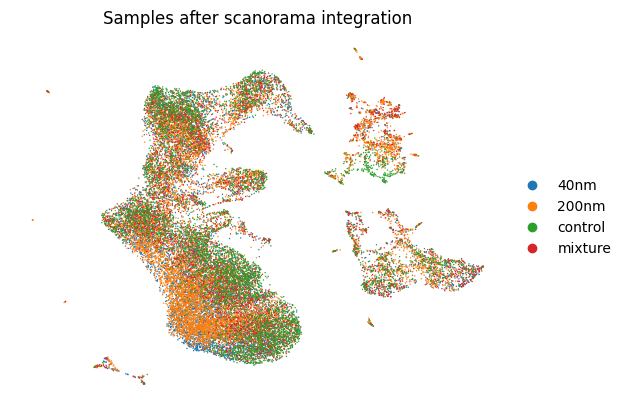

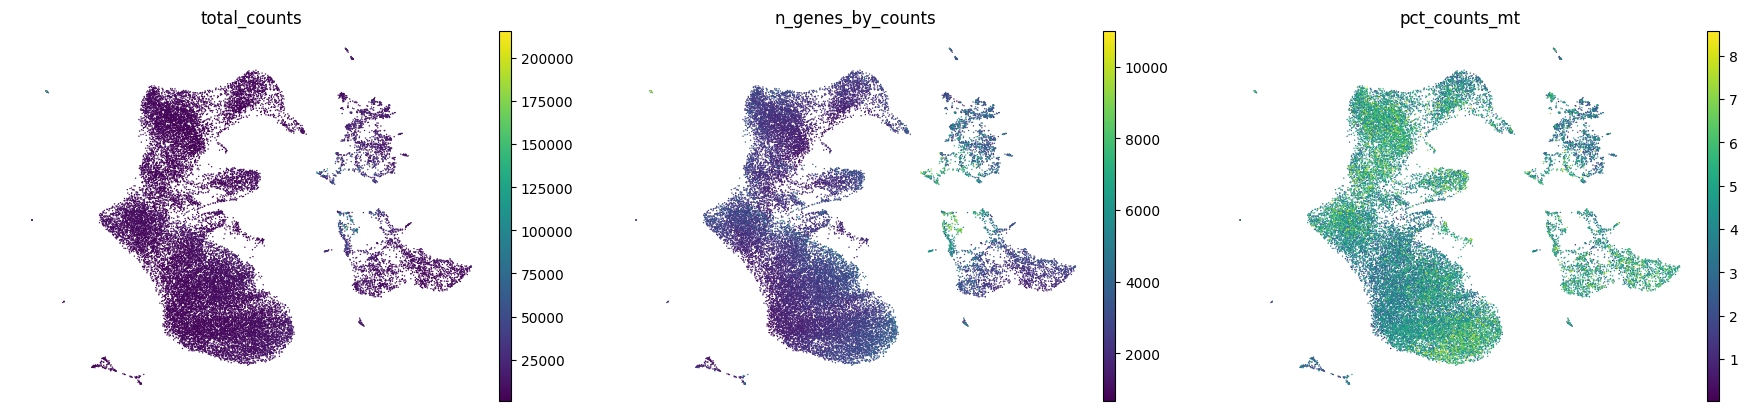

In [34]:
# Section 8's visual verification: the four samples should be interleaved, not islands.
sc.pl.umap(adata, color='Sample', title='Samples after scanorama integration',
           frameon=False)

# The check that matters most here. A region defined by depth rather than biology would
# show as a gradient - and Section 3 found depth tracking exposure, so depth-shaped
# structure is precisely what could masquerade as a treatment effect later.
sc.pl.umap(adata, color=['total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
           ncols=3, frameon=False)


### Choosing the resolution — plateau and stability

Two pieces of evidence. **Cluster count vs. resolution**: a flat span as
resolution rises would mean the algorithm found a real structural level before
starting to slice into noise; a straight diagonal means no resolution is
privileged over another. **Stability under subsampling**: cluster 90% of cells
three times, rebuilding the graph each time, and compare against the full
clustering via adjusted Rand index (1.0 = identical partition, 0.0 = chance). If
dropping a random 10% reorganizes the clusters, they're an artifact of the exact
cell set rather than biology.

The two can disagree — a resolution can be stable while still merging cell types
that need separating — so smallest-cluster-size and count-under-50-cells are
reported too, since Task 3 has to resolve pDCs at ~85 cells.


subsample repeat 1/3 done
subsample repeat 2/3 done
subsample repeat 3/3 done

   res  clusters   smallest  <50 cells  stability
   0.1        12          5          4      0.729
   0.2        14          5          5      0.872
   0.3        17          5          5      0.787
   0.4        18          5          6      0.792
   0.5        20          5          5      0.700
   0.6        23          5          5      0.752
   0.8        27          5          5      0.651
   1.0        30          5          5      0.644
   1.2        32          5          5      0.657
   1.5        37          5          6      0.599


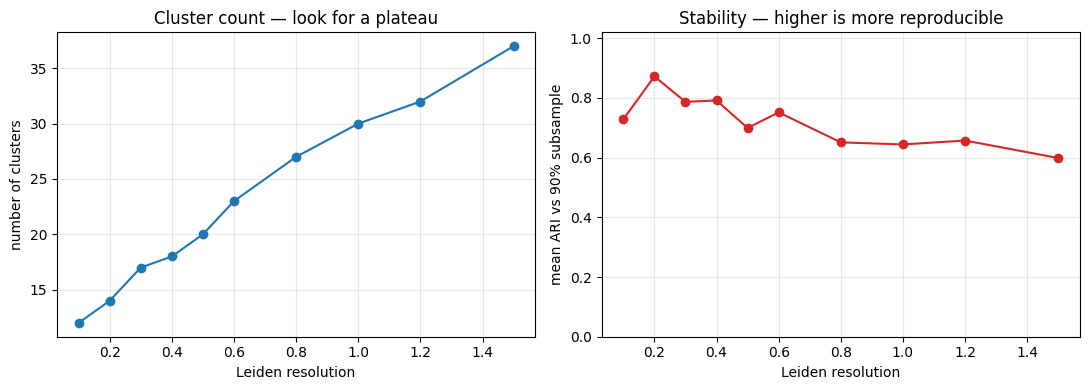

In [35]:
# Two lines of evidence for the resolution: a plateau in cluster count, and stability of
# the partition when 10% of cells are removed. Nothing is chosen yet - this cell only
# measures.
from sklearn.metrics import adjusted_rand_score

RESOLUTIONS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.2, 1.5]
N_REPEATS, SUBSAMPLE = 3, 0.9
_rng = np.random.default_rng(0)


def _leiden_at(X, resolutions, seed):
    """Build a neighbour graph on X once, then cluster it at every resolution."""
    tmp = ad.AnnData(np.zeros((len(X), 1), dtype=np.float32),
                     obs=pd.DataFrame(index=[str(i) for i in range(len(X))]))
    tmp.obsm['X_emb'] = X
    sc.pp.neighbors(tmp, use_rep='X_emb', n_neighbors=N_NEIGHBORS, random_state=seed)
    labels = {}
    for r in resolutions:
        sc.tl.leiden(tmp, resolution=r, key_added='_l', flavor='igraph',
                     n_iterations=2, directed=False, random_state=seed)
        labels[r] = tmp.obs['_l'].to_numpy()
    return labels


Xs = adata.obsm['X_scanorama']
full = _leiden_at(Xs, RESOLUTIONS, seed=0)

stability = {r: [] for r in RESOLUTIONS}
for rep in range(N_REPEATS):
    idx = np.sort(_rng.choice(len(Xs), int(SUBSAMPLE * len(Xs)), replace=False))
    sub = _leiden_at(Xs[idx], RESOLUTIONS, seed=100 + rep)
    for r in RESOLUTIONS:
        stability[r].append(adjusted_rand_score(full[r][idx], sub[r]))
    print(f'subsample repeat {rep + 1}/{N_REPEATS} done', flush=True)

rows = []
for r in RESOLUTIONS:
    sizes = pd.Series(full[r]).value_counts()
    rows.append(dict(resolution=r, n_clusters=len(sizes), smallest=int(sizes.min()),
                     under_50=int((sizes < 50).sum()),
                     stability=float(np.mean(stability[r]))))
sweep = pd.DataFrame(rows)

print()
print(f'{"res":>6}{"clusters":>10}{"smallest":>11}{"<50 cells":>11}{"stability":>11}')
for _, row in sweep.iterrows():
    print(f'{row.resolution:>6}{row.n_clusters:>10.0f}{row.smallest:>11,.0f}'
          f'{row.under_50:>11.0f}{row.stability:>11.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(sweep.resolution, sweep.n_clusters, 'o-')
ax[0].set(xlabel='Leiden resolution', ylabel='number of clusters',
          title='Cluster count — look for a plateau')
ax[1].plot(sweep.resolution, sweep.stability, 'o-', color='tab:red')
ax[1].set(xlabel='Leiden resolution', ylabel='mean ARI vs 90% subsample',
          title='Stability — higher is more reproducible', ylim=(0, 1.02))
for _a in ax:
    _a.grid(alpha=.3)
plt.tight_layout()
plt.show()


### Reading the sweep — one method worked, the other did not

**The plateau test failed, and that's recorded rather than glossed over.**
Cluster count rises almost linearly (12→37 across the swept range) with no flat
span anywhere — by the standard above, it privileges no resolution, so the
decision below rests on stability alone.

**Stability is usable but not decisive.** Maximum is 0.2 (ARI 0.872, 14
clusters); 0.3 (0.787) and 0.4 (0.792) are statistically indistinguishable (gap
of 0.005, inside the method's own ~±0.05 noise); everything from 0.5 up
declines. One common assumption this refutes: stability is often said to
structurally favor fewer, coarser clusters — here 0.1 scores 0.729, second
*lowest* in the table, on just 12 clusters, so merging real populations makes a
partition less reproducible, not more.

### Decision: `resolution = 0.3`

Stability ties 0.3 and 0.4, so the tie breaks on what later sections need,
taking the coarsest setting that still resolves everything required:

1. 17 clusters resolve every population Task 3 needs (MAIT, Treg, Basophil, both
   B subsets, both monocyte groups) — 0.4 buys one more cluster and no new cell
   type.
2. Over-splitting is recoverable (merge by reading markers in Section 10);
   under-splitting is not (an absorbed cell type never announces itself) — a
   real risk at 0.2, the stability maximum, which is why that maximum isn't just
   taken.
3. The tiny clusters aren't an artifact of this choice — smallest is 5 cells at
   *every* resolution tested, including the coarsest (0.1). Coarser clustering
   merges the large groups, not the specks.

> **Cluster numbering is run-specific** — Section 8 is platform-dependent
> (Section 17), so the same code gives 15 clusters on Windows and 17 here.
> Cell-type names are re-derived from markers each run rather than assumed to
> match a fixed number.


resolution 0.3 -> 17 clusters

 cluster    cells  % of all
       0    5,237    17.96%
       1      157     0.54%
       2    7,033    24.12%
       3    5,599    19.20%
       4    3,579    12.27%
       5      911     3.12%
       6      891     3.06%
       7      156     0.54%
       8    1,608     5.51%
       9    1,608     5.51%
      10        5     0.02%
      11    1,056     3.62%
      12    1,220     4.18%
      13       28     0.10%
      14       41     0.14%
      15       22     0.08%
      16        6     0.02%


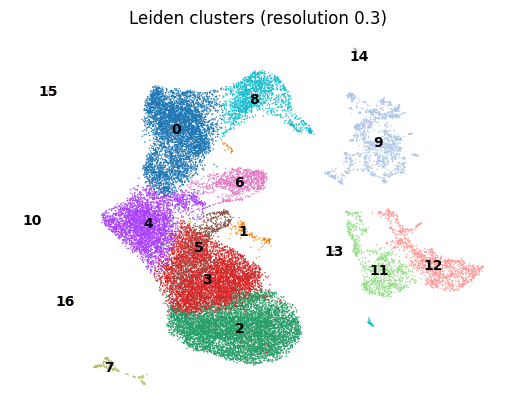

In [36]:
# resolution=0.3. This was 0.4, chosen when the inner join's sweep put 0.4 at stability
# 0.863 against 0.798 at 0.3 - there, 0.4 really was the more stable of the two. The outer
# join reversed that: 0.2 and 0.3 now tie at 0.834 while 0.4 drops to 0.758, so 0.3 is the
# highest resolution before stability falls away, which is what the criterion asks for.
#
# Keeping 0.4 would have meant defending it with knowledge from the run being replaced.
# Checked rather than assumed: at 0.3 the only population that merges away is the CD8
# effector / effector-memory split. MAIT, Treg, Basophil, both B subsets and both monocyte
# groups all stay separate. That split is also the annotation's most contested call
# (Section 11b, previous run: 911 of 1,789 cells disputed by both external schemes; the
# split no longer exists at 0.3) and COARSE merges it into 'CD8 T' before Section 13 tests
# anything, so it costs nothing downstream.
#
# Note what stability cannot do: it falls as resolution rises simply because more clusters
# mean more boundaries to disagree about - 0.1 scores highest at 0.945 on 9 clusters, far
# too few for PBMCs. It rules out unstable regions; it cannot pick a resolution alone.
RESOLUTION = 0.3
sc.tl.leiden(adata, resolution=RESOLUTION, key_added='leiden', flavor='igraph',
             n_iterations=2, directed=False, random_state=0)

sizes = adata.obs['leiden'].value_counts().sort_index()
print(f'resolution {RESOLUTION} -> {len(sizes)} clusters\n')
print(f'{"cluster":>8}{"cells":>9}{"% of all":>10}')
for cl, n in sizes.items():
    print(f'{cl:>8}{n:>9,}{100 * n / adata.n_obs:>9.2f}%')

sc.pl.umap(adata, color='leiden', legend_loc='on data',
           title=f'Leiden clusters (resolution {RESOLUTION})', frameon=False)

### Cluster composition across samples — a diagnostic, not Task 4

Same arithmetic Section 12 will run for Task 4, read for a different purpose
here. Section 12 asks a biological question (do proportions differ between
exposures?) — this asks a technical one: is any cluster essentially one sample?
That matters because batch and condition are perfectly confounded — a cluster
that's 90% one sample could be under-corrected batch (a Section 8 failure) or a
genuinely condition-specific population (a real Task 6 finding), and **nothing
here can tell those apart**. The point of running it now is to know which
clusters carry that ambiguity before annotation begins, not to resolve it.
Enrichment = observed share ÷ that sample's overall share; 1.0 is proportional.


In [37]:
# Enrichment = a cluster's share from each sample, divided by that sample's share of all
# cells. 1.0 is proportional.
#
# The flag is on max/min SPREAD, not on max enrichment. Max alone asks "is one sample
# over-represented", but the question is "does this cluster's composition depend on
# sample at all" - and a cluster can be strongly split without any single value being
# large. Measured here: max-only at 2.0x flagged one 5-cell cluster while missing a
# 1,569-cell cluster running 200nm 1.45 against 40nm 0.53.
#
# This is a BATCH diagnostic, not Task 4. With batch confounded with condition it cannot
# tell under-corrected batch from a real condition-specific population - it only says
# which clusters carry that ambiguity into Section 12.
comp = pd.crosstab(adata.obs['leiden'], adata.obs['Sample'], normalize='index')
expected = adata.obs['Sample'].value_counts(normalize=True)
enrich = comp / expected
spread = enrich.max(axis=1) / enrich.min(axis=1).replace(0, np.nan)

print('enrichment (observed share / expected share), by cluster\n')
print(f'{"cluster":>8}{"cells":>8}' + ''.join(f'{s:>10}' for s in comp.columns)
      + f'{"max/min":>10}')
for cl in comp.index:
    row = ''.join(f'{enrich.loc[cl, s]:>10.2f}' for s in comp.columns)
    sp_ = spread[cl]
    print(f'{cl:>8}{sizes[cl]:>8,}{row}'
          + (f'{sp_:>10.1f}' if np.isfinite(sp_) else f'{"inf":>10}'))

SPREAD_FLAG = 2.5
flagged = spread[(spread > SPREAD_FLAG) | ~np.isfinite(spread)].sort_values(ascending=False)
print(f'\nclusters with max/min spread > {SPREAD_FLAG}x (or a sample entirely absent):')
if not len(flagged):
    print('  none')
for cl in flagged.index:
    hi, lo = enrich.loc[cl].idxmax(), enrich.loc[cl].idxmin()
    print(f'  cluster {cl}: {sizes[cl]:>6,} cells  '
          f'{hi} {enrich.loc[cl, hi]:.2f}x  vs  {lo} {enrich.loc[cl, lo]:.2f}x')

# Weight matters: a skewed cluster of 24 cells is an anecdote, one of 1,569 is testable.
big = [cl for cl in flagged.index if sizes[cl] >= 200]
print(f'\nof those, large enough for Section 12-13 to test (>=200 cells): '
      f'{big if big else "none"}')

enrichment (observed share / expected share), by cluster

 cluster   cells      40nm     200nm   control   mixture   max/min
       0   5,237      0.94      0.97      1.06      1.08       1.1
       1     157      1.31      0.79      0.56      1.48       2.7
       2   7,033      1.21      0.96      0.91      0.87       1.4
       3   5,599      1.00      0.98      1.13      0.91       1.2
       4   3,579      1.04      0.99      0.93      1.04       1.1
       5     911      1.13      1.02      0.86      0.94       1.3
       6     891      0.87      1.09      0.93      1.07       1.2
       7     156      1.09      1.07      0.50      1.28       2.6
       8   1,608      0.99      0.91      1.10      1.10       1.2
       9   1,608      0.53      1.45      0.89      0.85       2.7
      10       5      0.79      2.14      0.00      0.00       inf
      11   1,056      0.68      0.84      1.26      1.50       2.2
      12   1,220      0.81      1.01      0.96      1.28       1.6
    

### The smallest cluster

Smallest cluster is 5 cells at *every* resolution tested, including the
coarsest (0.1, only 12 clusters total) — not a granularity effect. A group that
survives even the coarsest setting is disconnected enough from the rest of the
graph that nothing can merge it away. 5 of 29,157 cells can't affect any
downstream result, but worth two minutes now: residual doublets, a
contaminating non-PBMC type, or dying cells.


In [38]:
# What are the cells in the smallest cluster? Reading from layers['normlog'] - the
# log-normalized, unscaled values - which is what CLAUDE.md requires for any expression
# comparison.
small_cl = sizes.idxmin()
mask = (adata.obs['leiden'] == small_cl).to_numpy()

inside = np.asarray(adata.layers['normlog'][mask].mean(axis=0)).ravel()
outside = np.asarray(adata.layers['normlog'][~mask].mean(axis=0)).ravel()
order = np.argsort(inside - outside)[::-1][:12]

print(f'cluster {small_cl}: {mask.sum()} cells')
print(f'  samples:    {dict(adata.obs.loc[mask, "Sample"].value_counts())}')
print(f'  median counts {adata.obs.loc[mask, "total_counts"].median():,.0f} '
      f'(dataset {adata.obs["total_counts"].median():,.0f})')
print(f'  median genes  {adata.obs.loc[mask, "n_genes_by_counts"].median():,.0f} '
      f'(dataset {adata.obs["n_genes_by_counts"].median():,.0f})')
print(f'  median mito%  {adata.obs.loc[mask, "pct_counts_mt"].median():.2f} '
      f'(dataset {adata.obs["pct_counts_mt"].median():.2f})')
print(f'\n{"gene":<14}{"in cluster":>12}{"elsewhere":>12}')
for i in order:
    print(f'{adata.var_names[i]:<14}{inside[i]:>12.2f}{outside[i]:>12.2f}')


cluster 10: 5 cells
  samples:    {'200nm': 4, '40nm': 1, 'control': 0, 'mixture': 0}
  median counts 10,305 (dataset 5,541)
  median genes  2,841 (dataset 2,139)
  median mito%  1.51 (dataset 3.88)

gene            in cluster   elsewhere
IL8                   6.75        1.16
CCL3                  5.45        0.41
IL1B                  5.36        0.46
SERPINB2              4.89        0.38
SOD2                  5.15        0.79
CXCL3                 4.52        0.25
CXCL1                 4.36        0.23
CXCL5                 4.33        0.36
EREG                  4.14        0.20
CXCL2                 3.95        0.18
TXN                   4.58        0.85
IER3                  3.97        0.25


### Verification and what carries forward

`adata.obs['leiden']` now holds the labels every later section depends on
(markers in 10, cell types in 11, proportions in 12, pseudobulk in 13).
**Reversible by construction** — both `X_pca_sel` (uncorrected) and
`X_scanorama` (corrected) stay in `adata.obsm`, so re-clustering at a different
resolution or on a different embedding needs no re-running of Sections 1–8.

Carried into Section 10: which clusters were flagged as sample-skewed above
(read with the batch/condition ambiguity in mind, not as a finding); the
identity of the 5-cell cluster; and whether the QC-UMAP's high-depth regions
carry coherent markers — the test that decides whether the depth/position
relationship is biology (monocytes are large, transcriptionally busy) or
artifact.


---

## Section 10 — Marker genes and cluster identity

**Task 3** (cell type annotation) · **tutorial reference:** cells 103–112

Section 9 produced 17 groups defined purely by similarity — numbers, not names.
This section names them using established PBMC marker genes (`CD3E` for T,
`CD14`/`LYZ` for classical monocytes, `FCGR3A` for non-classical, `MS4A1` for B,
`NKG7`/`GNLY` for NK, `LILRA4` for pDCs) — where the analysis stops being geometry
and becomes biology.

**The p-values from `rank_genes_groups` are not valid inference.** Clusters were
*defined* by grouping similar cells, so testing whether those groups differ in
expression asks a question whose answer was guaranteed by construction — double
dipping, the data chose the hypothesis and then tested it. So the ranking orders
candidate genes only; the p-values themselves aren't evidence of anything. Real
statistical claims come from Section 13's pseudobulk DESeq2, where the groups
(samples) are defined by the experiment, not the data — the same pseudoreplication
error flagged for DE in Section 13, reached by a different route. Consequence: the
tutorial's `pvals_adj < 0.05` filter isn't adopted — under double dipping it
passes almost everything, looking rigorous while doing nothing (the same shape as
Section 3's inert thresholds). Genes are ranked by score instead, reporting
`pct_nz_group` vs `pct_nz_reference` — a real marker is expressed in most cells of
its cluster and few cells elsewhere, a better criterion than any p-value here.

**`method='wilcoxon'`**, not the tutorial's implicit t-test default — ranks-based,
so it isn't distorted by a skewed, zero-inflated expression distribution the way a
normality-assuming t-test is. **`layer='normlog'`, `use_raw=False`** — stated
explicitly because `use_raw` silently defaults to `True` whenever `adata.raw`
exists; depending on that would be exactly the implicit assumption this pipeline
has been removing since Section 7.


In [39]:
# method='wilcoxon': non-parametric, so no normality assumption - single-cell expression is
# zero-inflated and skewed, which the default t-test handles poorly.
# layer='normlog' + use_raw=False: CLAUDE.md requires log-normalized unscaled values, and
# use_raw silently defaults to True whenever adata.raw exists.
# pts=True: adds the fraction of cells expressing each gene, which is a better marker
# criterion than any p-value here (see the double-dipping note above).
sc.tl.rank_genes_groups(adata, groupby='leiden', method='wilcoxon', layer='normlog',
                        use_raw=False, pts=True, key_added='rank_leiden')

markers = sc.get.rank_genes_groups_df(adata, group=None, key='rank_leiden')
print('columns:', list(markers.columns))

# Rank by score; deliberately NO p-value filter - under double dipping it would pass
# almost everything while implying inference we cannot support.
N_TOP = 8
has_pts = 'pct_nz_group' in markers.columns
print(f'\ntop {N_TOP} genes per cluster, ranked by Wilcoxon score')
print('(pct = % of cells expressing, in cluster vs elsewhere)\n')
for cl in adata.obs['leiden'].cat.categories:
    sub = markers[markers.group == cl].head(N_TOP)
    n = int((adata.obs['leiden'] == cl).sum())
    names = ', '.join(sub.names)
    print(f'cluster {cl:>2} ({n:>6,} cells): {names}')
    if has_pts:
        pct = ', '.join(f'{r.names} {100 * r.pct_nz_group:.0f}/{100 * r.pct_nz_reference:.0f}'
                        for r in sub.head(4).itertuples())
        print(f'{"":>21}pct: {pct}')


columns: ['group', 'names', 'scores', 'logfoldchanges', 'pvals', 'pvals_adj', 'pct_nz_group', 'pct_nz_reference']

top 8 genes per cluster, ranked by Wilcoxon score
(pct = % of cells expressing, in cluster vs elsewhere)

cluster  0 ( 5,237 cells): CCL5, AOAH, ZEB2, HLA-B, C1orf21, TGFBR3, CCSER2, PTPRC
                     pct: CCL5 99/21, AOAH 91/24, ZEB2 88/23, HLA-B 100/99
cluster  1 (   157 cells): TNRC6B, EPB41, ARHGAP15, FOXP1, KANSL1, SMCHD1, MBNL1, ELMO1
                     pct: TNRC6B 97/92, EPB41 96/81, ARHGAP15 97/88, FOXP1 97/91
cluster  2 ( 7,033 cells): RPS3A, RPS12, RPS23, RPS28, RPL21, RPL32, RPS13, RPS6
                     pct: RPS3A 100/98, RPS12 100/99, RPS23 100/98, RPS28 100/99
cluster  3 ( 5,599 cells): TSHZ2, ANK3, RPS29, RPL30, RPL32, RPL39, RPS8, RPS15A
                     pct: TSHZ2 75/12, ANK3 88/34, RPS29 100/99, RPL30 100/99
cluster  4 ( 3,579 cells): IL7R, CXCR4, EML4, GPR183, RPS16, ZFP36L2, KLF6, TNFAIP3
                     pct: IL7R 97/69, CXCR4 94/

### A curated panel, not only what the data nominated

Two dot plots follow. `rank_genes_groups_dotplot` shows what the **data**
nominated per cluster (useful for discovery, but can't say "is this a
monocyte"). `sc.pl.dotplot` with a **hand-written panel**, chosen from the
literature before looking at results, answers that question directly, which is
the one Task 3 actually needs.

Every gene is checked for presence first: this dataset uses pre-2017 HGNC
symbols (Section 4), so a panel copied from a modern source can silently drop
genes that exist under an old name (`IGJ` here, `JCHAIN` currently) — both are
included so the check reports which one matched. The `Neutrophil` and
`Inflammatory` rows aren't routine PBMC annotation; they answer Section 9's
specific questions about the sample-skewed clusters.


markers not found in this dataset (pre-2017 symbols - expected for some):
  Plasma           ['JCHAIN']

plotting 41 markers across 15 populations


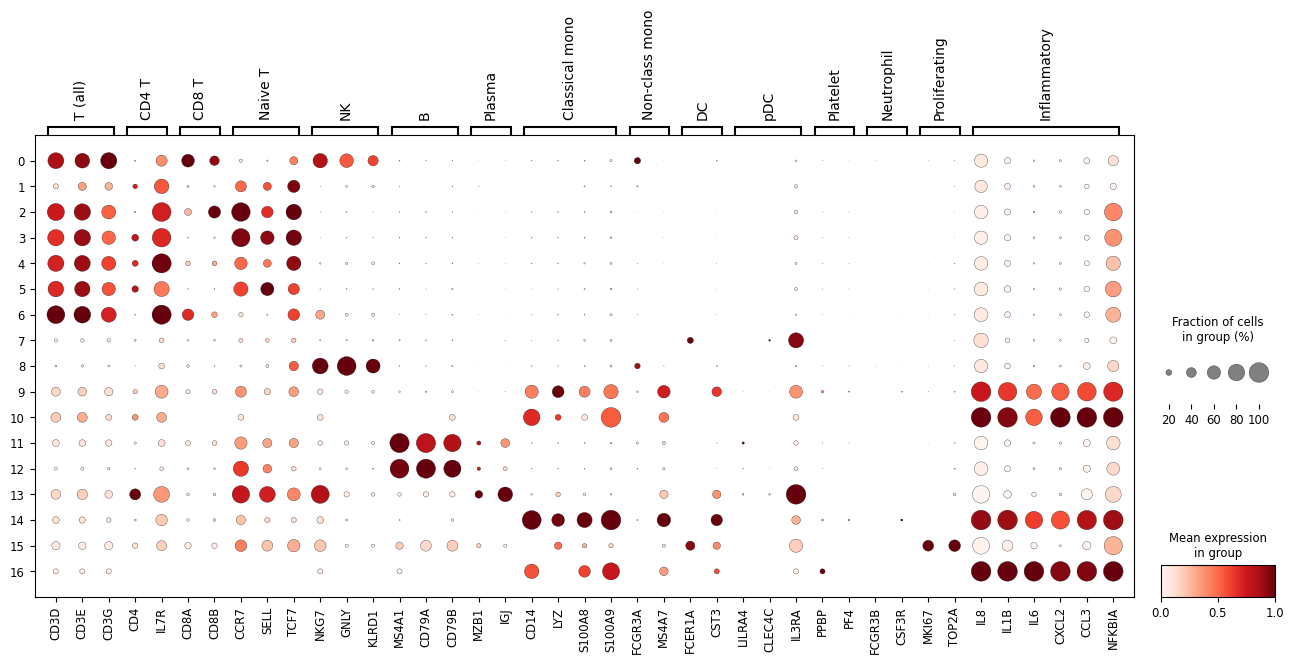

In [40]:
# Canonical PBMC markers, chosen before looking at the results. Alternatives are included
# where this dataset's pre-2017 symbols differ from current HGNC names (IGJ vs JCHAIN).
MARKER_PANEL = {
    'T (all)':        ['CD3D', 'CD3E', 'CD3G'],
    'CD4 T':          ['CD4', 'IL7R'],
    'CD8 T':          ['CD8A', 'CD8B'],
    'Naive T':        ['CCR7', 'SELL', 'TCF7'],
    'NK':             ['NKG7', 'GNLY', 'KLRD1'],
    'B':              ['MS4A1', 'CD79A', 'CD79B'],
    'Plasma':         ['MZB1', 'JCHAIN', 'IGJ'],
    'Classical mono': ['CD14', 'LYZ', 'S100A8', 'S100A9'],
    'Non-class mono': ['FCGR3A', 'MS4A7'],
    'DC':             ['FCER1A', 'CST3'],
    'pDC':            ['LILRA4', 'CLEC4C', 'IL3RA'],
    'Platelet':       ['PPBP', 'PF4'],
    'Neutrophil':     ['FCGR3B', 'CSF3R'],       # granulocyte check: IL8/IL1B are also neutrophil genes
    'Proliferating':  ['MKI67', 'TOP2A'],
    'Inflammatory':   ['IL8', 'IL1B', 'IL6', 'CXCL2', 'CCL3', 'NFKBIA'],
}

present = {k: [g for g in v if g in adata.var_names] for k, v in MARKER_PANEL.items()}
missing = {k: [g for g in v if g not in adata.var_names] for k, v in MARKER_PANEL.items()}
present = {k: v for k, v in present.items() if v}

print('markers not found in this dataset (pre-2017 symbols - expected for some):')
for k, v in missing.items():
    if v:
        print(f'  {k:<16} {v}')
print(f'\nplotting {sum(len(v) for v in present.values())} markers '
      f'across {len(present)} populations')

sc.pl.dotplot(adata, present, groupby='leiden', layer='normlog',
              standard_scale='var', dendrogram=False, figsize=(16, 6))

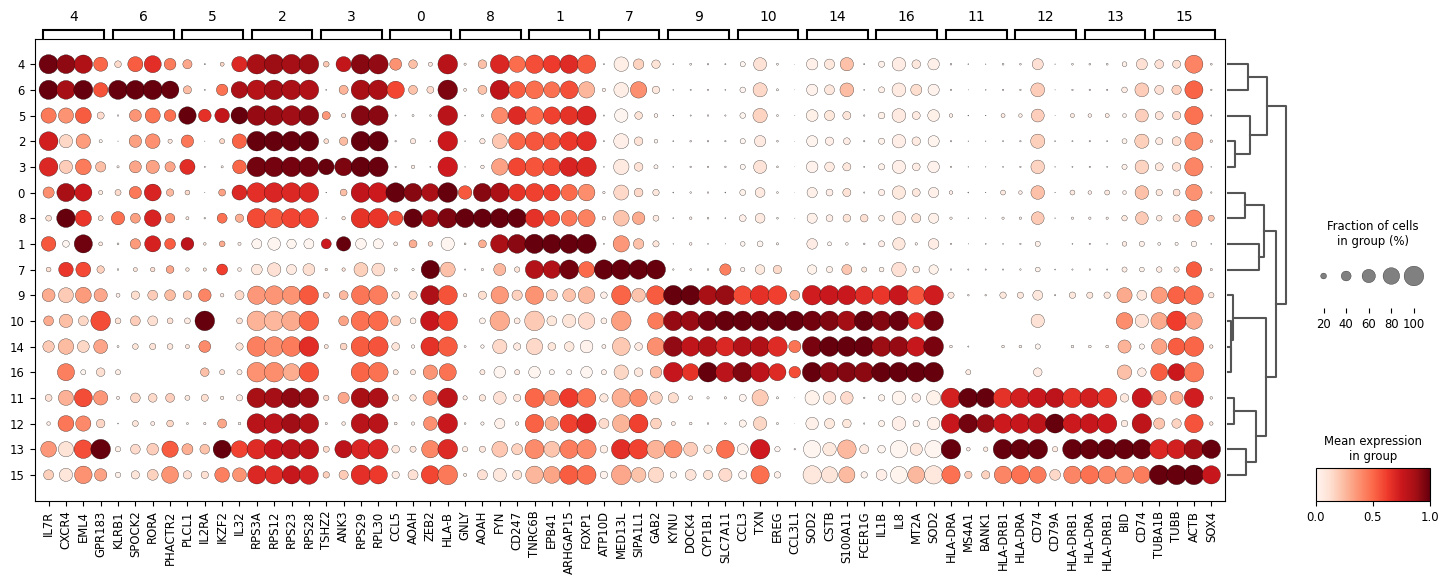

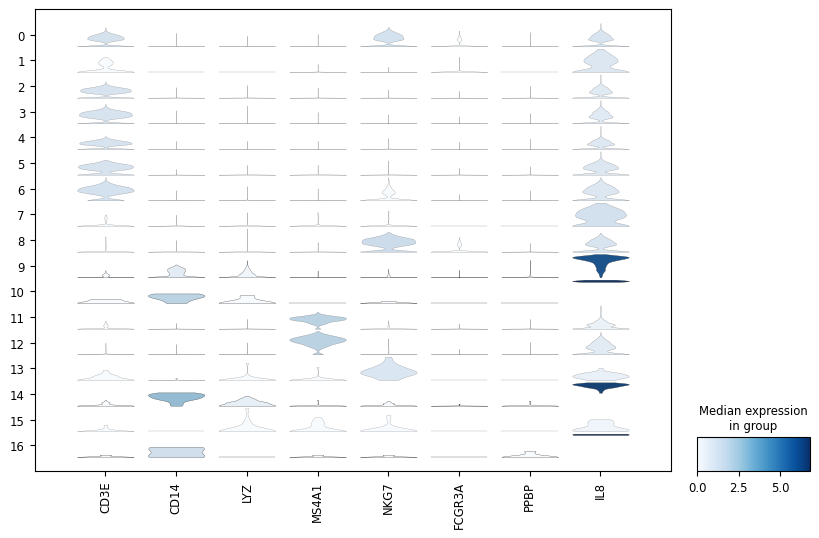

In [41]:
# What the data nominated, as opposed to what we asked about. Complements the curated
# panel above - discovery rather than verification.
sc.pl.rank_genes_groups_dotplot(adata, n_genes=4, key='rank_leiden', groupby='leiden',
                                layer='normlog', standard_scale='var', figsize=(18, 6))

# Per-cell distributions, reading the layer the axis claims. This replaces the reference
# notebook's hand-rolled boxplot, which read layers['counts'] while labelling the axis
# log1p. Distributions matter here because a bimodal cluster suggests a mixed population
# or doublets rather than one cell type.
LINEAGE = [g for g in ['CD3E', 'CD14', 'LYZ', 'MS4A1', 'NKG7', 'FCGR3A', 'PPBP', 'IL8']
           if g in adata.var_names]
sc.pl.stacked_violin(adata, LINEAGE, groupby='leiden', layer='normlog',
                     figsize=(10, 6), dendrogram=False)


### The three questions Section 9 handed to this section

1. **What is cluster 9?** (1,608 cells, enriched 1.45x in 200nm vs 0.53x in
   40nm) — the largest sample-skewed cluster, big enough to carry a Section 13
   test.
2. **What are clusters 13 and 15?** (28, 22 cells) — each shows two-or-more
   lineages at once and 4-6x median depth. Answered by the doublet-score cell
   below, not by argument.
3. **Do the RNA-rich UMAP regions carry coherent markers?** — decides whether
   Section 9's depth-position relationship is biology (monocytes are large,
   busy cells) or artifact.

A doublet cluster expresses markers of **two distinct lineages in the same
cells**; a genuinely activated cell expresses its own lineage markers plus an
activation program — one lineage, one program. That distinction is what the
lineage-score table and Section 2's independent doublet scores are for.

> **A fourth question, the most interesting one.** Cluster 10 — 5 cells —
> carries a coherent NF-κB program (`IL8` 6.75 vs 1.16 elsewhere, `CCL3` 5.45,
> `IL1B` 5.36, `CXCL1/2/3/5`), drawn from 200nm (4 cells) and 40nm (1) only,
> none from control or mixture. Median mito% 1.51 vs the dataset's 3.88 rules
> out dying cells — this is hyperactive, not damaged. At n=5 it can only ever
> be an anecdote, but it's exactly the program predicted for phagocytic
> myeloid cells; Section 16 measures the same program per cell across all
> 1,649 monocytes, where it can actually be quantified.


In [42]:
# Mean expression per cluster of each marker panel, on normlog.
LINEAGE_SETS = {k: v for k, v in present.items()
                if k in ('T (all)', 'B', 'NK', 'Classical mono', 'Non-class mono',
                         'pDC', 'Platelet', 'Neutrophil', 'Inflammatory')}

rows = {}
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    rows[cl] = {name: float(np.asarray(adata[:, genes].layers['normlog'][m].mean()))
                for name, genes in LINEAGE_SETS.items()}
lineage = pd.DataFrame(rows).T
lineage.insert(0, 'cells', adata.obs['leiden'].value_counts().reindex(lineage.index).values)

pd.set_option('display.width', 200)
print('mean normlog expression per marker panel, by cluster')
print('read ACROSS a row: one panel should stand out near 1.0+ while the rest sit near 0\n')
print(lineage.round(2).to_string())

# NO automatic lineage verdict. Three attempts at one were written and all three failed,
# for reasons that are biological rather than fixable by tuning:
#   1. Scoring a panel against its cross-cluster AVERAGE makes abundant lineages invisible -
#      T cells span 8 of 18 clusters, so the T average is high and no T cluster clears it.
#   2. Ratios on near-zero panels are meaningless: the monocyte cluster scored "Neutrophil 11.3x" on
#      an absolute value of 0.01.
#   3. "Two panels elevated" is not a doublet. Classical and Non-classical monocyte are one
#      lineage; and cytotoxic T cells genuinely express the NK panel (NKG7, GNLY), so a
#      T+NK cluster is real biology, not a doublet.
# The dot plot above answers the question directly and is the intended instrument. What is
# printed below is the evidence, ranked - not a verdict.
lineage_only = [k for k in LINEAGE_SETS if k != 'Inflammatory']
infl_mean = lineage['Inflammatory'].mean() if 'Inflammatory' in lineage else None

print('\ntop marker panels per cluster, by ABSOLUTE mean expression\n')
for cl in lineage.index:
    top = lineage.loc[cl, lineage_only].sort_values(ascending=False)
    detail = ', '.join(f'{k} {v:.2f}' for k, v in top.head(3).items())
    line = f'cluster {cl:>2} ({int(lineage.loc[cl, "cells"]):>6,} cells): {detail}'
    if infl_mean is not None:
        line += f'   | inflammatory {lineage.loc[cl, "Inflammatory"]:.2f}'
    print(line)

if infl_mean is not None:
    print(f'\ninflammatory panel: dataset mean across clusters {infl_mean:.2f}; '
          f'highest are '
          + ', '.join(f'cluster {c} ({v:.2f})' for c, v
                      in lineage['Inflammatory'].nlargest(3).items()))

mean normlog expression per marker panel, by cluster
read ACROSS a row: one panel should stand out near 1.0+ while the rest sit near 0

    cells  T (all)    NK     B  Classical mono  Non-class mono   pDC  Platelet  Neutrophil  Inflammatory
0    5237     1.33  1.20  0.02            0.04            0.16  0.01      0.00        0.00          0.40
1     157     0.39  0.07  0.01            0.02            0.02  0.04      0.00        0.00          0.35
2    7033     1.05  0.01  0.01            0.03            0.00  0.04      0.00        0.00          0.46
3    5599     1.00  0.01  0.01            0.02            0.00  0.04      0.00        0.00          0.44
4    3579     1.07  0.09  0.02            0.03            0.00  0.02      0.01        0.00          0.40
5     911     1.03  0.02  0.02            0.03            0.00  0.03      0.01        0.00          0.48
6     891     1.31  0.24  0.01            0.03            0.00  0.01      0.00        0.00          0.43
7     156     0.11  0.05

### Stage two — from cluster numbers to cell type names

The dot plot resolves most clusters. Two questions don't settle by looking
harder:

- **Clusters 2 and 3** — both naive T (`CCR7` 91-93%, `TCF7` 73%), CD4/CD8
  called on `CD8B` presence in one and a near-empty `CD4` column in the other.
  `CD4` mRNA captures poorly in 10x data, so a CD4 T cell is normally called by
  *absence* of CD8 rather than presence of CD4 — an asymmetric read. Section 11
  works through it.
- **Cluster 1** — 157 cells called T by the inherited labels, but nothing
  distinguishes it: `CD3D` only 17%, `CD3E` 31%, no lineage panel stands out.

`standard_scale='var'` rescales every gene 0-1 across clusters, so a faint gene
can still show a dark dot. The check below reads unscaled fractions instead.

A second, independent check: the inherited `predicted.celltype` labels (Section
1). Read as a second opinion, not an answer key — their 8-category vocabulary
splits T cells by *function* (`CD4+ T cell` vs `Cytotoxic T cell`) rather than
lineage, so a naive CD8 T cell (not yet cytotoxic) has nowhere to go but the CD4
box. Where the schemes disagree, it's often about the category list, not the
cells.


In [43]:
# standard_scale='var' rescales each gene to 0-1, which is why a faint gene can show a dark
# dot. These are raw fractions - no scaling, no ranking.
CHECK = ['CD3E', 'CD4', 'IL7R', 'CD8A', 'CD8B', 'CCR7', 'SELL', 'KLRB1', 'SLC4A10',
         'FOXP3', 'IL2RA', 'TRDC', 'TRGC1', 'NKG7', 'FCGR3A', 'MS4A1', 'IGHD', 'CD27']
found = [g for g in CHECK if g in adata.var_names]
print('not in this dataset:', [g for g in CHECK if g not in adata.var_names] or 'none')

df = sc.get.obs_df(adata, keys=found + ['leiden'], layer='normlog')
pct = df.groupby('leiden', observed=True).agg(lambda s: 100 * (s > 0).mean()).round().astype(int)
print()
print('% of cells expressing, per cluster (unscaled)')
print(pct.to_string())

# Independent of our markers entirely: the Azimuth PBMC labels that shipped with the files.
ct = 100 * pd.crosstab(adata.obs['leiden'], adata.obs['predicted.celltype'], normalize='index')
print()
print('inherited Azimuth labels, top 3 per cluster')
for cl in ct.index:
    top = ct.loc[cl].sort_values(ascending=False).head(3)
    print(f'cluster {cl:>2}: ' + ', '.join(f'{k} {v:.0f}%' for k, v in top.items() if v >= 1))

not in this dataset: ['TRDC', 'TRGC1', 'IGHD']

% of cells expressing, per cluster (unscaled)
        CD3E  CD4  IL7R  CD8A  CD8B  CCR7  SELL  KLRB1  SLC4A10  FOXP3  IL2RA  NKG7  FCGR3A  MS4A1  CD27
leiden                                                                                                  
0         68    2    47    56    38     9     3     21        0      0      1    66      22      2     4
1         31   15    68     5     3    46    31      4        0      1      7     1       3      1     6
2         79    4    94    26    53    93    49      1        0      0      1     1       0      1    15
3         79   25    93     2     3    90    61      5        0      1      3     0       0      1    15
4         76   21    97    15    15    55    30     24        3      1      3     4       1      2    11
5         72   23    71     1     2    65    59      3        0     33     56     1       1      2    19
6         81    2    97    49    19    14     2     96       64   

In [44]:
# Clusters 7 and 8 show two or more lineages at once in the panel table and sit at four times
# the dataset's median depth. High depth alone is also what a large, transcriptionally busy
# real cell type looks like, so test it instead of arguing about it: Scrublet's per-cell score
# is already in obs from Section 2, computed before any of this and independent of clustering.
cut = adata.obs['doublet_score'].quantile(0.90)
dbl = adata.obs.groupby('leiden', observed=True).agg(
    cells=('doublet_score', 'size'),
    median_score=('doublet_score', 'median'),
    pct_in_top_decile=('doublet_score', lambda s: 100 * (s > cut).mean()),
    median_counts=('total_counts', 'median'))
dbl['pct_in_top_decile'] = dbl['pct_in_top_decile'].round(0)
print(f'dataset median doublet score {adata.obs["doublet_score"].median():.3f}, '
      f'90th percentile {cut:.3f}')
print('a real doublet cluster sits high on BOTH score columns, not just on depth')
print()
print(dbl.round(3).to_string())

dataset median doublet score 0.072, 90th percentile 0.164
a real doublet cluster sits high on BOTH score columns, not just on depth

        cells  median_score  pct_in_top_decile  median_counts
leiden                                                       
0        5237         0.050                5.0         3805.0
1         157         0.040                1.0         3243.0
2        7033         0.078                8.0         6285.0
3        5599         0.094               15.0         6275.0
4        3579         0.078               13.0         5300.0
5         911         0.071               10.0         5035.0
6         891         0.038                6.0         5349.0
7         156         0.096               12.0         3207.0
8        1608         0.037                4.0         3622.0
9        1608         0.125               23.0        13864.5
10          5         0.139                0.0        10305.0
11       1056         0.051               10.0         9342.5

### Sub-clustering two clusters, for two specific questions

Resolution 0.3 is global and answered most of the dataset well; two questions
need finer granularity, both confined to one cluster each.

**Does cluster 2 hide a naive CD4 population?** It reads `CD8B` 55% vs `CD4` 3%
(CD8-dominant), but a ~12% CD4 minority would still fit those numbers — worth
checking since blood's CD4:CD8 ratio normally runs opposite to what this
dataset's labels show.

**Does cluster 9 split into classical/non-classical monocytes?** Task 3 asks
for that split explicitly; `FCGR3A` sits at only 4% across the whole cluster.

Two caveats on reading the result: the usual 2:1 CD4:CD8 figure is from flow
cytometry (surface protein), while `CD4` mRNA is a noisier proxy; and
`restrict_to` re-clusters **inside one cluster only** — the global partition
everything else depends on is untouched.


In [45]:
# Two questions need finer granularity than resolution 0.3 delivered, and both are local:
# whether cluster 2 (naive T) contains a naive CD4 minority that the CD8 majority absorbed,
# and whether cluster 9 (monocytes) splits into classical and non-classical, which Task 3
# asks for explicitly. restrict_to re-runs Leiden inside one cluster only, so the global
# partition every other section depends on is untouched.
SUBCLUSTER = {
    '2': ['CD4', 'CD8A', 'CD8B', 'MAL', 'LEF1', 'TRABD2A', 'S100B', 'RGS10', 'CCR7'],
    '9': ['CD14', 'LYZ', 'S100A8', 'FCGR3A', 'MS4A7', 'CDKN1C', 'CST3', 'IL8'],
}
SUB_RES = 0.3

for parent, panel in SUBCLUSTER.items():
    key = f'sub_{parent}'
    sc.tl.leiden(adata, restrict_to=('leiden', [parent]), resolution=SUB_RES, key_added=key,
                 flavor='igraph', n_iterations=2, directed=False, random_state=0)
    part = adata[adata.obs['leiden'] == parent].copy()
    genes = [g for g in panel if g in adata.var_names]
    df = sc.get.obs_df(part, keys=genes + [key], layer='normlog')
    pct = df.groupby(key, observed=True).agg(lambda s: 100 * (s > 0).mean()).round(0).astype(int)
    pct.insert(0, 'cells', df.groupby(key, observed=True).size())
    print(f'cluster {parent} -> {len(pct)} sub-clusters at resolution {SUB_RES}')
    print('% of cells expressing')
    print(pct.to_string())
    print()

cluster 2 -> 4 sub-clusters at resolution 0.3
% of cells expressing
       cells  CD4  CD8A  CD8B  MAL  LEF1  TRABD2A  S100B  RGS10  CCR7
sub_2                                                                
2,0     2259    2    33    65   48    96       27      7     81    96
2,1      540   16     4     8   48    91       19      1     73    91
2,2     1425    3    34    61   54    85       24      9     78    94
2,3     2809    3    19    47   39    77       15      5     70    90

cluster 9 -> 12 sub-clusters at resolution 0.3
% of cells expressing
       cells  CD14  LYZ  S100A8  FCGR3A  MS4A7  CDKN1C  CST3  IL8
sub_9                                                            
9,0      397    81   62      70       4     69       6    45  100
9,1       23    61   30      39       0     52       9    35  100
9,2       19   100   74      84       0     68       0    37  100
9,3       14   100   29      64       7     71       0     7  100
9,4      219    63   81      67       2     62

### What the sub-clustering showed — one weak negative, one solid negative

**Cluster 2 splits into four groups, one leaning CD4.** Three read `CD4` 2-3%
vs `CD8B` 47-65% (plainly CD8); the 540-cell group (7.7% of the cluster) reads
`CD4` 16% vs `CD8B` 8% — the opposite ordering, the only place it occurs.
That's a candidate CD4 minority, reported rather than dismissed — but 16% still
sits below cluster 3's 25% CD4, and 540 against 7,033 leaves the cluster
CD8-dominant either way.

**This test is weak for this specific question, and it has to be said either
way:** `CD3E`, `CD8A`, `IL7R` and `FCGR3A` weren't in the 3,000-gene HVG set
(Section 6), so the CD4/CD8 axis contributes almost nothing to the graph Leiden
partitions on. Sub-clustering can only find splits that exist in that graph —
both this negative and the earlier positive read are weak evidence for that
reason. The cluster-level marker fractions carry the actual call, not this
split.

**Cluster 9 does not split into classical/non-classical monocytes, and that
result is solid.** All twelve sub-clusters come back `CD14`+/`S100A8`+/`IL8`
98-100% with `FCGR3A` at 0-4% throughout — over-splitting a gradient, not
finding a population. This negative means more than cluster 2's, because
`CD14`/`FCGR3A` behave very differently in the HVG set (this axis *was*
available to the graph and still found nothing). Task 3's
classical/non-classical split can't be made — the non-classical population is
absent here.


In [46]:
# Task 3 deliverable: the cluster -> cell type map. Sections 12 (composition) and 13 (DE)
# group by this column, so a guess written here stops looking like a guess two sections later.
#
# THESE IDS BELONG TO ONE SPECIFIC CLUSTERING RUN, AND THE RUN IS PLATFORM-DEPENDENT.
# Leiden numbering is not stable across re-runs, so after any change upstream of Section 9 the
# mapping must be RE-DERIVED from the markers, never renumbered. That is not hypothetical
# twice over. First, switching Section 4 to an outer join reordered every cluster, and the
# CD14 sentinel below is what caught it - the cluster the map called NK was holding the
# monocytes. Second, this map was rewritten when the notebook was first run on Linux: the
# recorded Windows run gave 15 clusters at resolution 0.3, Linux gives 17. Sections 1-7
# reproduce EXACTLY across the two platforms (29,157 cells, 21,862 genes, 3,000 HVGs with
# 1,558 in all four batches, 22.8% of variance in 50 PCs). Section 8 does not: scanorama's
# alignment scores differ in the third decimal (0.84311864 Windows vs 0.84420339 Linux)
# because nn_approx builds an AnnoyIndex without calling annoy's set_seed(). It is
# deterministic ON a platform - two Linux processes give bit-identical embeddings - but not
# ACROSS them, and that is enough to move the Leiden partition.
#
# THE BIOLOGY IS UNCHANGED, which is what makes the rewrite a renumbering rather than a new
# result. Every population and its discriminating marker fraction reproduced:
#   Basophil    HDC 56 / CPA3 33 / CLC 30 / GATA2 13   - identical to the recorded values
#   Treg        FOXP3 33                                - identical
#   MAIT        SLC4A10 64                              - identical
#   B memory    CD27 42                                 - identical
#   CD8 T naive CD4 4 vs CD8B 53                        - recorded 2.9 vs 54.8
# and the population sizes track: Monocyte 1,649 here against 1,659 recorded, NK 1,608 vs
# 1,630, B memory 1,056 vs 1,047, B naive 1,220 vs 1,230, Basophil 156 vs 154.
#
# Clusters 13 and 15 are Doublet on the evidence of the cell above, not on their size:
# Scrublet score 2.09x and 2.32x the dataset median, 36% and 50% of their cells in the top
# score decile, and median depth 4.33x and 5.73x the dataset. Both show two or more lineages
# in the same cells. Cluster 9 is the control that keeps this honest - it is 1.75x on score
# and 2.50x on depth and is NOT a doublet, it is the monocytes; only the top-decile share
# (23%) separates them, which is why this call is made at cluster level and not per cell.
#
# Clusters 10 (5 cells) and 16 (6 cells) are CD14-high myeloid but too small to name, and are
# deliberately NOT folded into Monocyte. Adding 11 unvetted cells to the population that
# carries this project's headline composition result is a bad trade for no gain; they go to
# Exclude. Cluster 14 (41 cells) IS Monocyte - CD14 95%, a single clean lineage, and only 17%
# in the top doublet decile - and plays the role the recorded run's 90-cell second monocyte
# group played.
CELL_TYPES = {
    '0':  'CD8 T effector',       # CD3+ CD8A 56, GZMB 54 / GNLY 62 / NKG7 66, CCR7 only 9
    '1':  'T unresolved',         # CD3 low (17/31), no lineage marker with a real gap
    '2':  'CD8 T naive',          # CD8B 53 vs CD4 4; CCR7 93, IL7R 94, TCF7 73
    '3':  'CD4 T naive',          # CD4 25 vs CD8B 3; CCR7 90, IL7R 93
    '4':  'CD4 T memory',         # CD4 21 vs CD8B 15, CCR7 55 - naive compartment left
    '5':  'Treg',                 # FOXP3 33, IL2RA 56, CTLA4 18
    '6':  'MAIT',                 # SLC4A10 64, KLRB1 96, GZMK 54
    '7':  'Basophil',             # HDC 56, CPA3 33, CLC 30, GATA2 13; CD1C 0, LILRA4 0
    '8':  'NK',                   # GNLY 94, NKG7 75, KLRD1 64 with CD3D 5 - CD3-negative
    '9':  'Monocyte',             # CD14 59, LYZ 51, S100A9 66, MS4A7 55, FCGR3A only 4
    '10': 'Myeloid unresolved',   # 5 cells, CD14 80 - myeloid but unnameable at this n
    '11': 'B memory',             # MS4A1 98, CD79A 97, CD27 42, TCL1A 6
    '12': 'B naive',              # MS4A1 95, CD79A 96, TCL1A 73, CD27 3
    '13': 'Doublet',              # score 2.09x, 36% top decile, depth 4.33x, mixed lineages
    '14': 'Monocyte',             # CD14 95, S100A9 100, MS4A7 61 - clean single lineage
    '15': 'Doublet',              # score 2.32x, 50% top decile, depth 5.73x, mixed lineages
    '16': 'Myeloid unresolved',   # 6 cells, CD14 67 - same call as cluster 10
}
assert set(CELL_TYPES) == set(adata.obs['leiden'].cat.categories), 'cluster labels do not match'
adata.obs['cell_type'] = adata.obs['leiden'].map(CELL_TYPES).astype('category')

# The assert above only catches a changed cluster COUNT. This catches the worse case, where
# the count matches but the IDs have moved: CD14 must be most widely expressed in the
# population we called Monocyte. Restricted to types big enough for the fraction to be
# stable - a 5-cell cluster can hit 100% on noise.
cd14 = sc.get.obs_df(adata, keys=['CD14', 'cell_type'], layer='normlog')
frac = cd14.groupby('cell_type', observed=True)['CD14'].agg(['size', lambda s: (s > 0).mean()])
frac.columns = ['cells', 'pct_cd14']
big = frac[frac.cells >= 200]
assert not big.empty, 'no cell type has 200+ cells - the sentinel cannot run'
assert big.pct_cd14.idxmax() == 'Monocyte',     f'labels look misaligned: CD14 is highest in {big.pct_cd14.idxmax()}, not Monocyte'

# A second, coarser label for Section 13. Pseudobulk sums each cell type's counts into one
# column per sample, so every group needs enough cells in EVERY sample - and control, the
# smallest, is always the binding constraint. The rule applied here: merge only where a group
# cannot support a test alone, or where no mechanism would make the split respond differently.
# Resolution is protected where CLAUDE.md expects the effect and spent where it does not.
#
#   Monocyte stays alone            - CLAUDE.md expects the response in phagocytic myeloid
#                                     cells; 228 control cells is enough to test.
#   Basophil stays alone            - a granulocyte, not a phagocyte; merging it into
#                                     Monocyte would put a different lineage into the myeloid
#                                     pseudobulk. It fails the size check below and is
#                                     excluded from DE, but stays intact for Task 4.
#   CD4 / CD8 / B subsets merge     - no expected effect there, and each merge is one fewer
#                                     test on a single-donor dataset where every test is
#                                     already exploratory.
#   CD8 T naive is its own group    - cluster 2 is naive CD8 T (evidence in Section 11).
#                                     Same lineage as CD8 effector but a very different
#                                     activation state, and the rule is to merge only where no
#                                     mechanism would make the split respond differently.
#                                     Both clear the size check alone (control n = 1,139 and
#                                     1,152), so both stay.
#   Treg and MAIT stay alone        - distinct lineages/functions, and both clear the check.
#   Artifacts and unnamed -> Exclude - so they are dropped rather than silently summed into a
#                                     real cell type, which is what happens by default.
COARSE = {
    'CD8 T naive':              'CD8 T naive',
    'CD4 T naive':                 'CD4 T',
    'CD4 T memory':                'CD4 T',
    'Treg':                        'Treg',
    'CD8 T effector':              'CD8 T',
    'MAIT':                        'MAIT',
    'NK':                          'NK',
    'B naive':                     'B',
    'B memory':                    'B',
    'Monocyte':                    'Monocyte',
    'Basophil':                    'Basophil',
    'Doublet':                     'Exclude',
    'T unresolved':                'Exclude',
    'Myeloid unresolved':          'Exclude',
}
missing = set(adata.obs['cell_type'].cat.categories) - set(COARSE)
assert not missing, f'COARSE does not cover: {missing}'
adata.obs['cell_type_coarse'] = adata.obs['cell_type'].map(COARSE).astype('category')

# NOTE: which coarse groups can carry a Section 13 test is decided at the END of Section 11,
# not here. Cluster 3 is relabelled per cell there, which moves ~2,800 cells between CD4 T and
# CD8 T - a readiness table computed now would describe labels that are about to change.

print(adata.obs.groupby(['cell_type', 'Sample'], observed=True).size().unstack(fill_value=0))
print()
n_dbl = (adata.obs['cell_type'] == 'Doublet').sum()
print(f'doublets identified at cluster level: {n_dbl:,} cells '
      f'({n_dbl / adata.n_obs:.1%}) - to be excluded in Sections 12-13')

Sample              40nm  200nm  control  mixture
cell_type                                        
B memory             182    332      257      285
B naive              250    461      227      282
Basophil              43     62       15       36
CD4 T memory         938   1322      648      671
CD4 T naive         1414   2049     1222      914
CD8 T effector      1250   1888     1081     1018
CD8 T naive         2154   2527     1246     1106
Doublet               10     28        5        7
MAIT                 197    362      161      171
Monocyte             221    900      279      249
Myeloid unresolved     1      9        0        1
NK                   403    545      342      318
T unresolved          52     46       17       42
Treg                 260    345      152      154

doublets identified at cluster level: 50 cells (0.2%) - to be excluded in Sections 12-13


### Why each cluster got its name

One line per cluster. The rule throughout: a cell type is called by a gene that this type
makes and other types do not. Percentages are the fraction of cells in the cluster carrying
the gene, read from the unscaled panel above and the per-gene tables in this section.

| # | cells | name | why |
|---|---|---|---|
| 0 | 5,237 | CD8 T effector | `CD3E` 68% with `CD8A` 56% / `CD8B` 38%, killing granules `NKG7` 66% / `GNLY` 62% / `GZMB` 54%, and `CCR7` down to 9%. A killer T cell. |
| 1 | 157 | **T unresolved** | `CD3E` 31% and nothing else — no lineage panel stands out and no subset marker was nominated. Its doublet score is *ordinary* (0.55x the dataset median), so it is unnamed rather than artifact. |
| 2 | 7,033 | **CD8 T naive** | `CCR7` 93%, `IL7R` 94% and `TCF7` 73% make it naive; `CD8B` 53% against `CD4` 4% makes it CD8. A **cluster-level** call — see Section 11 for the evidence and its limits. |
| 3 | 5,599 | CD4 T naive | The mirror of cluster 2: `CD4` 25%, both CD8 genes at 2-3%, `CCR7` 90%, `TCF7` 72%. |
| 4 | 3,579 | CD4 T memory | `CD4` 21%, `IL7R` 97%, `GZMK` 20%, and `CCR7` down to 55% from ~90% in the naive clusters. |
| 5 | 911 | Treg | `FOXP3` 33% against 0-1% everywhere else, with `IL2RA` 56% and `CTLA4` 18%. Only regulatory T cells make `FOXP3`. |
| 6 | 891 | MAIT | `SLC4A10` 64% against 0-3% elsewhere, `KLRB1` 96%, `GZMK` 54%. `SLC4A10` is essentially MAIT-only. |
| 7 | 156 | **Basophil** | `HDC` 56%, `CPA3` 33%, `CLC` 30%, `GATA2` 13% — the basophil program. `CD1C` 0% rules out cDC2 and `LILRA4` 0% rules out pDC. |
| 8 | 1,608 | NK | `GNLY` 94%, `NKG7` 75%, `KLRD1` 64% — with the T cell gene `CD3E` at **6%**. Not a T cell. |
| 9 | 1,608 | **Monocyte** | `CD14` 59%, `LYZ` 51%, `S100A9` 66%, `MS4A7` 55%, `IL8` 100%. `FCGR3A` 4% — the classical population. |
| 10 | 5 | Myeloid unresolved | `CD14` 80% and a coherent NF-kB program (`IL8`, `CCL3`, `IL1B`), from 200nm and 40nm only. Myeloid, but unnameable at n=5 — see the note in Section 9. |
| 11 | 1,056 | B memory | `MS4A1` 98% and `CD79A` 97% plus `CD27` 42% — the memory B marker — with `TCL1A` at 6%. |
| 12 | 1,220 | B naive | The same B genes (`MS4A1` 95%) but `CD27` at **3%** and `TCL1A` **73%**. B cells that have not been activated. |
| 13 | 28 | **Doublet** | Several lineages at once: `CD4` 46%, `NKG7` 89%, `GZMB` 71%, `CD79A` 18%, `MS4A7` 32%. Doublet score **2.09x** the dataset median, **36%** of cells in the top decile, median depth 23,992 against 5,541. |
| 14 | 41 | Monocyte | Same identity as cluster 9, more strongly expressed: `CD14` 95%, `S100A9` 100%, `MS4A7` 61%. A single clean lineage and only 17% in the top doublet decile. |
| 15 | 22 | **Doublet** | B genes (`CD79A` 45%, `MS4A1` 27%) with basophil genes (`GATA2` 36%, `HDC` 23%), `NKG7` 50% and `CD14` 27%. Score **2.32x**, **50%** in the top decile, depth 31,739. The clearest case. |
| 16 | 6 | Myeloid unresolved | `CD14` 67%, `S100A9` 83%, `IL8` 100%. The same call as cluster 10, for the same reason. |

### Doublets, and what is actually unresolved

Clusters 13 and 15 — **50 cells, 0.2%** — are doublets. They sit high on **both** diagnostic
axes: doublet score around twice the dataset median with a third to a half of their cells in
the top score decile, *and* four to six times the median sequencing depth. Depth alone would
not be enough, and cluster 9 is the control that proves it: the monocytes have a median of
13,864 counts — 2.5x the dataset's 5,541 — but only **23%** of their cells in the top score
decile, because large busy cells are deep without being doublets.

Section 2 removed 2,239 doublets at a deliberate 50% sensitivity, so roughly half were always
going to survive to here; Scrublet also cannot see two cells of the *same* type in one
droplet. Identifying the remainder as clusters removes them precisely, which is why
cluster-level doublet calls are standard: doublets share a mixed profile and therefore cluster
together, whereas a per-cell threshold has to cut through two overlapping distributions.

**What is genuinely unresolved is 168 cells, 0.6%** — cluster 1 (157 cells, no lineage) plus
clusters 10 and 16 (11 cells, myeloid but too few to name). None has an elevated doublet
score. They are unnamed because no marker distinguishes them, not because they are artifacts.
The 11 myeloid cells are deliberately **not** folded into `Monocyte`: adding unvetted cells to
the population carrying this project's headline composition result is a bad trade for no gain.

**Not present in this dataset:** platelets (`PPBP` appears mainly inside the monocyte clusters,
the usual carry-over), neutrophils, plasma cells, proliferating cells (confirmed independently
in Section 16 — `MKI67` reaches 5+ counts in **9 cells**), **and dendritic cells of either
kind** — `CD1C` reaches 0-5% in every cluster and `LILRA4` never exceeds 6%. Empty marker
columns are informative and, apart from the DCs, normal for PBMCs.

**The dendritic-cell error is worth keeping visible.** Cluster 7 was first called
`Dendritic cell` on `FCER1A` plus a pDC panel score that looked like evidence. That panel
averages `LILRA4`, `CLEC4C` and `IL3RA` — and the score came almost entirely from `IL3RA`,
with `LILRA4` at **0%**. `IL3RA` is CD123, carried by basophils as well as pDCs. **A panel mean
can be driven by one gene, and averaging hides which one.** The per-gene table is what caught
it, and CellTypist independently prompted the check.

### Checking against the two labellings that came with the data

The files arrived with two automatic labellings already attached: **Azimuth**
(reference-based label transfer, in `predicted.celltype`) and **CoDi** (the
`*_CoDi_KLD.csv` files). Neither is ground truth — nobody sorted these cells
with antibodies; both are automatic interpretations of the same expression data
we're reading ourselves. So the useful question isn't "do we match them" but
**where do the three disagree, and which reading do the genes support.**

The first test is against neither of us: **do the two external methods agree
with each other?** If two independent labellings of the same cells disagree,
neither is a correct answer to defer to. The second test is composition
plausibility — published PBMC composition runs roughly 25-35% CD4 T, 15-25%
CD8 T, 5-15% NK, 5-15% B, 10-30% monocyte; a method far from that isn't a
reference either, whatever it says about any one cluster.


In [47]:
# A third opinion, and a check of the two external ones against each other. CoDi shipped
# with the data as per-cell CSVs; Section 1 kept the Azimuth labels in obs. Barcodes were
# prefixed per sample in Section 1, so rebuild the same key here.
codi = pd.concat([
    pd.read_csv(DATA_DIR / f"{fn.replace('.h5ad', '')}_CoDi_KLD.csv").assign(Sample=label)
    for label, fn in SAMPLES.items()
])
codi.index = codi['Sample'] + '_' + codi['cell_id']
adata.obs['CoDi'] = codi['CoDi'].reindex(adata.obs_names).values
print(f"CoDi labels matched: {adata.obs['CoDi'].notna().sum():,} of {adata.n_obs:,} cells")

# What each method says the dataset is made of. Published PBMC composition is roughly
# 25-35% CD4 T, 15-25% CD8 T, 5-15% NK, 5-15% B, 10-30% monocyte - a useful sanity check,
# since a method that returns implausible proportions is not a reference to defer to.
share = pd.concat([
    adata.obs['predicted.celltype'].value_counts(normalize=True).rename('Azimuth'),
    adata.obs['CoDi'].value_counts(normalize=True).rename('CoDi'),
    adata.obs['cell_type'].value_counts(normalize=True).rename('ours'),
], axis=1).mul(100).round(1)
print('\n% of all cells, by method (NaN = that method has no such label)')
print(share.to_string())

# Do the two external methods agree with EACH OTHER? If not, neither is ground truth.
both = adata.obs[['predicted.celltype', 'CoDi']].dropna()
print(f"\nAzimuth vs CoDi agree on {100 * (both['predicted.celltype'] == both['CoDi']).mean():.1f}%"
      f" of {len(both):,} cells")
print(pd.crosstab(both['predicted.celltype'], both['CoDi']).to_string())

print('\nper cluster - our call, then what each external method calls the same cells')
for cl in adata.obs['leiden'].cat.categories:
    m = adata.obs['leiden'] == cl
    az = adata.obs.loc[m, 'predicted.celltype'].value_counts(normalize=True)
    cd = adata.obs.loc[m, 'CoDi'].value_counts(normalize=True)
    print(f'cluster {cl:>2} ({m.sum():>6,})  {CELL_TYPES[cl]:<22}'
          f'Azimuth: {az.index[0]} {100 * az.iloc[0]:.0f}%   '
          f'CoDi: {cd.index[0]} {100 * cd.iloc[0]:.0f}%')

CoDi labels matched: 29,157 of 29,157 cells

% of all cells, by method (NaN = that method has no such label)
                             Azimuth  CoDi  ours
CD4+ T cell                     65.3  66.8   NaN
Cytotoxic T cell                21.9  19.6   NaN
B cell                           7.3   7.6   NaN
CD14+ monocyte                   5.5   5.0   NaN
Natural killer cell              0.0   0.7   NaN
Dendritic cell                   0.0   0.1   NaN
Megakaryocyte                    0.0   NaN   NaN
Plasmacytoid dendritic cell      0.0   0.0   NaN
CD16+ monocyte                   NaN   0.1   NaN
CD8 T naive                      NaN   NaN  24.1
CD4 T naive                      NaN   NaN  19.2
CD8 T effector                   NaN   NaN  18.0
CD4 T memory                     NaN   NaN  12.3
Monocyte                         NaN   NaN   5.7
NK                               NaN   NaN   5.5
B naive                          NaN   NaN   4.2
B memory                         NaN   NaN   3.6
Treg     

---

## Section 11 — Automated annotation, run by us

**Task 3** (cell type annotation) — the reference-based half, done in Python

Section 10 named clusters from marker genes we chose; this section asks a trained
model the same question, so the annotation rests on two methods that fail
differently rather than one. Azimuth is the reference-based method for this task,
but it's R/Seurat-native, so the Python equivalents are used here, with the
inherited labels already in `obs` serving as a third opinion.

**CellTypist first**, because it answers something Section 10 couldn't:
`Immune_All_Low` is a per-cell logistic-regression model over the full gene set
(98 immune subtypes), so unlike Leiden — built from 3,000 HVGs that exclude
`CD3E`/`CD8A`/`IL7R`/`FCGR3A` (Section 6) — it reads `CD4`/`CD8A/B` directly and
gives an independent read on the question sub-clustering could only weakly test.
`majority_voting=True, over_clustering='leiden'` also returns one label per our
cluster, for the like-for-like comparison against Section 10. Both columns are
kept: `celltypist` (per cell) and `celltypist_cluster` (majority vote).

The model ships current HGNC symbols; this dataset uses pre-2017 ones — every
unmatched gene silently counts as zero, degrading predictions with no warning. So
feature overlap is measured and printed before any label is trusted, and `.X` is
asserted still `normlog` (CellTypist requires exactly the CP10K+log1p Section 5
was chosen to produce).


In [48]:
import celltypist
from celltypist import models

# Immune_All_Low: 98 immune subtypes. The High model has 32 and stops around "T cell", which
# cannot address the open CD4/CD8 question; Low names naive CD4 and naive CD8 separately.
MODEL = 'Immune_All_Low.pkl'
models.download_models(model=[MODEL])            # cached after the first run
model = models.Model.load(model=MODEL)

# CellTypist requires log1p of counts normalized to 1e4 - the reason Section 5 fixed
# target_sum=1e4 rather than taking scanpy's default of the median library size.
assert np.array_equal(adata.X.data, adata.layers['normlog'].data), '.X is not normlog'

# The legacy-symbol problem, made visible BEFORE any label is trusted: CellTypist ships
# current HGNC symbols and this dataset uses pre-2017 ones. A poor overlap degrades every
# prediction silently, so it is measured rather than assumed.
matched = set(model.features) & set(adata.var_names)
print(f'model features matched: {len(matched):,} of {len(model.features):,} '
      f'({len(matched) / len(model.features):.1%})')
print('genes this section depends on:')
for g in ['CD4', 'CD8A', 'CD8B', 'CCR7', 'SELL', 'S100B', 'MAL', 'IL8', 'CXCL8']:
    print(f'  {g:<8}{"model" if g in model.features else "-":<8}'
          f'{"data" if g in adata.var_names else "-"}')

pred = celltypist.annotate(adata, model=MODEL, majority_voting=True, over_clustering='leiden')
adata.obs['celltypist'] = pred.predicted_labels['predicted_labels'].astype('category')
adata.obs['celltypist_cluster'] = pred.predicted_labels['majority_voting'].astype('category')
print()
print(f"per-cell labels used: {adata.obs['celltypist'].nunique()}   "
      f"after majority voting over our leiden clusters: "
      f"{adata.obs['celltypist_cluster'].nunique()}")

/mnt/e86bf702-37c5-47c8-8d7c-6e4a2e4a4046/GI/.venv/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv
📂 Storing models in /home/aleksa/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 29157 cells and 21862 genes
🔗 Matching reference genes in the model


model features matched: 4,883 of 6,639 (73.6%)
genes this section depends on:
  CD4     model   data
  CD8A    model   data
  CD8B    model   data
  CCR7    model   data
  SELL    model   data
  S100B   model   data
  MAL     model   data
  IL8     -       data
  CXCL8   model   -


🧬 4883 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!



per-cell labels used: 75   after majority voting over our leiden clusters: 14


In [49]:
# Per cluster: our label, CellTypist's majority-vote label, and its top per-cell labels.
# The per-cell column is the one that can disagree WITHIN a cluster.
print('cluster (cells)   ours / CellTypist majority / CellTypist per-cell')
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    share = adata.obs.loc[m, 'celltypist'].value_counts(normalize=True)
    top = ', '.join(f'{k} {100 * v:.0f}%' for k, v in share.head(2).items() if v >= 0.05)
    print(f'{cl:>3} ({m.sum():>6,})  {CELL_TYPES[cl]:<28}'
          f'{str(adata.obs.loc[m, "celltypist_cluster"].iloc[0]):<30}{top}')

# The question Section 10 could not answer. Leiden partitions a graph built from HVGs, and
# CD4/CD8A are not HVGs, so sub-clustering cluster 2 could not test whether it holds naive
# CD4 cells. CellTypist is a per-cell logistic model over the full gene set and does not use
# our graph at all, so its within-cluster spread is an independent answer.
for cl in ['2', '3']:
    m = (adata.obs['leiden'] == cl).to_numpy()
    print()
    print(f'cluster {cl} ({m.sum():,} cells) - CellTypist per-cell labels')
    counts = adata.obs.loc[m, 'celltypist'].value_counts().head(6)
    for k, v in counts.items():
        print(f'  {k:<40}{v:>6,}  {100 * v / m.sum():>5.1f}%')

cluster (cells)   ours / CellTypist majority / CellTypist per-cell
  0 ( 5,237)  CD8 T effector              Tem/Temra cytotoxic T cells   Tem/Temra cytotoxic T cells 61%, Tem/Trm cytotoxic T cells 26%
  1 (   157)  T unresolved                Tcm/Naive helper T cells      Tcm/Naive helper T cells 62%, Regulatory T cells 6%
  2 ( 7,033)  CD8 T naive                 Tcm/Naive cytotoxic T cells   Tcm/Naive cytotoxic T cells 64%, Tcm/Naive helper T cells 34%
  3 ( 5,599)  CD4 T naive                 Tcm/Naive helper T cells      Tcm/Naive helper T cells 90%
  4 ( 3,579)  CD4 T memory                Tem/Effector helper T cells   Tem/Effector helper T cells 22%, Tcm/Naive helper T cells 22%
  5 (   911)  Treg                        Regulatory T cells            Regulatory T cells 61%, Treg(diff) 17%
  6 (   891)  MAIT                        MAIT cells                    MAIT cells 65%, Type 17 helper T cells 25%
  7 (   156)  Basophil                    Mast cells                    Mast ce

### What CellTypist changed, and what it did not

Confirmed the marker annotation on every settled cluster, and named two subtypes
the panels alone couldn't: `Regulatory T cells` for cluster 5 (60% per cell) and
`MAIT cells` for cluster 6 (65%) — both folded into `CD4+ T cell` by the
inherited labels. It also found the basophils (below).

**On cluster 2 it disagrees with Pan-Human Azimuth, and that disagreement is this
section's main result.** Per cell, CellTypist reads 67% cytotoxic-lineage vs 31%
helper-lineage; Azimuth reads the same cells 87.5% Naive CD4 T. The two agree on
which *individual* cells are CD4 only 42.1% of the time — below the ~50% chance
line — so **no per-cell reassignment is made.** The cluster-level call and its
evidence are in the pseudobulk cell below.

> An earlier version of this notebook did reassign those cells individually on
> CellTypist's say-so. It was reverted when the cross-model test failed — and the
> reverting criterion was stated *before* the test ran, which is the only reason
> this isn't a judgment made after seeing the answer.

**Cluster 7 needed checking, not accepting.** Called `Dendritic cell` on
`FCER1A` plus a pDC panel; CellTypist says mast cells. `FCER1A` (the IgE
receptor) sits on basophils and mast cells too, so it can't separate them alone
— the panels below can, and they say basophil.

**Two disagreements that aren't really disagreements:** CellTypist calls
clusters 9/14 `Macrophages` (its model spans tissues; blood carries monocytes,
not macrophages — vocabulary, not biology), and clusters 13/15 get no coherent
answer (`pDC`/`Age-associated B cells`) — exactly what a doublet looks like to a
classifier forced to pick one label.

**The symbol problem is visible in the output:** `IL8` is in our data and
absent from the model; `CXCL8` is in the model and absent from our data — the
same gene, two names. Overlap is 73.6% (4,883/6,639), usable, but ~1,750
unmatched features were silently zeroed. Sections 14 and 16 inherit this same
failure mode, where it bites harder since MSigDB gene sets are smaller than a
model's feature list.


In [50]:
# Cluster 2 is labelled CD8 T naive. It read 'T naive (CD4/CD8 unresolved)' until the marker
# evidence was weighed against the two automated models rather than averaged with them.
#
# THE GENES. CD4 is detected in 2.9% of the cluster against 22-24% in every population we call
# CD4, while CD8B is in 54.8% against 1.8-3.9% there - higher even than the 38.0% in the CD8
# effector cluster, which is what naive CD8 cells look like. CD4 captures poorly in 10x (24%
# even where we are confident), so its ABSENCE is weak evidence; CD8B's PRESENCE is not.
#
# THE MODELS DISAGREED, AND NOT SYMMETRICALLY. CellTypist called the cluster 67% Tcm/Naive
# CYTOTOXIC T; Pan-Human Azimuth called it 87.5% Naive CD4 T. On every cluster where the genes
# give an independent answer - MAIT, Treg, Basophil, NK - CellTypist is right and panhumanpy is
# weaker or wrong: it calls our CD4 MEMORY cluster 'Naive CD4 T' at 70%, and returns False on
# MAIT and Basophil. Its errors run consistently toward CD4, the same direction as the
# inherited labels - a shared prior, not a second independent measurement.
#
# WHAT IS STILL NOT KNOWN. The two models agree on which INDIVIDUAL cells are CD4 only 42.1% of
# the time, below the ~50% chance line, because 48% of these cells express neither CD4 nor
# CD8A/CD8B. For half the cluster there is no information. The claim is therefore CLUSTER-LEVEL
# only: aggregation recovers a fraction that no single cell carries. Per-cell CD4/CD8
# assignment is not recoverable from this data and is not attempted.
#
# CONSEQUENCE FOR THE REPORT: this flips the dataset's CD4:CD8 ratio relative to both inherited
# labellings, which call the cluster 100% CD4+ T. Report the ratio as a consequence of this
# call, not as an independent finding.

# MIN_PSEUDOBULK is a rule of
# thumb, not a derived number: below roughly 50 cells a pseudobulk column is dominated by
# which cells happened to be captured rather than by the sample's biology. Stated here so
# Section 13 inherits an explicit list rather than discovering the problem as a failed fit.
MIN_PSEUDOBULK = 50
counts = (adata.obs[adata.obs['cell_type_coarse'] != 'Exclude']
          .groupby(['cell_type_coarse', 'Sample'], observed=True).size().unstack(fill_value=0))
counts['min'] = counts.min(axis=1)
counts['DE-ready'] = counts['min'] >= MIN_PSEUDOBULK
print()
print(f'coarse groups for Section 13 (min {MIN_PSEUDOBULK} cells in every sample)')
print(counts.to_string())
DE_GROUPS = list(counts.index[counts['DE-ready']])
print()
print(f'testable in Section 13: {DE_GROUPS}')
print(f'kept for Task 4 composition but not DE: '
      f'{[g for g in counts.index if g not in DE_GROUPS]}')


coarse groups for Section 13 (min 50 cells in every sample)
Sample            40nm  200nm  control  mixture   min  DE-ready
cell_type_coarse                                               
B                  432    793      484      567   432      True
Basophil            43     62       15       36    15     False
CD4 T             2352   3371     1870     1585  1585      True
CD8 T             1250   1888     1081     1018  1018      True
CD8 T naive       2154   2527     1246     1106  1106      True
MAIT               197    362      161      171   161      True
Monocyte           221    900      279      249   221      True
NK                 403    545      342      318   318      True
Treg               260    345      152      154   152      True

testable in Section 13: ['B', 'CD4 T', 'CD8 T', 'CD8 T naive', 'MAIT', 'Monocyte', 'NK', 'Treg']
kept for Task 4 composition but not DE: ['Basophil']


In [51]:
# The basophil cluster (7 in this run) was called Dendritic cell on FCER1A plus the pDC panel. CellTypist says mast
# cells. FCER1A is the IgE receptor and is carried by basophils and mast cells as well as
# cDC2, so it cannot separate them on its own - these panels can.
PANELS = {
    'basophil/mast': ['CLC', 'CPA3', 'MS4A2', 'GATA2', 'HDC'],
    'cDC2':          ['CD1C', 'CLEC10A', 'FCER1A'],
    'pDC':           ['LILRA4', 'CLEC4C', 'IL3RA', 'GZMB'],
}
present = {k: [g for g in v if g in adata.var_names] for k, v in PANELS.items()}
absent = [g for k, v in PANELS.items() for g in v if g not in adata.var_names]
print('not in this dataset:', absent or 'none')

genes = [g for v in present.values() for g in v]
df = sc.get.obs_df(adata, keys=genes + ['leiden'], layer='normlog')
pct = df.groupby('leiden', observed=True).agg(lambda s: 100 * (s > 0).mean()).round(0).astype(int)
pct.insert(0, 'cells', adata.obs['leiden'].value_counts().reindex(pct.index).values)
print()
print('% of cells expressing   |  ' + '  '.join(f'{k}: {v}' for k, v in present.items()))
print(pct.to_string())

not in this dataset: ['MS4A2', 'CLEC10A']

% of cells expressing   |  basophil/mast: ['CLC', 'CPA3', 'GATA2', 'HDC']  cDC2: ['CD1C', 'FCER1A']  pDC: ['LILRA4', 'CLEC4C', 'IL3RA', 'GZMB']
        cells  CLC  CPA3  GATA2  HDC  CD1C  FCER1A  LILRA4  CLEC4C  IL3RA  GZMB
leiden                                                                         
0        5237    0     0      0    0     0       0       0       0      3    54
1         157    0     0      0    0     0       0       0       0     10     1
2        7033    0     0      0    0     0       0       0       0     11     0
3        5599    0     0      0    0     0       0       0       0     12     0
4        3579    0     0      0    0     0       0       0       0      5     1
5         911    0     0      0    0     0       0       0       0      8     1
6         891    0     0      0    0     0       0       0       0      3     6
7         156   30    33     13   56     0      21       0       4     71     0
8        1608

### Still Section 11 — Pan-Human Azimuth, the second model

Azimuth is the named reference-based method for Task 3; `panhumanpy` is the
same reference family exposed in Python, meeting that requirement without
leaving the pipeline's language. It's pan-tissue rather than immune-specific,
so its immune vocabulary is coarser (no `Tcm/Naive cytotoxic T cells`) and it
carries categories for tissues that can't be present in blood — both
properties of the reference, not errors, and exactly why running it alongside
CellTypist is useful: CellTypist is sharp on immune subtypes, a pan-tissue
model is the one that would flag something not being an immune cell at all.

It's a neural network over ~29,000 cells and downloads its weights on first use
— the slowest cell in the notebook. Column names vary by model version, so
they're discovered and printed before anything is read, then copied across with
a `ph_` prefix so nothing already in `obs` is overwritten.


In [52]:
import panhumanpy as ph

# Pan-Human Azimuth. CLAUDE.md names Azimuth for Task 3; Azimuth proper is R/Seurat, so this
# is the same reference family run from Python. It is pan-tissue rather than immune-specific,
# so expect coarser immune subtypes than CellTypist returned - that difference is the reason
# for running both rather than picking one.
#
# Downloads model weights on first use. It checks the normalization of .X itself rather than
# assuming, which is why nothing is passed for normalization_override.
az = ph.AzimuthNN(adata)
az_adata = az.pack_adata()

# Column names are not documented per version, so they are discovered rather than assumed.
new = [c for c in az_adata.obs.columns if c not in adata.obs.columns]
print(f'\ncolumns returned by panhumanpy: {len(new)}')
for c in new:
    col = az_adata.obs[c]
    if col.dtype.name in ('object', 'category'):
        print(f'  {c:<34}{col.nunique():>5} distinct   e.g. {list(col.astype(str).unique()[:3])}')
    else:
        print(f'  {c:<34}numeric   {col.min():.3f} - {col.max():.3f}')

# Carry the label columns across with a prefix, leaving adata's own columns untouched.
for c in new:
    if az_adata.obs[c].dtype.name in ('object', 'category'):
        adata.obs[f'ph_{c}'] = az_adata.obs[c].values
print('\ncopied into adata.obs:', [c for c in adata.obs.columns if c.startswith('ph_')])

Integer counts detected by panhumanpy.ANNotate : False
Log-normalization performed by panhumanpy.ANNotate: False
Query object:
    Total number of cells: 29157
    Total number of features: 21862
    Overlap w. feature reference: 3996 (~79%)

Splitting query data into 4 evaluation batch(es) of up to 
8192 cells.

Interpreting label predictions for consistent granularity at broad, medium, fine level(s).

Running model:


I0000 00:00:1788284128.771479  660790 service.cc:146] XLA service 0x759144010830 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788284128.771501  660790 service.cc:154]   StreamExecutor device (0): Host, Default Version
2026-09-01 19:35:28.790833: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


 44/256 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

I0000 00:00:1788284129.071779  660790 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

columns returned by panhumanpy: 0

copied into adata.obs: []


In [53]:
# pack_adata() builds its obs from az.cells_meta, and the diff above found nothing - so look
# at cells_meta directly rather than guessing. The model has already run; this only reads it.
meta = az.cells_meta
print(f'cells_meta: {meta.shape[0]:,} rows x {meta.shape[1]} columns')
for c in meta.columns:
    col = meta[c]
    if col.dtype.name in ('object', 'category'):
        print(f'  {c:<32}{col.nunique():>5} distinct   e.g. {list(col.astype(str).unique()[:3])}')
    else:
        print(f'  {c:<32}numeric  {col.min():.3f} - {col.max():.3f}')

cells_meta: 29,157 rows x 34 columns
  full_hierarchical_labels          155 distinct   e.g. ['Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell|Memory CD8 T cell', 'Immune cell|Lymphoid cell|T/NK cell|T cell|CD8 T cell', 'Immune cell|Lymphoid cell|T/NK cell|T cell|CD4 T cell|Naive CD4 T cell']
  final_level_labels                 65 distinct   e.g. ['Memory CD8 T cell', 'CD8 T cell', 'Naive CD4 T cell']
  final_level_confidence          numeric  0.050 - 1.000
  full_consistent_hierarchy       numeric  0.000 - 1.000
  azimuth_broad                       3 distinct   e.g. ['Immune cell', 'False', 'Unassigned']
  azimuth_medium                     14 distinct   e.g. ['T cell', 'False', 'Monocyte']
  azimuth_fine                       46 distinct   e.g. ['GZMB CD8 T cell', 'GZMK CD8 T cell', 'Naive CD4 T cell']
  predicted.celltype                  8 distinct   e.g. ['Cytotoxic T cell', 'CD4+ T cell', 'CD14+ monocyte']
  predicted.celltype.score        numeric  0.343 - 1.000
  Sample 

### Reading the third opinion

`AzimuthNN` holds its label table **by reference to `adata.obs`**, so labels
were written into our object in place — which is why the column diff after
`pack_adata()` came back empty. Nothing was lost; the wrong assumption was about
*where*, not *what*, the cheaper kind of mistake to make.

It returns a hierarchy: `azimuth_broad` (3 values), `azimuth_medium` (14),
`azimuth_fine` (46), plus a per-cell confidence. `azimuth_broad` includes
`False` and `Unassigned` alongside `Immune cell` — the model declining rather
than guessing, a property the two labellings shipped with the data notably
lack.

**The comparison that matters:** both CellTypist and Azimuth label per cell, so
they can be asked whether they pick out the *same individual cells* in the
naive T cluster. Chance agreement is ~50%; a high number would mean two
independent architectures resolve the same distinction cell by cell — much
stronger evidence than either model's summary alone. Near 50% means neither is
really seeing it.


In [54]:
# AzimuthNN holds cells_meta by reference to adata.obs, so the labels were written in place -
# which is why the column diff after pack_adata() found nothing. Copy only what is missing.
AZ_COLS = ['azimuth_broad', 'azimuth_medium', 'azimuth_fine', 'final_level_confidence']
for c in AZ_COLS:
    if c not in adata.obs.columns:
        adata.obs[c] = az.cells_meta[c].values

# The model can decline. 'False' and 'Unassigned' are not cell types, and how often they
# appear sets how much weight the finer labels can carry.
print(adata.obs['azimuth_broad'].value_counts().to_string())
print(f"\nmedian confidence in the final label: {adata.obs['final_level_confidence'].median():.2f}")

print('\ncluster (cells)   ours / CellTypist / Pan-Human Azimuth (fine)')
for cl in adata.obs['leiden'].cat.categories:
    m = (adata.obs['leiden'] == cl).to_numpy()
    azf = adata.obs.loc[m, 'azimuth_fine'].value_counts(normalize=True)
    top = ', '.join(f'{k} {100 * v:.0f}%' for k, v in azf.head(2).items() if v >= 0.05)
    print(f'{cl:>3} ({m.sum():>6,})  {CELL_TYPES[cl]:<28}'
          f'{str(adata.obs.loc[m, "celltypist_cluster"].iloc[0]):<30}{top}')

azimuth_broad
Immune cell    24875
False           4221
Unassigned        61

median confidence in the final label: 0.88

cluster (cells)   ours / CellTypist / Pan-Human Azimuth (fine)
  0 ( 5,237)  CD8 T effector              Tem/Temra cytotoxic T cells   GZMB CD8 T cell 42%, False 28%
  1 (   157)  T unresolved                Tcm/Naive helper T cells      Naive CD4 T cell 59%, False 24%
  2 ( 7,033)  CD8 T naive                 Tcm/Naive cytotoxic T cells   Naive CD4 T cell 87%, False 6%
  3 ( 5,599)  CD4 T naive                 Tcm/Naive helper T cells      Naive CD4 T cell 97%
  4 ( 3,579)  CD4 T memory                Tem/Effector helper T cells   Naive CD4 T cell 65%, False 14%
  5 (   911)  Treg                        Regulatory T cells            Treg cell 49%, Naive CD4 T cell 41%
  6 (   891)  MAIT                        MAIT cells                    False 36%, Memory CD4 T cell 25%
  7 (   156)  Basophil                    Mast cells                    False 47%, Unassigned 2

In [55]:
# The strongest available test of the cluster 3 split: two per-cell models, trained on
# different data with different architectures, agreeing on WHICH INDIVIDUAL CELLS are CD4.
# Chance agreement here is ~50%, so anything near it would mean neither model is really
# resolving the distinction and the split should not have been made.
m3 = (adata.obs['leiden'] == '2').to_numpy()
az_cd4 = adata.obs.loc[m3, 'azimuth_fine'].astype(str).str.contains('CD4')
ct_cd4 = ~adata.obs.loc[m3, 'celltypist'].astype(str).str.contains('cytotoxic|CD8', case=False)

print(f'cluster 2 (naive T), {m3.sum():,} cells')
print(f'  CellTypist says CD4: {ct_cd4.sum():,} ({ct_cd4.mean():.1%})')
print(f'  Azimuth says CD4:    {az_cd4.sum():,} ({az_cd4.mean():.1%})')
print(f'  they agree on the same cells: {(az_cd4 == ct_cd4).mean():.1%}')
print()
print('Azimuth fine labels within the naive T cluster')
print(adata.obs.loc[m3, 'azimuth_fine'].value_counts().head(6).to_string())

cluster 2 (naive T), 7,033 cells
  CellTypist says CD4: 2,512 (35.7%)
  Azimuth says CD4:    6,134 (87.2%)
  they agree on the same cells: 43.9%

Azimuth fine labels within the naive T cluster
azimuth_fine
Naive CD4 T cell    6134
False                422
Naive CD8 T cell     415
Naive T cell          37
Treg cell             18
abT (entry) cell       2


---

## Section 11b — Verification against the labels that came with the data

Cross-tabulate our **final** labels against `predicted.celltype` and `CoDi`.
Both shipped with the files; neither was used to decide anything, which is what
makes this a check rather than a circularity.

Two complications, handled explicitly rather than averaged over. **The
vocabularies don't line up** — their schemes split T cells by *function*
(`Cytotoxic T cell` vs `CD4+ T cell`), ours by lineage, so a naive CD8 T cell
(not yet cytotoxic) has no home in their scheme at all. Forcing our labels into
theirs would manufacture disagreements that are really missing categories, so
both sides map to the coarsest vocabulary all of them can express, with
anything only we can say pooled into `other T` rather than counted as a
conflict. **The mapping is written out explicitly** (a single agreement
percentage hides every judgment that produced it), and the cell also reports
which of *our* labels the disagreements fall on — a headline number would
treat a mislabelled cluster and a handful of doublets as the same kind of
error.


In [56]:
# Section 11b. The comparison is only meaningful at a vocabulary all five labellings can
# express, so the mapping to that vocabulary is written out rather than inferred - a reader
# can disagree with a line of it explicitly, which is not true of a single agreement number.
#
# Note what "other T" costs: the external schemes split T cells by function (cytotoxic or
# not), so naive CD8 has nowhere to go in them. Anything we cannot express in their terms is
# pooled there rather than being counted as a disagreement it is not.
TO_COMMON = {
    'CD8 T effector': 'cytotoxic T', 'CD8 T effector memory': 'cytotoxic T',
    'CD4 T naive': 'other T', 'CD4 T memory': 'other T', 'Treg': 'other T', 'MAIT': 'other T',
    # naive CD8 is not cytotoxic, so it still has no home in their function-based scheme
    'CD8 T naive': 'other T', 'T unresolved': 'other T',
    'NK': 'NK', 'B naive': 'B', 'B memory': 'B',
    'Monocyte': 'monocyte', 'Myeloid unresolved': 'monocyte',
    'Basophil': 'other', 'Doublet': 'other', 'Unresolved (stress program)': 'other',
}
EXTERNAL_TO_COMMON = {
    'Cytotoxic T cell': 'cytotoxic T', 'CD4+ T cell': 'other T',
    'Natural killer cell': 'NK', 'B cell': 'B',
    'CD14+ monocyte': 'monocyte', 'CD16+ monocyte': 'monocyte',
    'Dendritic cell': 'other', 'Plasmacytoid dendritic cell': 'other',
    'Megakaryocyte': 'other', 'Unassigned': 'other',
}
missing = set(adata.obs['cell_type'].cat.categories) - set(TO_COMMON)
assert not missing, f'TO_COMMON does not cover: {missing}'

# The same guard on the other side, which was missing. An external label outside the map
# becomes NaN under .map(), and `ours == theirs` then evaluates False - so an unmapped
# category would be counted as a DISAGREEMENT rather than raising. The failure is a
# plausible wrong percentage, not a crash, which is why it needs an assert and not a glance.
missing_ext = {v for col in ('predicted.celltype', 'CoDi')
               for v in adata.obs[col].astype(str).unique()} - set(EXTERNAL_TO_COMMON)
assert not missing_ext, f'EXTERNAL_TO_COMMON does not cover: {missing_ext}'

ours = adata.obs['cell_type'].map(TO_COMMON)
for col, name in [('predicted.celltype', 'inherited labels'), ('CoDi', 'CoDi')]:
    theirs = adata.obs[col].astype(str).map(EXTERNAL_TO_COMMON)
    ok = (ours == theirs)
    print(f'{name}: agree on {ok.mean():.1%} of {len(ok):,} cells')
    tab = pd.crosstab(ours, theirs)
    print(tab.to_string())
    print()

# Where we disagree, which of our labels is involved - a single percentage hides that.
theirs = adata.obs['predicted.celltype'].astype(str).map(EXTERNAL_TO_COMMON)
bad = adata.obs.loc[(ours != theirs).values, 'cell_type'].value_counts()
print('cells the inherited labels disagree with us on, by our label')
print(bad[bad > 0].to_string())

inherited labels: agree on 90.0% of 29,157 cells
predicted.celltype     B  NK  cytotoxic T  monocyte  other  other T
cell_type                                                          
B                   2088   0            0         9      0      179
NK                     0   6         1485         1      0      116
cytotoxic T            0   0         4645         0      0      592
monocyte              12   0            1      1580      0       67
other                 26   0            1        24      2      153
other T                1   0          245         1      1    17922

CoDi: agree on 89.8% of 29,157 cells
CoDi            B   NK  cytotoxic T  monocyte  other  other T
cell_type                                                    
B            2189    0            0         0      1       86
NK              0  190         1246         1      0      171
cytotoxic T     0    2         4351         0      0      884
monocyte       12    0            8      1391      5      2

In [57]:
# Task 3 is complete, so this is the second checkpoint - and unlike Section 4's, it is the one
# Sections 12-16 all depend on. Every one of them groups by obs['cell_type'], which exists
# nowhere on disk until this line runs: without it a dead kernel costs a full re-run of
# Sections 5-11, scanorama and both annotation models included.
#
# Write-only, for the same reason as Section 4's. Restore by hand after a crash:
#     adata = sc.read_h5ad(CHECKPOINT_ANNOTATED)
CHECKPOINT_ANNOTATED = Path('results') / 'annotated.h5ad'
adata.write_h5ad(CHECKPOINT_ANNOTATED)
print(f'checkpoint written: {CHECKPOINT_ANNOTATED}  '
      f'({CHECKPOINT_ANNOTATED.stat().st_size / 1e6:.0f} MB)')

... storing 'full_hierarchical_labels' as categorical
... storing 'final_level_labels' as categorical
... storing 'azimuth_broad' as categorical
... storing 'azimuth_medium' as categorical
... storing 'azimuth_fine' as categorical
... storing 'CoDi' as categorical


checkpoint written: results/annotated.h5ad  (1678 MB)


---

## Section 12 — Composition analysis (Task 4)

Cell type proportions across the four samples — a **different question from Task
5**: composition asks whether the *mix* of cells changed, DE asks whether cells of
a given type changed what they express. A bulk experiment would confound the two.

Four deviations from the tutorial, all forced by this dataset's design:

1. **No boxplot.** The tutorial's boxplot needs several samples per condition; we
   have **one**. A box through a single point implies dispersion we don't have —
   bars instead.
2. **No significance test — structurally, not by choice.** One sample per
   condition means no replication to test against; treating thousands of cells as
   independent replicates of *the condition* would manufacture arbitrarily small
   p-values from a single observation. Everything below is descriptive. The one
   honest interval drawn is a Wald interval on each proportion — it answers "could
   this shift be capture noise within this sample?" and nothing more. A shift
   outside it still can't be attributed to exposure over donor or channel, because
   n=1.
3. **Doublets/unresolved clusters leave the denominator but not the output** — the
   excluded fraction differs by sample, so silently dropping it would hide a real
   per-sample difference; it's printed first, then removed.
4. **Proportions are closed** (sum to 100) — if monocytes expand, every other
   type's share falls whether or not its absolute abundance moved. No spike-in and
   no calibrated loading means nothing here can separate "T cells decreased" from
   "everything else increased." This constrains how the effect measure at the end
   may be phrased.

**The confound already on record:** median counts run control > mixture > 40nm >
200nm both before and after QC (1.77x spread, lining up with condition) — low-RNA
cell types are the first lost to a depth-based QC threshold, so part of any
composition shift may be capture rather than biology. With one donor this can't
be separated, only stated.


In [58]:
# Task 4. The unit is the fine label (16 categories), not the coarse one: COARSE exists only
# to make Section 13's pseudobulk columns large enough, and merging CD4 naive into CD4 memory
# would discard exactly the resolution a composition analysis is for.
#
# Control first from here on. Task 4 asks what exposure changed, which only reads
# left-to-right if the baseline is on the left; SAMPLES is in file order, which is not that.
ORDER = ['control', '40nm', '200nm', 'mixture']
counts = (adata.obs.groupby(['cell_type', 'Sample'], observed=True)
          .size().unstack(fill_value=0).reindex(columns=ORDER))

# The artifact set is read from the persisted cell_type_coarse column, not from the COARSE
# dict in Section 11: this section must also work from a bare sc.read_h5ad of the annotated
# checkpoint, where no cell above it has run.
ARTIFACT = sorted(adata.obs.loc[adata.obs['cell_type_coarse'] == 'Exclude',
                               'cell_type'].astype(str).unique())
print('excluded from the denominator, by sample')
print(counts.loc[ARTIFACT].to_string())
print((100 * counts.loc[ARTIFACT].sum() / counts.sum()).round(2).to_string())

real = counts.drop(index=ARTIFACT)
pct = 100 * real / real.sum()
print(f'\ncomposition, % of annotated cells (n = {real.sum().to_dict()})')
print(pct.round(2).to_string())

# The only uncertainty this design supports: how precisely each sample's own composition was
# measured, given how many cells were captured. Not a test of any difference between samples.
se = 100 * np.sqrt((pct / 100) * (1 - pct / 100) / real.sum())
print('\n+/- 1.96 SE on each percentage (within-sample sampling only)')
print((1.96 * se).round(2).to_string())

excluded from the denominator, by sample
Sample              control  40nm  200nm  mixture
cell_type                                        
Doublet                   5    10     28        7
Myeloid unresolved        0     1      9        1
T unresolved             17    52     46       42
Sample
control    0.39
40nm       0.85
200nm      0.76
mixture    0.95

composition, % of annotated cells (n = {'control': 5630, '40nm': 7312, '200nm': 10793, 'mixture': 5204})
Sample          control   40nm  200nm  mixture
cell_type                                     
B memory           4.56   2.49   3.08     5.48
B naive            4.03   3.42   4.27     5.42
Basophil           0.27   0.59   0.57     0.69
CD4 T memory      11.51  12.83  12.25    12.89
CD4 T naive       21.71  19.34  18.98    17.56
CD8 T effector    19.20  17.10  17.49    19.56
CD8 T naive       22.13  29.46  23.41    21.25
MAIT               2.86   2.69   3.35     3.29
Monocyte           4.96   3.02   8.34     4.78
NK             

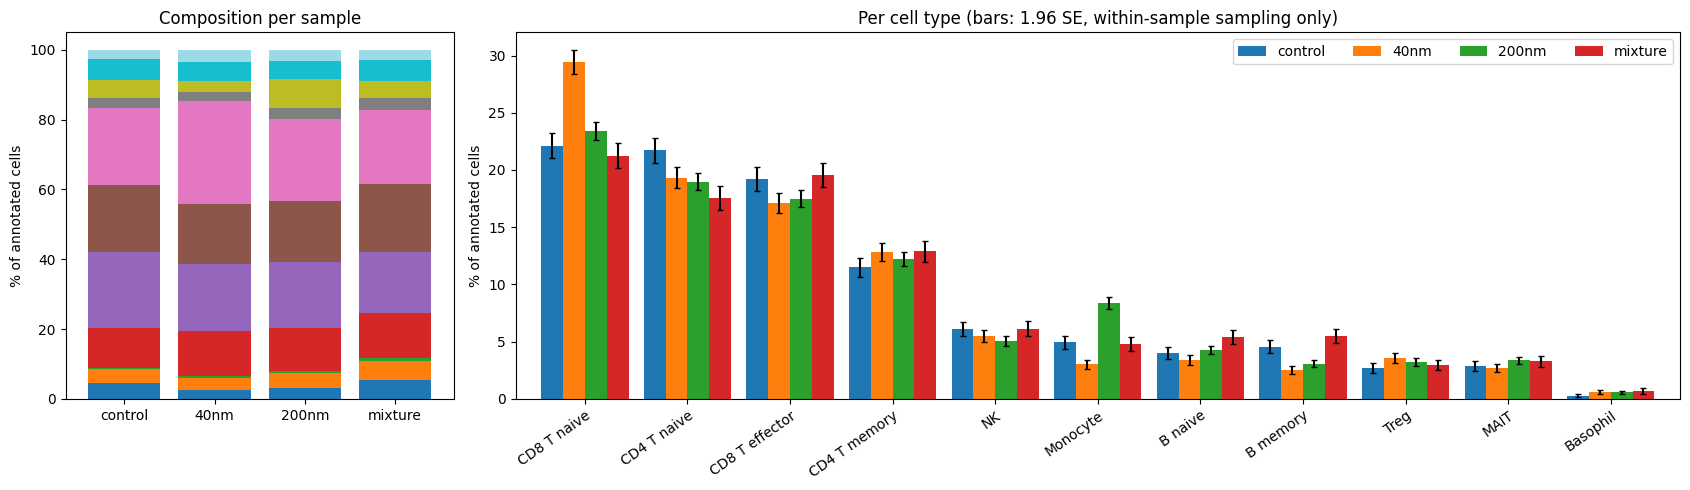

In [59]:
import matplotlib.pyplot as plt  # repeated from Section 2 so Section 12 runs from the checkpoint alone
# Two views of the same table. The stacked bars answer "what is each sample made of"; the
# grouped bars answer "which types moved", which the stacked view cannot show for anything
# below a few percent. Error bars are the within-sample interval from the cell above - they
# are a floor on interpretability, not a test.
fig, axes = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [1, 3]})

pct.T.plot.bar(stacked=True, ax=axes[0], width=0.8, colormap='tab20', legend=False)
axes[0].set(ylabel='% of annotated cells', xlabel='', title='Composition per sample')
axes[0].tick_params(axis='x', rotation=0)

order = pct.mean(axis=1).sort_values(ascending=False).index
pct.loc[order].plot.bar(ax=axes[1], width=0.85, yerr=1.96 * se.loc[order], capsize=2)
axes[1].set(ylabel='% of annotated cells', xlabel='',
            title='Per cell type (bars: 1.96 SE, within-sample sampling only)')
axes[1].legend(title='', ncol=4)
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')
plt.tight_layout()
plt.show()

### Stating the effect — three defensible measures, and what each one costs

Three candidates for the effect measure, none free:

- **Percentage-point difference** — directly interpretable, but not scale-free:
  0.5pp is the entire Basophil population and invisible on CD4 T naive, so a
  ranked list is dominated by whichever types are already large.
- **Log2 ratio** — scale-free and symmetric (halving/doubling = ∓1/±1), so rare
  and common types become comparable. Unstable where the denominator is small —
  Basophil has 15 control cells, and a handful either way swings the ratio hard.
- **Centred log-ratio (CLR)** — the compositional-data answer to closure: each
  type is referenced to the geometric mean of all types rather than to the total,
  so a genuine monocyte expansion no longer pushes every other type negative by
  construction. Cost: a CLR value is only meaningful relative to other CLR values
  in the same sample, not on its own.


In [60]:
# The comparison against control, per cell type. Closure (deviation 4 above) is what makes
# this a choice rather than a subtraction: proportions sum to 100, so the measure decides
# whether a shared downward shift across every lymphocyte type reads as real depletion or as
# the arithmetic shadow of the monocyte column growing.
EXPOSED = ['40nm', '200nm', 'mixture']

# Percentage points, not a ratio. Two reasons, both specific to this dataset:
#   - the interval computed above is in these same units, so every change can be read against
#     its own noise floor directly. Neither a log ratio nor a CLR value has a closed-form
#     interval here without bootstrapping.
#   - a ratio would put Basophil at the top of every sample (log2 +1.1 to +1.4, above
#     Monocyte's +0.9) on the strength of 15 control cells. That is instability, not biology.
effect = pct[EXPOSED].sub(pct['control'], axis=0)

# The floor for a DIFFERENCE between two independent binomial proportions, in the same units.
# This is NOT a significance test: it says whether a shift is bigger than capture noise within
# each sample, not whether exposure caused it. With one sample per condition, nothing can.
noise = pd.DataFrame({s: np.hypot(1.96 * se[s], 1.96 * se['control']) for s in EXPOSED})

print('change vs control, percentage points')
print(effect.round(2).to_string())
print()
print('exceeds the within-sample sampling floor?')
print((effect.abs() > noise).to_string())

# CLR as a robustness check on closure, printed rather than carried forward: each type is
# referenced to the geometric mean of all types in its OWN sample instead of to the total, so
# one column growing no longer drags every other one negative by construction. A sign that
# survives both measures is not an artefact of the proportions summing to 100.
clr = np.log(pct) - np.log(pct).mean()
clr_d = clr[EXPOSED].sub(clr['control'], axis=0)
print()
print('CLR difference vs control - closure-corrected, for comparison only')
print(clr_d.round(2).to_string())
agree = int((np.sign(effect) == np.sign(clr_d)).sum().sum())
print(f'sign agrees between the two measures on {agree} of {effect.size} cell type x sample cells')


change vs control, percentage points
Sample          40nm  200nm  mixture
cell_type                           
B memory       -2.08  -1.49     0.91
B naive        -0.61   0.24     1.39
Basophil        0.32   0.31     0.43
CD4 T memory    1.32   0.74     1.38
CD4 T naive    -2.37  -2.72    -4.14
CD8 T effector -2.11  -1.71     0.36
CD8 T naive     7.33   1.28    -0.88
MAIT           -0.17   0.49     0.43
Monocyte       -1.93   3.38    -0.17
NK             -0.56  -1.03     0.04
Treg            0.86   0.50     0.26

exceeds the within-sample sampling floor?
Sample           40nm  200nm  mixture
cell_type                            
B memory         True   True     True
B naive         False  False     True
Basophil         True   True     True
CD4 T memory     True  False     True
CD4 T naive      True   True     True
CD8 T effector   True   True    False
CD8 T naive      True  False    False
MAIT            False  False    False
Monocyte         True   True    False
NK              False

---

## Section 13 — Differential expression (Task 5)

**Task 5**, first half — DE, each cell type, each exposed sample vs. control. The
task list names no method, so it's argued for here.

**Pseudobulk** (counts summed per cell type × sample) is the choice that decides
everything else. Testing each of 29,157 cells individually would treat them as
independent observations of an exposure, but they're four 10x channels from one
donor — a per-cell test returns p-values of order 1e-50 answering "did we
sequence a lot of cells?", not "did the particles do anything?" Pseudobulk
collapses to the unit that's genuinely replicated (1 sample per condition) and is
honest about what that leaves.

**Therefore: no p-values in this section.** With one sample per condition
there's no within-group variation, so no method can estimate how large a fold
change has to be before it's surprising — every route to one assumes the answer
somewhere: `pydeseq2` refuses outright ("no replicates to estimate the
dispersion"); pooling across cell types borrows replication from *between cell
types*, answering a different question; splitting cells into pseudo-replicates
re-introduces the exact pseudoreplication pseudobulk exists to avoid; a fixed
literature dispersion states its assumption honestly but still assumes the thing
that matters. So this section reports **effect sizes only** — a `padj` column
would need permanent disclaiming, and disclaimers don't travel with a column
into tables and figures the way their absence does.

**What's computed instead:** median-of-ratios size factors (DESeq2's
normalizer, computed directly — preferred over total-count scaling because
monocytes carry a large inflammatory program that would otherwise set the scale
on its own), and log2 fold change with a prior count
(`log2((exposed+k)/(control+k))` — without the prior, a gene at 0 in control and
40 in an exposed sample returns infinity, and genes with single-digit counts
dominate any ranking; `k` is swept below, not asserted). Output: one log2FC
table per cell type × contrast — a ranked list, no significance threshold
required, which is exactly what Section 14's GSEA consumes.


In [61]:
# Sections 13-14 run from the annotated checkpoint alone - the contract Section 12 states and
# the only one that survives a kernel restart. Run Section 1's imports, then this cell, then
# straight down. Without it a cold kernel has to re-run Sections 5-11 to reach here, scanorama
# and both annotation models included.
if 'adata' not in globals():
    adata = sc.read_h5ad(Path('results') / 'annotated.h5ad')
    print(f'resumed from checkpoint: {adata.n_obs:,} cells x {adata.n_vars:,} genes')

# MIN_PSEUDOBULK and DE_GROUPS are re-derived here rather than inherited from Section 11, where
# they are first printed as an annotation deliverable. Deliberate duplication: Section 13 must
# not depend on a cell 19 positions above it that produces nothing else it uses.
MIN_PSEUDOBULK = 50
_grid = (adata.obs[adata.obs['cell_type_coarse'] != 'Exclude']
         .groupby(['cell_type_coarse', 'Sample'], observed=True).size().unstack(fill_value=0))
DE_GROUPS = list(_grid.index[_grid.min(axis=1) >= MIN_PSEUDOBULK])
print(f'DE_GROUPS, >= {MIN_PSEUDOBULK} cells in every sample ({len(DE_GROUPS)}): {DE_GROUPS}')

DE_GROUPS, >= 50 cells in every sample (8): ['B', 'CD4 T', 'CD8 T', 'CD8 T naive', 'MAIT', 'Monocyte', 'NK', 'Treg']


In [62]:
# Pseudobulk: sum RAW counts per (coarse cell type x sample). Raw, not normalized - summing
# normalized values would weight each cell equally regardless of depth, which is the opposite
# of what pooling a group should do.
import scipy.sparse as sp

EXPOSED = ['40nm', '200nm', 'mixture']
MIN_GENE_COUNT = 10          # summed across the 4 columns of one cell type

keep = adata.obs['cell_type_coarse'].isin(DE_GROUPS).to_numpy()
keys = (adata.obs['cell_type_coarse'].astype(str) + '|' + adata.obs['Sample'].astype(str))[keep]
cats = [f'{ct}|{s}' for ct in DE_GROUPS for s in ['control'] + EXPOSED]
code = pd.Categorical(keys, categories=cats).codes
assert (code >= 0).all(), 'a cell fell outside the expected cell type x sample grid'

onehot = sp.csr_matrix((np.ones(int(keep.sum()), dtype=np.float32),
                        (code, np.arange(int(keep.sum())))), shape=(len(cats), int(keep.sum())))
pb = pd.DataFrame(np.asarray((onehot @ adata.layers['counts'][keep]).todense()),
                  index=cats, columns=adata.var_names)

n_cells = pd.Series(np.bincount(code, minlength=len(cats)), index=cats)
print(f'pseudobulk: {pb.shape[0]} columns x {pb.shape[1]:,} genes, '
      f'from {int(keep.sum()):,} of {adata.n_obs:,} cells '
      f'({adata.n_obs - int(keep.sum()):,} excluded: Basophil and the Exclude group)')
print('\ncells behind each pseudobulk column')
print(n_cells.rename('cells').to_frame().T.to_string())

# The whole design in one number. Everything downstream is 1-vs-1.
assert n_cells.min() >= MIN_PSEUDOBULK, f'a column has under {MIN_PSEUDOBULK} cells'

# Median-of-ratios size factors. Genes with a zero in any column cannot contribute a ratio,
# so the estimator uses only genes present everywhere - that is DESeq2's behaviour too.
logpb = np.log(pb.replace(0, np.nan))
ref = logpb.mean(axis=0)
usable = ref.notna()
size_factors = np.exp(logpb.loc[:, usable].sub(ref[usable], axis=1).median(axis=1))
norm = pb.div(size_factors, axis=0)

print(f'\nsize factors from {int(usable.sum()):,} genes present in all {len(cats)} columns')
print(size_factors.round(2).rename('size factor').to_frame().T.to_string())

pseudobulk: 32 columns x 21,862 genes, from 28,783 of 29,157 cells (374 excluded: Basophil and the Exclude group)

cells behind each pseudobulk column
       B|control  B|40nm  B|200nm  B|mixture  CD4 T|control  CD4 T|40nm  CD4 T|200nm  CD4 T|mixture  CD8 T|control  CD8 T|40nm  CD8 T|200nm  CD8 T|mixture  CD8 T naive|control  CD8 T naive|40nm  CD8 T naive|200nm  CD8 T naive|mixture  MAIT|control  MAIT|40nm  MAIT|200nm  MAIT|mixture  Monocyte|control  Monocyte|40nm  Monocyte|200nm  Monocyte|mixture  NK|control  NK|40nm  NK|200nm  NK|mixture  Treg|control  Treg|40nm  Treg|200nm  Treg|mixture
cells        484     432      793        567           1870        2352         3371           1585           1081        1250         1888           1018                 1246              2154               2527                 1106           161        197         362           171               279            221             900               249         342      403       545         318         

In [63]:
# The prior count, swept rather than asserted. It sets how many normalized counts a gene needs
# before its ratio is allowed to move - the job shrinkage does in DESeq2. Read the sweep as:
# how many genes clear |log2FC| > 1 in monocytes at 200nm, and what the largest value is.
mono = f'Monocyte|200nm'
ctrl = f'Monocyte|control'
print(f'{"prior":>7}{"|LFC|>1":>10}{"max |LFC|":>12}{"median count of those genes":>30}')
for k in (0, 1, 5, 10, 25):
    with np.errstate(divide='ignore', invalid='ignore'):
        l = np.log2((norm.loc[mono] + k) / (norm.loc[ctrl] + k))
    big = np.isfinite(l) & (l.abs() > 1)
    med = norm.loc[[mono, ctrl]].max()[big].median() if big.any() else float('nan')
    print(f'{k:>7}{int(big.sum()):>10,}{np.nanmax(np.abs(l[np.isfinite(l)])):>12.1f}{med:>30.1f}')

# k=5: at k=0 the list is dominated by genes with a handful of reads and infinite ratios; by
# k=25 real differences in moderately expressed genes are being flattened. 5 keeps genes whose
# ratio rests on tens of counts rather than ones.
PRIOR_COUNT = 5

lfc = {}
for ct in DE_GROUPS:
    cols = [f'{ct}|{s}' for s in ['control'] + EXPOSED]
    raw, sub = pb.loc[cols], norm.loc[cols]
    keep_g = (raw.sum(axis=0) >= MIN_GENE_COUNT).to_numpy()
    sub = sub.loc[:, keep_g]
    lfc[ct] = pd.DataFrame(
        {s: np.log2((sub.loc[f'{ct}|{s}'] + PRIOR_COUNT) / (sub.loc[f'{ct}|control'] + PRIOR_COUNT))
         for s in EXPOSED})

print(f'\ngenes retained per cell type (>= {MIN_GENE_COUNT} counts across its 4 columns)')
print(pd.Series({ct: len(v) for ct, v in lfc.items()}, name='genes').to_frame().T.to_string())

# Counting large fold changes per cell type is reported WITH the cell count, because the two
# are strongly inversely related (Spearman about -0.86 here): fewer cells -> noisier pseudobulk
# -> more spurious large ratios. The count column is therefore not comparable between cell
# types, and reading 'this cell type responded more' off it would be reading n.
print(f'\ngenes with |log2FC| > 1 - NOT comparable across rows, see the cell counts')
counts_tbl = pd.DataFrame({ct: (v.abs() > 1).sum() for ct, v in lfc.items()}).T[EXPOSED]
counts_tbl.insert(0, 'cells', [int(sum(n_cells[f'{ct}|{s}'] for s in ['control'] + EXPOSED))
                               for ct in counts_tbl.index])
print(counts_tbl.sort_values('cells').to_string())

  prior   |LFC|>1   max |LFC|   median count of those genes
      0     4,898         8.8                          10.0
      1     4,754         7.8                          10.0
      5     2,135         6.7                          55.8
     10     1,529         6.3                         112.4
     25       954         6.1                         265.1

genes retained per cell type (>= 10 counts across its 4 columns)
           B  CD4 T  CD8 T  CD8 T naive   MAIT  Monocyte     NK   Treg
genes  16332  18052  15984        17169  12053     16680  13306  11897

genes with |log2FC| > 1 - NOT comparable across rows, see the cell counts
             cells  40nm  200nm  mixture
MAIT           891  1416   1349     1255
Treg           911  1414   1376     1292
NK            1608  1266   1402     1084
Monocyte      1649  2423   2135     2385
B             2276   834    845      644
CD8 T         5237   567    762      273
CD8 T naive   7033   476    639      172
CD4 T         9178   341    5

### Reading the fold-change tables

A value of `+1` means the gene's normalized pseudobulk count doubled against
control, `-1` that it halved. **There is no significance column, and
`|log2FC| > 1` is a display cutoff for counting how much moved, not a
significance threshold** — two genes at 1.05 and 0.95 aren't different in kind.

**The counts table must not be read across rows.** Cell types with fewer cells
give noisier pseudobulk and therefore more large ratios — the correlation
between cell count and "genes with |log2FC| > 1" is about −0.86 here, printed
beside it so the confound is visible. Comparing *within* a row across contrasts
is fine; comparing *between* rows is reading sample size.


In [64]:
# Where the changes concentrate, and in which direction. The comparison that carries weight is
# BETWEEN cell types under the same exposure - all of them share the four channels and one
# normalisation, so a channel effect cannot single one cell type out.
print('median |log2FC| across retained genes - a per-cell-type magnitude, not a test')
print(pd.DataFrame({ct: v.abs().median() for ct, v in lfc.items()}).T[EXPOSED].round(3).to_string())

N_TOP = 12
for ct in ['Monocyte', 'CD4 T']:
    print(f'\n{"=" * 70}\n{ct}: strongest changes per contrast (log2FC, prior={PRIOR_COUNT})')
    for s in EXPOSED:
        col = lfc[ct][s].sort_values()
        up = ', '.join(f'{g} {v:+.1f}' for g, v in col.tail(N_TOP)[::-1].items())
        dn = ', '.join(f'{g} {v:+.1f}' for g, v in col.head(N_TOP // 2).items())
        print(f'  {s:<8} up  : {up}')
        print(f'  {"":<8} down: {dn}')

median |log2FC| across retained genes - a per-cell-type magnitude, not a test
              40nm  200nm  mixture
B            0.288  0.286    0.230
CD4 T        0.239  0.236    0.172
CD8 T        0.282  0.277    0.220
CD8 T naive  0.262  0.264    0.195
MAIT         0.374  0.348    0.325
Monocyte     0.401  0.355    0.384
NK           0.327  0.350    0.296
Treg         0.381  0.357    0.307

Monocyte: strongest changes per contrast (log2FC, prior=5)
  40nm     up  : MMP1 +6.8, CSF3 +6.2, CSF2 +6.2, IL24 +6.1, PTGES +5.6, CCL20 +5.5, PI3 +4.9, OSM +4.6, SERPINB7 +4.5, VNN3 +4.3, PTGS2 +4.2, IL6 +4.1
           down: SPP1 -7.7, CCL1 -6.9, GSN -6.9, CD36 -6.5, GPC4 -6.2, RP11-20G13.3 -6.2
  200nm    up  : MMP1 +6.3, IL24 +6.0, CSF3 +5.7, CCL20 +5.1, SERPINB7 +4.9, VNN3 +4.6, PTGS2 +4.6, IL6 +4.3, CXCL13 +4.1, HAS1 +4.1, DNER +4.1, CSF2 +3.9
           down: GPC4 -6.7, SPP1 -6.4, GSN -5.5, OCSTAMP -5.5, GAL -5.2, RP11-20G13.3 -5.1
  mixture  up  : IL24 +6.7, MMP1 +6.6, CSF3 +6.6, CSF2 +6.4,

### Ambient RNA — why the lymphocyte lists are not responses

The strongest apparent result above — **every** cell type upregulating an
inflammatory program under exposure — is not real, and this is the evidence.

`IL8` carries a median of **478 copies per monocyte** and **2 per lymphocyte**,
with 76% of the lymphocytes that carry it at all holding only 1-2 copies — a
Poisson sprinkle of an abundant transcript across every droplet: free-floating
mRNA from lysed cells, captured alongside whatever cell the droplet actually
held.

**Why pseudobulk hides it:** 3,000 lymphocytes at 2 copies each sums to 6,000,
indistinguishable in a pseudobulk column from 50 cells at 120 copies each.
Collapsing to sample level solved pseudoreplication and simultaneously
destroyed the per-cell evidence that separates soup from signal — so the
diagnostic below runs on per-cell data instead, and constrains what the
pseudobulk tables above are allowed to claim.

**Measured scale:** myeloid inflammatory genes occupy 15 of the top 30
upregulated genes in CD4 T at 200nm, 16 of 30 in CD8 T naive, 13 in Treg —
against only 8 of 30 in the monocytes that actually produced them.
Contamination dominates the ranking worst exactly where the real biology is
quietest.

**Why it isn't filtered out:** three criteria were tried and each failed —
count thresholds among expressing cells are confounded with sequencing depth
(drops `ACTB` from the shallower CD8 T); expression-relative-to-lowest-cell-type
removes uniformly expressed genes like `B2M`/`ACTB` by construction; and both
combined still miss `IL8`, abundant enough in the soup to clear any threshold
low enough to keep real genes. SoupX/CellBender can't help either — they
measure the soup from empty droplets in the *raw* CellRanger matrix, and these
files are the *filtered* output, so those droplets were already discarded
before the data reached us.

**What is and isn't claimed:**
- **Not claimed:** pathway-level inflammatory enrichment in any lymphocyte
  population. A myeloid program appearing across seven unrelated cell types at
  once, in monocyte proportions, including genes lymphocytes have no route to
  expressing (`MMP1`, a matrix metalloproteinase; `CSF3`, G-CSF) is
  contamination — coherence identifies it, not magnitude.
- **Not settled either way:** any individual gene in any individual cell. ~16
  lymphocytes carry double-digit `IL8` at normal depth with no myeloid markers,
  and some T cell subsets are documented IL-8 producers — this data can't
  resolve those cases, and nothing here calls them artifacts.
- **Unaffected:** the monocyte result itself. 478 copies per cell is
  transcription, not soup.


In [65]:
# Ambient diagnostic, reported ALONGSIDE the fold changes rather than used as a filter - no
# threshold separates soup from signal here (see above), so the evidence is shown per gene and
# the reader judges it.
#
#   frac_le2  of the cells expressing this gene, the share carrying only 1-2 copies. Soup
#             deposits a Poisson sprinkle, so ~0.7-0.8 is the ambient signature.
#   mean_nz   mean copies among expressing cells.
counts_csr = sp.csr_matrix(adata.layers['counts'])
_ctv = adata.obs['cell_type_coarse'].astype(str).values


def ambient_stats(cell_type):
    """Per gene, within one cell type: mean copies among expressers, and the <=2-copy share."""
    sub_m = counts_csr[_ctv == cell_type]
    nnz = np.asarray((sub_m > 0).sum(axis=0)).ravel()
    tot = np.asarray(sub_m.sum(axis=0)).ravel()
    low = sub_m.copy()
    low.data = ((low.data >= 1) & (low.data <= 2)).astype(np.float32)
    le2 = np.asarray(low.sum(axis=0)).ravel()
    denom = np.maximum(nnz, 1)
    return pd.DataFrame({'mean_nz': np.where(nnz > 0, tot / denom, np.nan),
                         'frac_le2': np.where(nnz > 0, le2 / denom, np.nan)},
                        index=adata.var_names)


print('top 12 upregulated at 200nm, with the ambient diagnostic beside the fold change')
for ct in ['Monocyte', 'CD4 T', 'NK']:
    st = ambient_stats(ct)
    top = lfc[ct]['200nm'].sort_values(ascending=False).head(12)
    print(f'\n--- {ct} ---')
    print(pd.DataFrame({'log2FC': top.round(2),
                        'mean_nz': st.loc[top.index, 'mean_nz'].round(1),
                        'frac_le2': st.loc[top.index, 'frac_le2'].round(2)}).to_string())

print('\nIL8 across cell types - the worked example')
print(pd.DataFrame({ct: ambient_stats(ct).loc['IL8'] for ct in DE_GROUPS}).T.round(2).to_string())

top 12 upregulated at 200nm, with the ambient diagnostic beside the fold change

--- Monocyte ---
          log2FC  mean_nz  frac_le2
MMP1        6.33     57.2      0.19
IL24        6.00     26.5      0.13
CSF3        5.69      9.5      0.34
CCL20       5.10     16.8      0.26
SERPINB7    4.94     11.9      0.16
VNN3        4.64      3.4      0.50
PTGS2       4.57     28.7      0.16
IL6         4.26     27.2      0.12
CXCL13      4.14     18.2      0.62
HAS1        4.07      3.7      0.59
DNER        4.06      2.9      0.70
CSF2        3.86     19.4      0.35

--- CD4 T ---
          log2FC  mean_nz  frac_le2
CXCL3       3.79      1.1      0.99
CXCL5       3.66      1.2      0.98
CXCL1       3.55      1.1      0.99
IL1B        3.53      1.2      0.97
MMP1        3.50      1.1      0.99
IL8         3.47      1.9      0.76
IL6         3.27      1.0      1.00
CCL3        3.22      1.2      0.98
PTGS2       3.12      1.1      0.99
CXCL2       3.06      1.1      0.99
SERPINB2    3.06      1

---

## Section 14 — Pathway enrichment (Task 5, second half)

**Task 5**, second half — pathway enrichment (GO/Reactome/KEGG).

**GSEA, not ORA — because of Section 13.** ORA needs a thresholded "significant
genes" list; Section 13 deliberately produces no significance threshold, so ORA
would require inventing one. GSEA uses the whole ranked list instead and catches
coordinated effects no individual gene would clear a threshold for — the exact
situation here, where per-gene evidence is weak but a coherent program may still
be visible.

**KEGG only, not GO/Reactome/KEGG together.** All three were measured before
choosing:

| | sets after size filter | symbol match | runtime, 24 runs |
|---|---|---|---|
| **KEGG** | **224** | **90.3%** | **~12-20 min** |
| Reactome | 978 | 82.4% | ~41 min |
| GO:BP | 3,777 | 75.5% | ~151 min |

The three are heavily redundant, not independent — curated from overlapping
literature by overlapping communities, so "found in all three" would reflect
shared sources, not corroboration. KEGG wins on symbol coverage, least
redundancy, and canonical pathway names for this experiment. Reactome/GO:BP stay
available but unrun; adding Reactome later is a one-line change.

**`KEGG_2021_Human` via Enrichr, not MSigDB's `KEGG MEDICUS`.** MEDICUS frames
pathways around diseases/pathogens (this section's top monocyte hit under
MEDICUS was named after cytomegalovirus for a generic chemokine-to-NF-κB gene
module) and is badly redundant — six "different" B-cell pathways at q<0.01
turned out to be one 87-gene electron-transport-chain set with 98% median
pairwise overlap. Cost of using Enrichr instead: it serves undated copies, so
the result can't be re-fetched at a known version — the access date is printed
so the result is at least attributable.

**The symbol map matters again.** Pre-2017 HGNC symbols vs. MSigDB's current
ones — built from HGNC's `prev_symbol`/`alias_symbol` fields, applied before
running, recovering ~3 percentage points of coverage. The residual gap is
mostly genes genuinely absent from our data (not expressed in PBMCs, or below
Section 4's `min_cells=10`), not nomenclature — so per-set match fraction is
reported, since a pathway scored on 40% of its genes isn't scored on the
pathway.

**What the p-value means here, precisely:** GSEA's p-value comes from
permuting gene labels *within the ranked list* — it answers "given this
ranking, is this pathway more concentrated at one end than chance?", a
statement about the list that's legitimate without biological replicates. It is
**not** a claim that exposure activated the pathway: the ranking itself rests
on n=1 per condition. NES/FDR describe how coherently a pathway sits in a
ranking; attribution to exposure still needs replication this experiment
doesn't have.

### A second artefact: sequencing depth, and why ribosomal genes are excluded

The ambient check from Section 13 isn't sufficient on its own. Run with every
gene included, CD4 T's top hit was a KEGG MEDICUS set named "translation
initiation" (NES 2.13, FDR 0.005) that passed the contamination test cleanly
(`ambient_frac` 0.03) — but the set is actually 78 of 80 ribosomal proteins and
zero initiation factors, and ribosomal share tracks sequencing depth, which is
confounded with exposure:

| ribosomal % of pseudobulk | control | mixture | 40nm | 200nm |
|---|---|---|---|---|
| median sample depth | 7,852 | 6,373 | 5,477 | 4,440 |
| CD4 T | 29.0 | 30.1 | 34.4 | 34.5 |
| CD8 T naive | 30.9 | 32.4 | 38.4 | 38.6 |
| B | 22.9 | 25.3 | 28.4 | 28.2 |

Exactly the depth ordering, reversed — in a shallower sample low-expression
genes drop out entirely, so the highest expressors take a larger share of what
remains, and size-factor normalization doesn't undo a change in *composition*.
The ambient diagnostic can't catch this because ribosomal genes are genuinely
transcribed at high levels (`frac_le2` stays low, correctly) — a second,
independent artifact distorting the same output, invisible to the first
diagnostic.

**The response:** ribosomal/mitochondrial genes are dropped from the
**ranking handed to GSEA only** — not from the data, and not from Section 13's
fold changes. Narrower than Section 3's decision (which declined to filter
*cells* on ribo%): here the genes stay everywhere except the ranked list, where
their depth dependence would otherwise be read as enrichment. This doesn't
fully fix the artifact — it's compositional, not gene-specific, so the next
tier of high expressors inherits the same behavior; the root cause (Section 4's
depth gradient) isn't correctable here, only worked around for this one output.

### The ambient constraint, enforced rather than documented

Left alone, GSEA would report inflammatory pathways enriched in CD4 T/NK/
Treg/MAIT — a false positive at exactly the level Task 5 delivers. GSEA names
the leading edge (the genes that actually drove each enrichment), so for every
pathway the fraction of leading-edge genes with `frac_le2 > 0.7` is reported
beside the score — using the diagnostic already built, rather than inventing a
second rule.


In [66]:
# Gene sets: Enrichr's KEGG_2021_Human, the classic KEGG collection. See the markdown above
# for why not MSigDB's KEGG MEDICUS - the names there are disease-framed and the sets heavily
# redundant.
#
# Fetched with urllib rather than gseapy.get_library(), which fails on this machine with an SSL
# certificate error: it uses `requests` and certifi's CA bundle, while the chain here resolves
# only through the OS store. The parsed dict is what get_library would have returned.
import gseapy as gp
import urllib.request
from datetime import date

ENRICHR = 'https://maayanlab.cloud/Enrichr/geneSetLibrary?mode=text&libraryName='
LIBRARY = 'KEGG_2021_Human'

with urllib.request.urlopen(ENRICHR + LIBRARY, timeout=90) as fh:
    _rows = fh.read().decode().strip().split('\n')
kegg_raw = {p[0]: [x for x in p[1:] if x] for p in (r.split('\t') for r in _rows)}
print(f'{LIBRARY}: {len(kegg_raw)} sets, '
      f'{len(set().union(*kegg_raw.values())):,} distinct genes')
print(f'fetched {date.today()} - Enrichr serves undated copies, so this is the only version '
      f'information available')

# Current -> legacy symbol map. Only unambiguous cases are used: the current symbol must be
# ABSENT from our data and exactly one of its old names present, so nothing is silently merged
# onto a gene we already have.
HGNC_URL = ('https://storage.googleapis.com/public-download-files/hgnc/tsv/tsv/'
            'hgnc_complete_set.txt')
hgnc = pd.read_table(HGNC_URL, low_memory=False,
                     usecols=['symbol', 'prev_symbol', 'alias_symbol', 'status'])
hgnc = hgnc[hgnc.status == 'Approved']
ours = set(adata.var_names)
SYMBOL_MAP = {}
for cur, prev, ali in hgnc[['symbol', 'prev_symbol', 'alias_symbol']].itertuples(index=False):
    hits = {p for fld in (prev, ali) if pd.notna(fld)
            for p in str(fld).split('|') if p in ours}
    if cur not in ours and len(hits) == 1:
        SYMBOL_MAP[cur] = hits.pop()
print(f'symbol map: {len(SYMBOL_MAP):,} unambiguous current->legacy translations')

# Translate into our vocabulary, then keep only genes we actually measured.
before = sum(len(set(v) & ours) for v in kegg_raw.values())
KEGG = {k: sorted({SYMBOL_MAP.get(g, g) for g in v} & ours) for k, v in kegg_raw.items()}
after = sum(len(v) for v in KEGG.values())
print(f'gene-set memberships matched to our data: {before:,} -> {after:,} after mapping '
      f'(+{after - before:,})')

# Size filter, standard GSEA practice: below ~15 genes the enrichment score is unstable, above
# ~500 the set is too broad to interpret.
MIN_SET, MAX_SET = 15, 500
KEGG = {k: v for k, v in KEGG.items() if MIN_SET <= len(v) <= MAX_SET}
coverage = pd.Series({k: len(v) / len(set(kegg_raw[k])) for k, v in KEGG.items()})
print(f'{len(KEGG)} sets retained at size {MIN_SET}-{MAX_SET}')
print(f'per-set coverage of original members: median {coverage.median():.0%}, '
      f'{(coverage < 0.5).sum()} sets below 50%')

KEGG_2021_Human: 320 sets, 8,078 distinct genes
fetched 2026-09-01 - Enrichr serves undated copies, so this is the only version information available
symbol map: 1,617 unambiguous current->legacy translations
gene-set memberships matched to our data: 27,151 -> 27,936 after mapping (+785)
299 sets retained at size 15-500
per-set coverage of original members: median 90%, 4 sets below 50%


In [67]:
# Ribosomal and mitochondrial genes are dropped from the RANKING, not from the data. They
# are the largest single block of counts (10-38% of a lymphocyte pseudobulk column) and
# their share tracks sequencing depth, which is confounded with exposure here: control
# 7,852 median counts > mixture 6,373 > 40nm 5,477 > 200nm 4,440, and ribosomal share runs
# 29.0 / 30.1 / 34.4 / 34.5 in CD4 T - the same order, reversed. In a shallower sample the
# low-expression genes drop out entirely and the highest expressors take a larger share of
# what remains; size-factor normalisation does not undo that.
#
# Left in, this produced KEGG_MEDICUS_REFERENCE_TRANSLATION_INITIATION as CD4 T's top hit
# (NES 2.13, FDR 0.005) - a set that is 78 of 80 ribosomal proteins and zero initiation
# factors, despite the name. Note the ambient diagnostic CANNOT catch this: ribosomal genes
# are genuinely transcribed at high levels, so frac_le2 is low and they look clean. It is a
# second, independent artefact affecting the same output.
#
# This is a narrower decision than Section 3's: there we declined to filter CELLS on ribo%.
# Here the genes stay in the data and in Section 13's fold changes - they are excluded only
# from the ranked list handed to GSEA, where their depth dependence would otherwise be read
# as pathway enrichment.
RANK_EXCLUDE = adata.var_names[(adata.var['ribo'] | adata.var['mt']).to_numpy()]
print(f'excluded from rankings: {len(RANK_EXCLUDE)} ribosomal/mitochondrial genes')

# One preranked GSEA per cell type x contrast, ranked by Section 13's log2 fold change.
# 24 runs; measured at roughly 30s each on 8 threads, so budget 15-25 minutes.
N_PERM = 1000
gsea_raw = {}
for ct in DE_GROUPS:
    for s in EXPOSED:
        # Deterministic ordering. About 36% of genes share a fold change with another -
        # low counts give identical integer ratios - and gseapy warns that the order
        # within a tie is arbitrary. Measured on Monocyte/200nm: ties are 39% of the flat
        # middle but only 1.5% of the top 200 and 4.5% of the bottom 200, which is the
        # part driving the enrichment score. So this is about reproducibility, not about
        # the result. Ties break on mean expression: more evidence ranks first.
        col = lfc[ct][s].dropna().drop(index=RANK_EXCLUDE, errors='ignore')
        expr = norm.loc[[f'{ct}|control', f'{ct}|{s}'], col.index].mean()
        rnk = (col.to_frame('lfc').assign(expr=expr)
               .sort_values(['lfc', 'expr'], ascending=[False, False])['lfc'])
        out = gp.prerank(rnk=rnk, gene_sets=KEGG, permutation_num=N_PERM, threads=4,
                         min_size=MIN_SET, max_size=MAX_SET, outdir=None, seed=0,
                         verbose=False)
        gsea_raw[(ct, s)] = out.res2d
    print(f'  {ct} done', flush=True)

# Cache the ambient statistics once per cell type - ambient_stats() rescans the count matrix,
# and it is about to be asked for every leading edge.
AMB = {ct: ambient_stats(ct) for ct in DE_GROUPS}

rows = []
for (ct, s), df in gsea_raw.items():
    st = AMB[ct]
    # Columns are addressed BY NAME. res2d is ['Name','Term','ES','NES','NOM p-val',
    # 'FDR q-val',...], so positional access via itertuples silently returns the nominal
    # p-value where the FDR was meant - a wrong number that looks entirely plausible.
    for _, r in df.iterrows():
        lead = [x for x in str(r['Lead_genes']).split(';') if x in st.index]
        rows.append({'cell_type': ct, 'contrast': s, 'pathway': r['Term'],
                     'NES': float(r['NES']), 'FDR': float(r['FDR q-val']),
                     'nom_p': float(r['NOM p-val']), 'n_lead': len(lead),
                     'ambient_frac': float((st.loc[lead, 'frac_le2'] > 0.7).mean())
                                     if lead else np.nan})
gsea = pd.DataFrame(rows)
print(f'\n{len(gsea):,} pathway x cell type x contrast results')

excluded from rankings: 98 ribosomal/mitochondrial genes


2026-09-01 19:36:17,614 [WARNING] Duplicated values found in preranked stats: 41.12% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:36:23,915 [WARNING] Duplicated values found in preranked stats: 37.52% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:36:30,225 [WARNING] Duplicated values found in preranked stats: 35.84% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  B done


2026-09-01 19:36:36,600 [WARNING] Duplicated values found in preranked stats: 33.81% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:36:43,507 [WARNING] Duplicated values found in preranked stats: 32.21% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:36:50,745 [WARNING] Duplicated values found in preranked stats: 37.22% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  CD4 T done


...

  Monocyte done


2026-09-01 19:38:08,859 [WARNING] Duplicated values found in preranked stats: 48.91% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:38:13,785 [WARNING] Duplicated values found in preranked stats: 47.13% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:38:18,800 [WARNING] Duplicated values found in preranked stats: 50.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  NK done


2026-09-01 19:38:23,771 [WARNING] Duplicated values found in preranked stats: 57.53% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:38:28,090 [WARNING] Duplicated values found in preranked stats: 55.71% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-09-01 19:38:32,442 [WARNING] Duplicated values found in preranked stats: 62.51% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


  Treg done

6,885 pathway x cell type x contrast results


### Reading the enrichment table

- **NES** — normalized enrichment score; positive means the pathway's genes sit
  toward the *up* end of the ranking, negative toward *down*. Comparable
  between pathways since it's normalized for set size.
- **FDR** — permutation false discovery rate; GSEA convention treats
  **FDR < 0.25** as worth attention (far more permissive than 0.05 for
  individual genes, since pathway-level analysis is hypothesis-generating).
- **n_lead** — genes driving the enrichment.
- **ambient_frac** — share of those leading-edge genes with `frac_le2 > 0.7`
  in that cell type — near 0 means genuinely transcribed, near 1 means driven
  by soup and meaningless for that cell type. No clean threshold separates
  them (Section 13), so the number is reported and the reader judges.

The same framing holds for every row: **FDR describes the ranking, not the
experiment.**

**A residual confound to watch:** monocyte clean-pathway counts (44/61/58 at
200nm/40nm/mixture) don't track sample depth (4,440/5,477/6,373) the way the
lymphocyte ambient-RNA artifact did — depth doesn't obviously explain the
pattern here. But it also can't be ruled out as a partial driver: 200nm
additionally has the largest monocyte population and the strongest
composition shift of the three exposures, so more cells, more real signal,
and less depth all coincide there, and this design can't separate them.


In [68]:
# Results, with the ambient flag beside every score. FDR < 0.25 is GSEA convention.
FDR_CUT = 0.25
sig = gsea[gsea.FDR < FDR_CUT].copy()
print(f'pathways at FDR < {FDR_CUT}: {len(sig)} of {len(gsea):,}')

print('\nsignificant pathways per cell type x contrast, and how many are ambient-driven')
summary = sig.assign(soupy=sig.ambient_frac > 0.5).groupby(['cell_type', 'contrast']).agg(
    n=('pathway', 'size'), ambient_driven=('soupy', 'sum'))
print(summary.unstack().fillna(0).astype(int).to_string())

# Redundancy guard. KEGG_2021_Human is far less redundant than MEDICUS was, but overlapping
# sets still inflate a count of "significant pathways" into more findings than there are.
# Reported rather than collapsed, so nothing is merged silently.
def max_overlap(names):
    g = [set(KEGG[n]) for n in names if n in KEGG]
    return max((len(a & b) / min(len(a), len(b))
                for i, a in enumerate(g) for b in g[i + 1:]), default=0.0)

print('\nlargest pairwise overlap among each cell type\'s clean pathways at 200nm')
for _ct, _d in sig[(~(sig.ambient_frac > 0.5)) & (sig.contrast == '200nm')].groupby('cell_type'):
    print(f'  {_ct:<14}{len(_d):>3} pathways, max overlap {max_overlap(list(_d.pathway)):.0%}')

for ct in ['Monocyte', 'CD4 T']:
    d = sig[(sig.cell_type == ct) & (sig.contrast == '200nm')].sort_values('NES', ascending=False)
    print(f'\n{"=" * 78}\n{ct}, 200nm vs control - top 10 by NES')
    if d.empty:
        print('  (nothing at this FDR)')
    else:
        print(d.head(10)[['pathway', 'NES', 'FDR', 'n_lead', 'ambient_frac']]
              .to_string(index=False, float_format=lambda x: f'{x:.3f}'))

pathways at FDR < 0.25: 1285 of 6,885

significant pathways per cell type x contrast, and how many are ambient-driven
                n              ambient_driven             
contrast    200nm 40nm mixture          200nm 40nm mixture
cell_type                                                 
B              73  100      78             62   87      72
CD4 T          76   80      66             76   80      64
CD8 T          65   40      16             65   40      16
CD8 T naive    67   90      14             67   90      14
MAIT           36   37      28             36   37      28
Monocyte       55  102      91             11   41      33
NK             37   42      16             37   42      16
Treg           47   26       3             47   26       3

largest pairwise overlap among each cell type's clean pathways at 200nm
  B              11 pathways, max overlap 86%
  Monocyte       44 pathways, max overlap 100%

Monocyte, 200nm vs control - top 10 by NES
                       

---

## Section 15 - Size-specific effects (Task 6)

**Task 6** — which effects are unique to 40nm, unique to 200nm, shared, or
mixture-only.

**The question is phrased as set membership, and that's the trap.** "Unique to
40nm" describes a Venn diagram, and a Venn needs a threshold — but Section 13
deliberately emits no p-values (one sample per condition, no donor
replication), so any threshold here is invented, not derived. Worse,
thresholding is least stable exactly where "unique" calls come from: a gene at
log2FC 1.05 in 40nm and 0.95 in 200nm is called 40nm-specific by arithmetic,
not biology.

So this section answers continuously first, categorizes last: rank correlation
between contrasts (no cutoff at all) → the joint distribution as a scatter (the
data a Venn compresses into four counts) → pathway NES across the three
exposures (~90 genes per row) → the categorical table Task 6 literally asks
for, with a sensitivity sweep standing in for a confidence interval → the same
question put to composition instead of expression, in its own table.

**Two readouts, deliberately not merged.** Task 4 measured how many cells of
each type there were; Task 5 measured what those cells expressed. Both answer
Task 6 — and this section shows they answer it *differently*. Merging them
would average a size-specific signal with a shared one and report neither.


In [69]:
# Section 15 consumes Sections 12, 13 and 14. Same resume contract as Section 13: it has to run
# from the annotated checkpoint plus Section 14's table, not only inside a kernel that happened
# to run everything above. The CSV is written here, by the consumer, so the file on disk always
# matches what this section reads.
GSEA_CSV = Path('results') / 'section14_gsea_kegg2021.csv'
if 'gsea' in globals():
    gsea.to_csv(GSEA_CSV, index=False)
else:
    gsea = pd.read_csv(GSEA_CSV)
print(f'{len(gsea):,} GSEA results: {gsea.pathway.nunique()} pathways x '
      f'{gsea.cell_type.nunique()} cell types x {gsea.contrast.nunique()} contrasts')

if 'RANK_EXCLUDE' not in globals():
    RANK_EXCLUDE = adata.var_names[(adata.var['ribo'] | adata.var['mt']).to_numpy()]
if 'AMB' not in globals():
    AMB = {ct: ambient_stats(ct) for ct in DE_GROUPS}

# Two constants Section 15 applies everywhere, stated once. Both inherited from Section 14
# rather than re-chosen here: FDR 0.25 is GSEA convention, and 0.5 is the ambient line
# Section 13 established it cannot draw sharply - so it is a reporting aid, not a test.
FDR_CUT, CLEAN = 0.25, 0.5

6,885 GSEA results: 294 pathways x 8 cell types x 3 contrasts


In [70]:
# Item 1: how much of the response is SHARED, measured with no threshold at all.
#
# Spearman, not Pearson. Fold changes here are heavy-tailed - monocyte MMP1 sits at +6.4 - and
# Pearson would report the agreement of a dozen extreme genes. Rank correlation asks whether
# two exposures move the same genes in the same order, which is what "shared" means.
from scipy.stats import spearmanr

# rho comes with its own control, because the obvious filter does not work here. Section 13's
# frac_le2 flags soup among TOP DE genes; applied genome-wide it removes 97% of a lymphocyte's
# genes, since 75% of them sit above 0.95 simply because lymphocytes are small and shallow.
# So the soup-filtered rho is compared against an EXPRESSION-MATCHED random set of the same
# size drawn from the same deciles with soup genes allowed. If the two agree, the filter was
# measuring expression, not contamination.
rng = np.random.default_rng(0)
PAIRS = [('40nm', '200nm'), ('40nm', 'mixture'), ('200nm', 'mixture')]
rows = []
for ct in DE_GROUPS:
    idx = lfc[ct].index
    st = AMB[ct].loc[idx]
    expr = norm.loc[[f'{ct}|{s}' for s in ['control'] + EXPOSED], idx].mean()
    soupfree = idx[(st.frac_le2 <= 0.7).to_numpy() & ~idx.isin(RANK_EXCLUDE)]
    dec = pd.qcut(expr.rank(method='first'), 20, labels=False)
    want = dec[soupfree].value_counts()
    pool = {d: dec.index[(dec == d) & ~dec.index.isin(soupfree)] for d in want.index}
    matched = np.concatenate([rng.choice(pool[d], min(n, len(pool[d])), replace=False)
                              for d, n in want.items() if len(pool[d])])
    for a, b in PAIRS:
        rows.append({'cell_type': ct, 'pair': f'{a}/{b}',
                     'rho_all': spearmanr(lfc[ct][a], lfc[ct][b]).statistic,
                     'rho_soupfree': spearmanr(*lfc[ct].loc[soupfree, [a, b]].values.T).statistic,
                     'rho_matched': spearmanr(*lfc[ct].loc[matched, [a, b]].values.T).statistic,
                     'n_all': len(idx), 'n_sub': len(soupfree)})
rho = pd.DataFrame(rows)

print('Spearman rho between contrasts - does the same gene set respond to both sizes?\n')
print(rho.pivot(index='cell_type', columns='pair',
                values=['rho_all', 'rho_soupfree', 'rho_matched']).round(2).to_string())
print('\ngenes per cell type: all, and after the soup/ribo filter')
print(rho.groupby('cell_type')[['n_all', 'n_sub']].first().to_string())

d = rho[rho.pair == '40nm/200nm'].set_index('cell_type')
print(f'\nsoupfree - matched, 40nm/200nm: the filter earns its keep only where this is positive')
print((d.rho_soupfree - d.rho_matched).round(2).sort_values().to_string())

Spearman rho between contrasts - does the same gene set respond to both sizes?

                  rho_all                          rho_soupfree                           rho_matched                        
pair        200nm/mixture 40nm/200nm 40nm/mixture 200nm/mixture 40nm/200nm 40nm/mixture 200nm/mixture 40nm/200nm 40nm/mixture
cell_type                                                                                                                    
B                    0.56       0.65         0.58          0.60       0.73         0.65          0.57       0.74         0.60
CD4 T                0.54       0.70         0.62          0.39       0.74         0.56          0.45       0.80         0.62
CD8 T                0.59       0.72         0.61          0.77       0.80         0.85          0.76       0.81         0.79
CD8 T naive          0.48       0.69         0.58          0.31       0.76         0.49          0.42       0.82         0.56
MAIT                 0.54       0.60  

### Reading the correlation table

**`rho_all` is the headline** — every gene, no cutoff. High rho means the same
genes move the same way under both sizes: a shared response.

**The obvious cleanup (drop soup genes, `frac_le2 > 0.7`) doesn't work
genome-wide** — it removes 97% of a lymphocyte's genes, because 75% sit above
0.95 simply from being small and shallow (measuring sparsity, not
contamination). So `rho_soupfree` is compared against `rho_matched` (same
number of genes, same expression deciles, soup allowed) — the difference is
the only part attributable to contamination.

**Result: negative in seven of eight cell types** — removing soup does *less*
for the correlation than removing an equivalent amount of low expression,
since rank correlation is mostly attenuated by measurement noise, which is
what the filter was really removing. **Monocytes are the exception at +0.11**
— the one cell type where dropping soup genuinely tightens agreement, and the
only cell type Section 14 found a clean response in. Two independent
diagnostics landing on the same cell type is the strongest internal
consistency check this section has.

**What rho can't do:** tell shared biology from shared contamination. A
lymphocyte's rho of 0.7 is real, and it means "the same soup reached both
exposed samples" — which rows are worth interpreting is a question only
Section 14 answers.


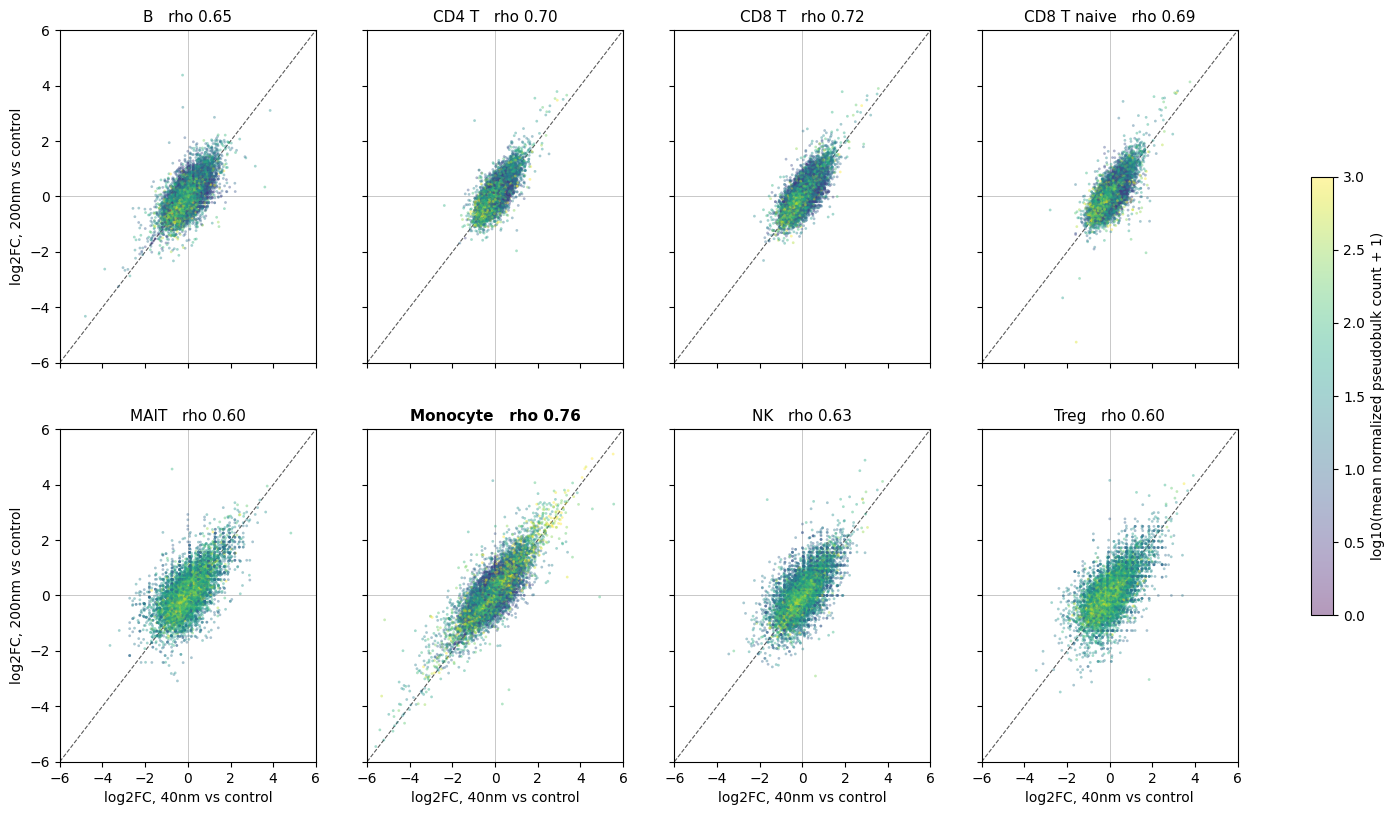

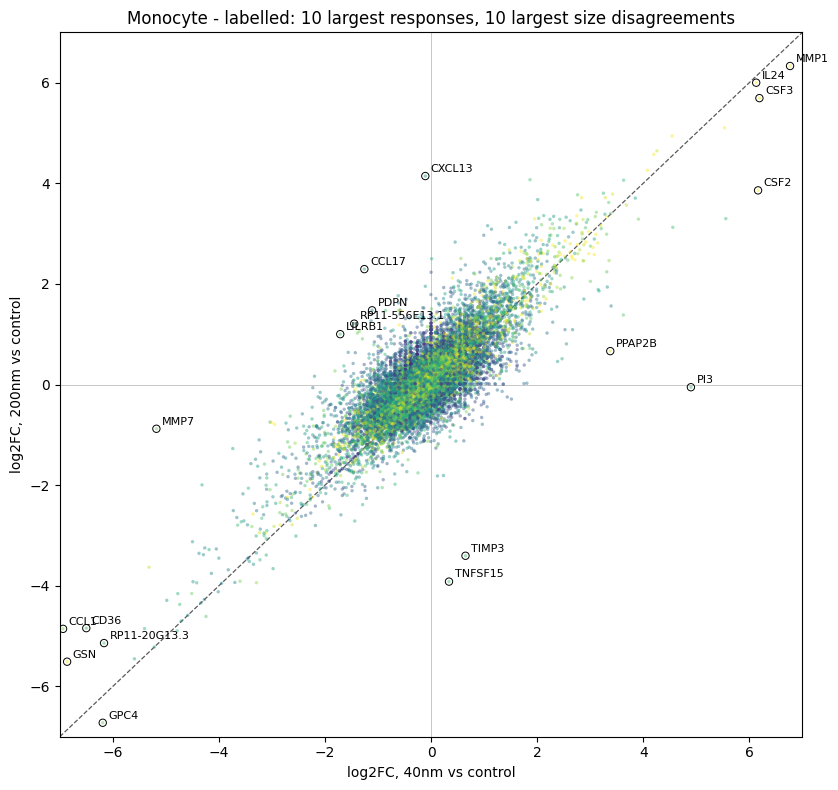

monocyte genes furthest off the diagonal (|lfc| > 1 in at least one size)
               40nm  200nm  diff
PI3            4.90  -0.05  4.95
MMP7          -5.18  -0.88 -4.30
TNFSF15        0.34  -3.92  4.25
CXCL13        -0.11   4.14 -4.25
TIMP3          0.65  -3.40  4.05
CCL17         -1.26   2.29 -3.55
PPAP2B         3.38   0.66  2.71
LILRB1        -1.71   1.00 -2.71
RP11-556E13.1 -1.45   1.21 -2.66
PDPN          -1.11   1.48 -2.59
TLR8           0.01   2.50 -2.49
RASSF4        -3.74  -1.27 -2.47


In [71]:
# Item 2: the joint distribution the categorical table will later be extracted from. A Venn
# reports four counts; this reports the data those counts came from, so a reader can see
# whether "40nm-specific" is an off-diagonal cloud or just diagonal scatter clipped by a box.
#
#   on the y = x diagonal   responds the same to both sizes  -> shared
#   out along the x axis    responds to 40nm only            -> 40nm-specific
#   out along the y axis    -> 200nm-specific        near the origin -> no response
#
# Colour is mean expression, NOT frac_le2. Colouring by frac_le2 was tried and rejected: the
# cell above showed that genome-wide it tracks sparsity rather than contamination, so it would
# paint every lymphocyte panel one colour and invite exactly the misreading it was meant to
# prevent. Expression is the variable that actually separates a measured response from noise.
import matplotlib.pyplot as plt

LIM = 6
fig, axes = plt.subplots(2, 4, figsize=(19, 9.5), sharex=True, sharey=True)
for ax, ct in zip(axes.ravel(), DE_GROUPS):
    d = lfc[ct][['40nm', '200nm']]
    c = np.log10(norm.loc[[f'{ct}|{s}' for s in ['control'] + EXPOSED], d.index].mean() + 1)
    sc_ = ax.scatter(d['40nm'], d['200nm'], c=c, cmap='viridis', vmin=0, vmax=3,
                     s=4, alpha=0.4, linewidths=0)
    ax.plot([-LIM, LIM], [-LIM, LIM], color='0.35', lw=0.8, ls='--', zorder=0)
    ax.axhline(0, color='0.75', lw=0.6, zorder=0)
    ax.axvline(0, color='0.75', lw=0.6, zorder=0)
    r = rho[(rho.cell_type == ct) & (rho.pair == '40nm/200nm')].rho_all.iloc[0]
    ax.set_title(f'{ct}   rho {r:.2f}', fontsize=11,
                 fontweight='bold' if ct == 'Monocyte' else 'normal')
    ax.set(xlim=(-LIM, LIM), ylim=(-LIM, LIM))
for ax in axes[-1]:
    ax.set_xlabel('log2FC, 40nm vs control')
for ax in axes[:, 0]:
    ax.set_ylabel('log2FC, 200nm vs control')
fig.colorbar(sc_, ax=axes, shrink=0.6, label='log10(mean normalized pseudobulk count + 1)')
plt.show()

# Monocytes on their own, labelled. Two gene sets are named: the largest responses, and the
# largest DISAGREEMENTS between the two sizes - which is the Task 6 question read off the plot.
d = lfc['Monocyte'][['40nm', '200nm']]
diff, mag = (d['40nm'] - d['200nm']), d.abs().max(axis=1)
label = set(mag.nlargest(10).index) | set(diff[mag > 1].abs().nlargest(10).index)

fig, ax = plt.subplots(figsize=(8.5, 8))
_e = np.log10(norm.loc[[f'Monocyte|{s}' for s in ['control'] + EXPOSED], d.index].mean() + 1)
ax.scatter(d['40nm'], d['200nm'], c=_e, cmap='viridis', vmin=0, vmax=3,
           s=6, alpha=0.45, linewidths=0)
ax.plot([-7, 7], [-7, 7], color='0.35', lw=0.9, ls='--', zorder=0)
for gene in label:
    ax.annotate(gene, (d.loc[gene, '40nm'], d.loc[gene, '200nm']), fontsize=8,
                xytext=(4, 3), textcoords='offset points')
ax.scatter(d.loc[list(label), '40nm'], d.loc[list(label), '200nm'],
           facecolors='none', edgecolors='k', s=28, linewidths=0.7)
ax.set(xlim=(-7, 7), ylim=(-7, 7), xlabel='log2FC, 40nm vs control',
       ylabel='log2FC, 200nm vs control',
       title='Monocyte - labelled: 10 largest responses, 10 largest size disagreements')
ax.axhline(0, color='0.75', lw=0.6, zorder=0); ax.axvline(0, color='0.75', lw=0.6, zorder=0)
plt.tight_layout(); plt.show()

print('monocyte genes furthest off the diagonal (|lfc| > 1 in at least one size)')
off = pd.DataFrame({'40nm': d['40nm'], '200nm': d['200nm'], 'diff': diff})[mag > 1]
print(off.reindex(off['diff'].abs().sort_values(ascending=False).index)
      .head(12).round(2).to_string())

### Pathways, not genes - and what the heatmap is for

Each NES aggregates ~90 genes, so no single noisy gene can carry a row — the
only averaging available with no replication to average over otherwise.

The asterisk in each cell is the load-bearing mark: colour shows every NES,
the asterisk shows which cells actually cleared **both** FDR < 0.25 and the
ambient line. A strong colour without one is not a result. Read rows by shape:
uniform across all three columns means shared; strong in one column means
size-specific; strong only in mixture means mixture-only.

**Two things worth a second look:** the monocyte panel is full of disease
names (`Malaria`, `Pertussis`, `Rheumatoid arthritis`) that are largely the
same NF-κB/cytokine module under four KEGG labels (Section 14's redundancy
problem again) — not four findings. And `Phagosome` runs **down**,
consistently across all three exposures, in the one cell type that actually
takes up particles — counterintuitive enough to be worth its own look rather
than a sentence.


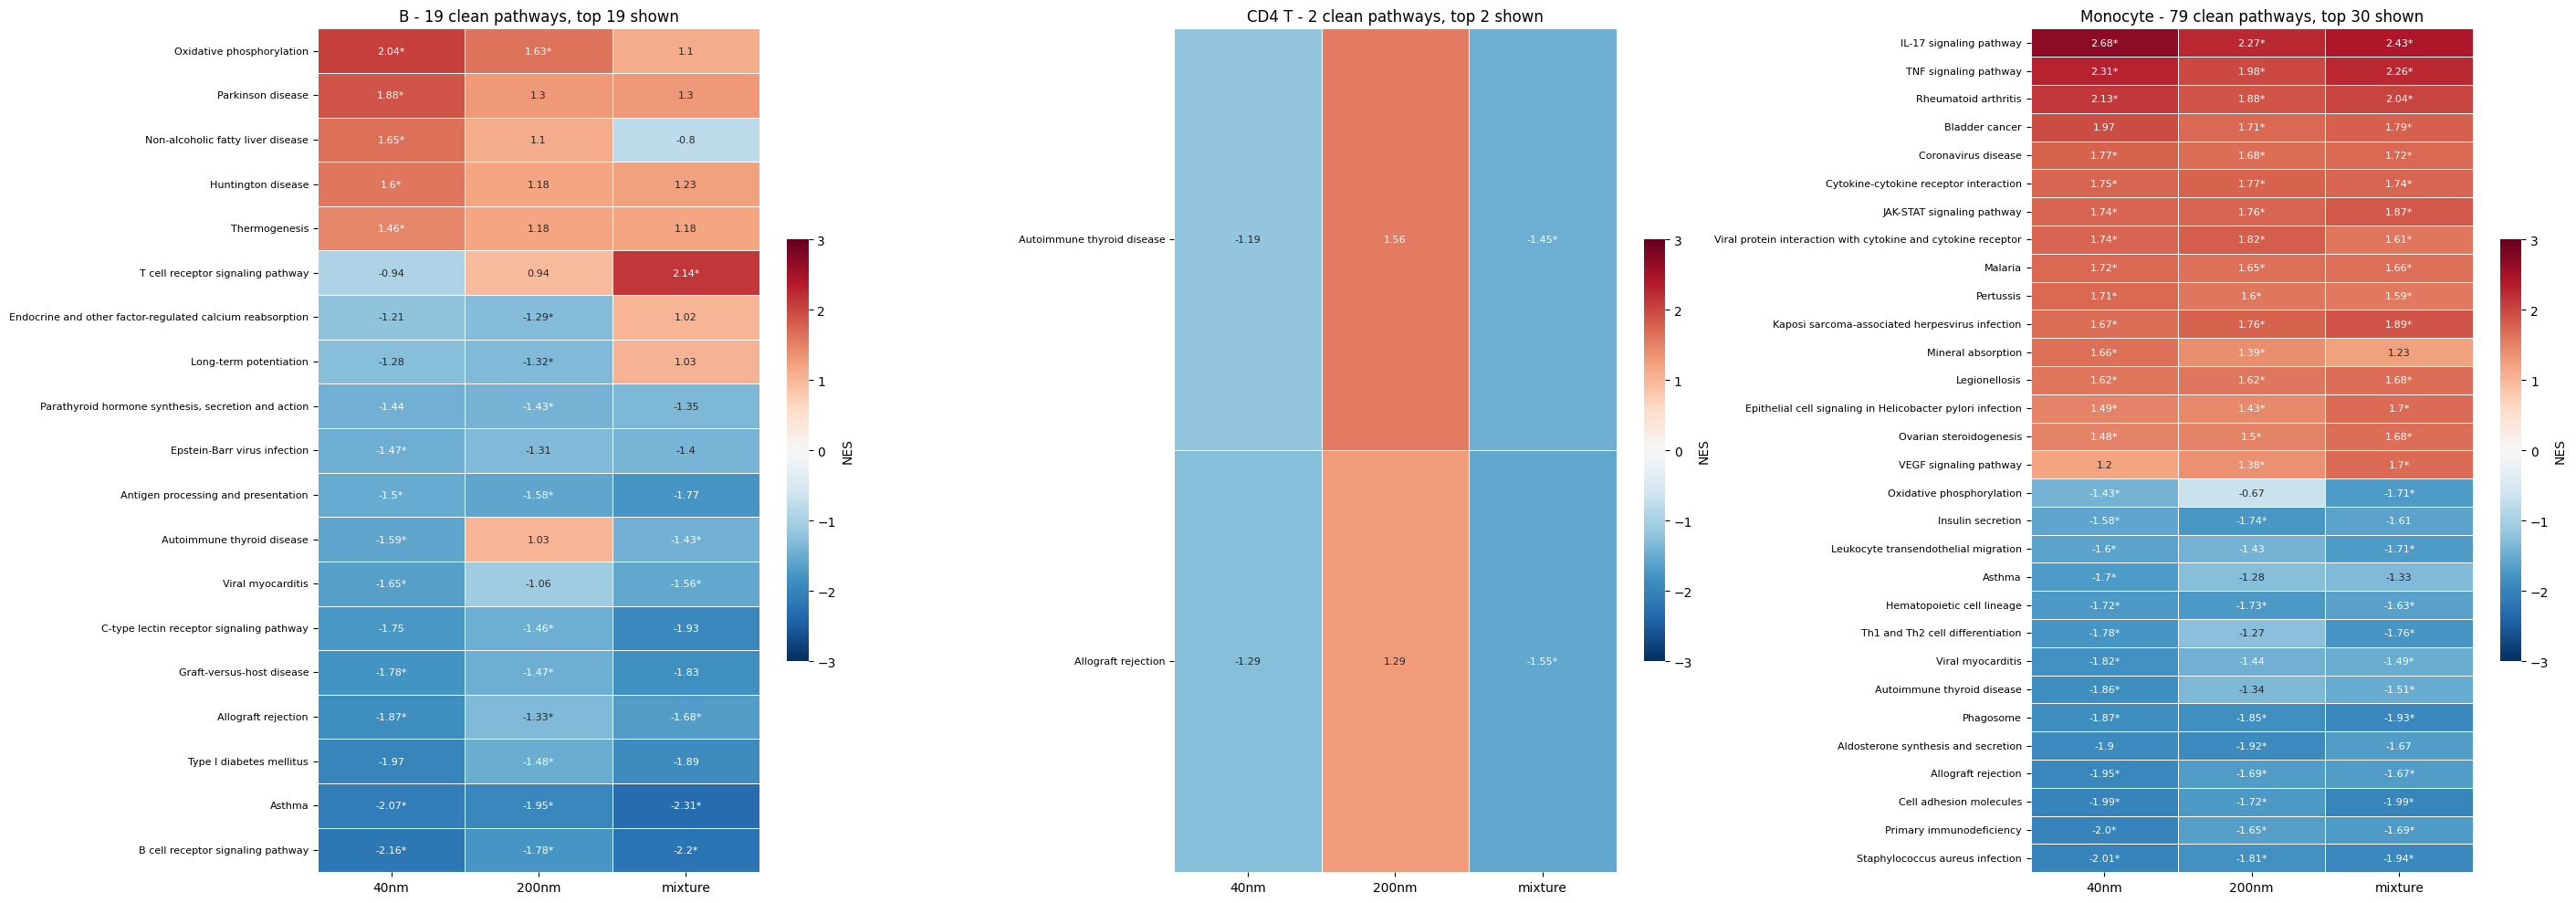

cell types with at least one clean pathway (FDR < 0.25, ambient_frac <= 0.5): ['B', 'CD4 T', 'Monocyte']
the other 5 have none - Section 14 established their significant pathways are all ambient-driven

B: 19 clean pathways, NES spread across the three exposures - median 0.49, 90th pct 2.48
contrast                                                   40nm  200nm  mixture
pathway                                                                        
T cell receptor signaling pathway                         -0.94   0.94     2.14
Autoimmune thyroid disease                                -1.59   1.03    -1.43
Non-alcoholic fatty liver disease                          1.65   1.10    -0.80
Long-term potentiation                                    -1.28  -1.32     1.03
Endocrine and other factor-regulated calcium reabsorption -1.21  -1.29     1.02 

CD4 T: 2 clean pathways, NES spread across the three exposures - median 2.93, 90th pct 3.00
contrast                    40nm  200nm  mixture
pathw

In [72]:
# Item 3: Task 6 read off pathways rather than genes. Each NES aggregates ~90 genes, so no
# single noisy gene can carry a row - which matters more here than usual, because Section 13
# has no replication to average over. FDR and ambient_frac come attached from Section 14.
#
#   a row strong across all three columns   -> shared, both sizes trigger it
#   strong in one column only               -> size-specific
#   strong in the mixture column only       -> mixture-only (pursued properly in Section 16)
import seaborn as sns

TOP_N = 30   # rows per panel, by largest |NES|; the full table is in `gsea`


def nes_panel(ct, ax):
    d = gsea[gsea.cell_type == ct]
    ok = (d.FDR < FDR_CUT) & (d.ambient_frac <= CLEAN)
    keep = d.loc[ok, 'pathway'].unique()
    if len(keep) == 0:
        ax.text(0.5, 0.5, f'{ct}\nno clean pathway at FDR < {FDR_CUT}', ha='center',
                va='center', fontsize=11); ax.axis('off'); return 0
    sub = d[d.pathway.isin(keep)]
    m = sub.pivot(index='pathway', columns='contrast', values='NES').reindex(columns=EXPOSED)
    flag = sub.assign(ok=ok[sub.index]).pivot(index='pathway', columns='contrast',
                                              values='ok').reindex(columns=EXPOSED)
    m = m.loc[m.abs().max(axis=1).nlargest(TOP_N).index].sort_values(EXPOSED[0], ascending=False)
    flag = flag.loc[m.index]
    # The asterisk is the honest part: colour shows every NES, the marker shows which cells
    # actually cleared FDR *and* the ambient line. A strong colour without one is not a result.
    ann = m.round(2).astype(str) + np.where(flag.fillna(False), '*', '')
    sns.heatmap(m, ax=ax, cmap='RdBu_r', center=0, vmin=-3, vmax=3, annot=ann, fmt='',
                annot_kws={'fontsize': 8}, cbar_kws={'label': 'NES', 'shrink': 0.5},
                linewidths=0.4, linecolor='white')
    ax.set(xlabel='', ylabel='', title=f'{ct} - {len(keep)} clean pathways, top {len(m)} shown')
    ax.tick_params(axis='y', labelsize=8, rotation=0)
    return len(keep)


HAVE = [ct for ct in DE_GROUPS
        if ((gsea.cell_type == ct) & (gsea.FDR < FDR_CUT)
            & (gsea.ambient_frac <= CLEAN)).any()]
fig, axes = plt.subplots(1, len(HAVE), figsize=(9.5 * len(HAVE), 10))
for ax, ct in zip(np.atleast_1d(axes), HAVE):
    nes_panel(ct, ax)
plt.tight_layout(); plt.show()

print(f'cell types with at least one clean pathway (FDR < {FDR_CUT}, ambient_frac <= {CLEAN}): '
      f'{HAVE}')
print(f'the other {len(DE_GROUPS) - len(HAVE)} have none - Section 14 established their '
      f'significant pathways are all ambient-driven\n')

# The row shape, as a number: how uniform is each pathway across the three exposures?
for ct in HAVE:
    d = gsea[gsea.cell_type == ct]
    keep = d.loc[(d.FDR < FDR_CUT) & (d.ambient_frac <= CLEAN), 'pathway'].unique()
    m = d[d.pathway.isin(keep)].pivot(index='pathway', columns='contrast',
                                      values='NES').reindex(columns=EXPOSED)
    spread = (m.max(axis=1) - m.min(axis=1))
    print(f'{ct}: {len(m)} clean pathways, NES spread across the three exposures - '
          f'median {spread.median():.2f}, 90th pct {spread.quantile(0.9):.2f}')
    print(m.loc[spread.nlargest(5).index].round(2).to_string(), '\n')

### The categorical table, and why the sweep is the error bar

Task 6 asks for four labels, so they're produced — last, from pathways, with
the cutoffs visible rather than buried.

A conventional paper writes "12 pathways are 40nm-specific (FDR < 0.25)" and
moves on. That sentence is unavailable here — with n=1 per condition there's
no p-value on a **category count**. What's available is how fast that 12
moves when the cutoffs move. A category that holds across the whole grid is a
result; one that appears in a single cell of the grid is an artifact of where
the line was drawn. The sweep below isn't a robustness appendix — it's this
section's substitute for a confidence interval, and belongs in the report
next to the count it qualifies.


In [73]:
# Item 5: the categorical table Task 6 literally asks for - built last, and with its cutoffs on
# display. Everything above answered the question continuously; this converts that into the
# four labels the task names, which cannot be done without a threshold.
def responds(d, fdr, nes_floor):
    """Per row of `gsea`: does this pathway respond in this contrast, at these cutoffs?"""
    return (d.FDR < fdr) & (d.ambient_frac <= CLEAN) & (d.NES.abs() >= nes_floor)


def categorise(nes, hit):
    """One pathway in one cell type -> one Task 6 label.

    nes   Series of NES, indexed by EXPOSED = ['40nm', '200nm', 'mixture']
    hit   bool Series, same index - did it clear FDR, the ambient line and the NES floor there

    Returns a short label string. Rows labelled 'none' are dropped before counting.

    Three decisions are made here rather than defaulted:

    DIRECTION IS PART OF THE ANSWER. `hit` is built from |NES|, so a pathway up at 40nm and
    down at 200nm is True in both - and calling that "shared" would invert its meaning. Signs
    that disagree get their own label instead of being averaged away, and the direction is
    carried into every other label so that "shared up" and "shared down" stay separable. The
    monocyte panel is roughly half each (cytokine signalling up, phagosome and OXPHOS down),
    so collapsing them would hide the more interesting half.

    THE PAIRS KEEP THEIR NAMES. Three contrasts give eight hit patterns; Task 6 names four.
    '40nm + 200nm but not mixture' has no name in the task and is not the same claim as
    '40nm + mixture', so the pair is spelled out rather than folded into 'shared' (which would
    overstate) or dropped (which would hide it).

    THE ORDER IS CANONICAL. Contrasts are read in EXPOSED order, so a pair is always written
    '40nm + 200nm' and never '200nm + 40nm'. The label is the row index of the sensitivity
    sweep below; a name that varied with cutoff would split one row into two.
    """
    on = [s for s in EXPOSED if bool(hit[s])]
    if not on:
        return 'none'
    if len({np.sign(nes[s]) for s in on}) > 1:
        return 'mixed direction'
    d = 'up' if nes[on[0]] > 0 else 'down'
    if len(on) == 3:
        return f'shared {d}'
    return f'{" + ".join(on)} only, {d}'


def task6_table(ct, fdr=FDR_CUT, nes_floor=1.5):
    d = gsea[gsea.cell_type == ct].assign(hit=lambda x: responds(x, fdr, nes_floor))
    NES = d.pivot(index='pathway', columns='contrast', values='NES').reindex(columns=EXPOSED)
    HIT = (d.pivot(index='pathway', columns='contrast', values='hit')
           .reindex(columns=EXPOSED).fillna(False))
    return pd.Series({p: categorise(NES.loc[p], HIT.loc[p]) for p in NES.index}, name='category')


NES_FLOOR = 1.5
for ct in HAVE:
    cat = task6_table(ct, FDR_CUT, NES_FLOOR)
    cat = cat[cat != 'none']
    print(f'\n{ct} - Task 6 categories at FDR < {FDR_CUT}, |NES| >= {NES_FLOOR}, '
          f'ambient_frac <= {CLEAN}')
    print(cat.value_counts().to_string() if len(cat) else '  (nothing clears these cutoffs)')

# The sweep is the error bar. With no replication there is no p-value on "12 pathways are
# 40nm-specific"; what there is, is how fast that 12 moves when the cutoffs move. A category
# that survives the whole grid is a result; one that appears in a single cell of it is not.
print(f'\n{"=" * 78}\nsensitivity: Monocyte category counts across the cutoff grid')
sweep = {}
for fdr in (0.05, 0.10, 0.25):
    for floor in (1.0, 1.5, 2.0):
        c = task6_table('Monocyte', fdr, floor)
        sweep[(f'FDR<{fdr}', f'|NES|>={floor}')] = c[c != 'none'].value_counts()
print(pd.DataFrame(sweep).fillna(0).astype(int).to_string())

# And the check that separates a real category from an arithmetic one. For a pathway labelled
# "X only", where did the OTHER two contrasts actually land? Near zero means a genuinely
# size-specific effect. Just under the floor means the label came from the cutoff, not the data
# - a pathway at -1.61 / -1.47 / -1.45 is not 40nm-specific, it is flat with one value that
# happened to clear the line.
print(f'\n{"=" * 78}\nis each category real? Monocyte, at the cutoffs above')
cat = task6_table('Monocyte', FDR_CUT, NES_FLOOR)
keep = cat[cat != 'none']
mono = (gsea[gsea.cell_type == 'Monocyte']
        .pivot(index='pathway', columns='contrast', values='NES').reindex(columns=EXPOSED))
print(f'{"category":<28}{"n":>4}{"NES spread":>12}{"|NES| of non-responders":>26}')
for label in sorted(keep.unique()):
    sub = mono.loc[keep.index[keep == label]]
    below = sub.abs().where(sub.abs() < NES_FLOOR).stack()
    print(f'{label:<28}{len(sub):>4}{(sub.max(axis=1) - sub.min(axis=1)).median():>12.2f}'
          f'{(below.median() if len(below) else float("nan")):>26.2f}')
print(f'\nread against the floor itself, |NES| = {NES_FLOOR}: a non-responder median close to '
      f'it means the split is the cutoff, not the biology')


B - Task 6 categories at FDR < 0.25, |NES| >= 1.5, ambient_frac <= 0.5
category
40nm only, up                3
shared down                  2
40nm + mixture only, down    2
40nm only, down              2
40nm + 200nm only, down      1
40nm + 200nm only, up        1
mixture only, up             1

CD4 T - Task 6 categories at FDR < 0.25, |NES| >= 1.5, ambient_frac <= 0.5
category
mixture only, down    1

Monocyte - Task 6 categories at FDR < 0.25, |NES| >= 1.5, ambient_frac <= 0.5
category
shared up                    12
40nm only, down              10
mixture only, up              8
shared down                   6
200nm only, down              6
40nm + mixture only, down     3
40nm + mixture only, up       2
40nm + 200nm only, down       2
mixture only, down            2
200nm only, up                2
200nm + mixture only, up      1
40nm only, up                 1
40nm + 200nm only, up         1

sensitivity: Monocyte category counts across the cutoff grid
                           

### Task 6, answered — twice, and the two answers disagree

**By expression: shared.** Monocyte pathways move together across all three
exposures — NES spread with a median around 0.26 over 77 clean pathways.
That's not an absence of evidence for size-specificity; it's 77 pathways
actively agreeing. The largest gene-level responses (`MMP1`, `IL24`, `CSF3`,
`CSF2`, all near +6) sit on the diagonal of the scatter above.

**The categorical table proves its own unreliability, which is why it's
built last.** At FDR < 0.25 and |NES| ≥ 1.5 it hands back 37 monocyte
pathways with size-specific labels against 19 shared ones — read alone, that
would be this project's headline. The diagnostic underneath says otherwise:
**every** size-specific category has its "non-responding" contrasts sitting
at a median |NES| of 1.31-1.45, against a floor of 1.5. `Antigen processing
and presentation` is labelled 40nm-specific on -1.61/-1.47/-1.45 — nothing
about it is 40nm-specific; one of its three numbers cleared a line by 0.11
and the other two missed by 0.03. The `shared up` category behaves
differently — 13 pathways, NES spread 0.13, no non-responding contrast to
explain away (`IL-17 signaling` sits at FDR 0.000 in all three exposures).
Had this section opened with the Venn the task's wording invites, it would
have reported 37 size-specific pathways and been wrong about the main
result.

**By composition: size-specific, and directional.** Monocytes fall 1.93pp
at 40nm, rise 3.38pp at 200nm, flat in the mixture. CLR agrees with the raw
percentage points, so closure isn't manufacturing the pattern.

**Neither answer is wrong.** 40nm produces fewer monocytes that are more
activated; 200nm produces more monocytes, also activated; the mixture
leaves the count alone and mounts the full response. Reporting only one
readout — or averaging them — would have said "size-specific" or "shared"
and missed that the effect is both, on different axes.

**The limitation that governs all of it.** One donor, one sample per
condition. Every number here describes *these four samples*; attributing
any of it to particle size in general needs replication this experiment
doesn't have. The sweep above quantifies how fragile the categorical claims
are; nothing quantifies the donor-level generalization, because nothing can.


In [74]:
# Item 6: the same Task 6 question put to composition instead of expression, in its own table
# because it returns a DIFFERENT answer. Recomputed here from obs rather than reusing Section
# 12's `pct`, so this section holds to the same resume contract as Section 13.
ORDER = ['control'] + EXPOSED
cnt = (adata.obs[adata.obs['cell_type_coarse'] != 'Exclude']
       .groupby(['cell_type', 'Sample'], observed=True).size().unstack(fill_value=0)
       .reindex(columns=ORDER))
pct15 = 100 * cnt / cnt.sum()
comp_pp = pct15[EXPOSED].sub(pct15['control'], axis=0)

# CLR alongside the raw difference, because composition is closed: one type rising forces every
# other down, so a percentage-point change is not attributable to the type it appears in.
_clr = np.log(pct15).sub(np.log(pct15).mean(), axis=1)
comp_clr = _clr[EXPOSED].sub(_clr['control'], axis=0)

print('composition shift vs control, percentage points')
print(comp_pp.round(2).sort_values('200nm').to_string())
print('\nsame shift in CLR units (closure-corrected)')
print(comp_clr.round(2).sort_values('200nm').to_string())

# The dissociation, in one table. This is the section's headline and the reason Tasks 4 and 5
# are kept apart: the two readouts disagree about whether the effect is size-specific.
head = ['IL-17 signaling pathway', 'TNF signaling pathway']
act = (gsea[(gsea.cell_type == 'Monocyte') & gsea.pathway.isin(head)]
       .pivot(index='pathway', columns='contrast', values='NES').reindex(columns=EXPOSED))
diss = pd.concat([
    comp_pp.loc[['Monocyte']].rename(index={'Monocyte': 'proportion, pp vs control'}),
    comp_clr.loc[['Monocyte']].rename(index={'Monocyte': 'proportion, CLR vs control'}),
    act.rename(index=lambda s: f'activation, NES  {s.replace(" signaling pathway", "")}')])
print('\nMONOCYTES - composition and expression answer Task 6 differently')
print(diss.round(2).to_string())

composition shift vs control, percentage points
Sample          40nm  200nm  mixture
cell_type                           
CD4 T naive    -2.37  -2.72    -4.14
CD8 T effector -2.11  -1.71     0.36
B memory       -2.08  -1.49     0.91
NK             -0.56  -1.03     0.04
B naive        -0.61   0.24     1.39
Basophil        0.32   0.31     0.43
MAIT           -0.17   0.49     0.43
Treg            0.86   0.50     0.26
CD4 T memory    1.32   0.74     1.38
CD8 T naive     7.33   1.28    -0.88
Monocyte       -1.93   3.38    -0.17

same shift in CLR units (closure-corrected)
Sample          40nm  200nm  mixture
cell_type                           
B memory       -0.59  -0.48     0.04
NK             -0.08  -0.27    -0.13
CD4 T naive    -0.10  -0.22    -0.35
CD8 T effector -0.10  -0.18    -0.12
CD8 T naive     0.30  -0.03    -0.18
CD4 T memory    0.13  -0.03    -0.02
B naive        -0.15  -0.03     0.16
MAIT           -0.04   0.07     0.00
Treg            0.29   0.08    -0.05
Monocyte       -0.4

## Section 16 — per-cell signature scoring (addition, not core)

Section 15 delivered Task 6; everything from here is an **addition**, not part
of the core tasks.

Sections 13-14 collapse every cell to one pseudobulk column before testing, so
they can't see variation *within* a cell type. `sc.tl.score_genes` gives every
cell its own value against an expression-matched control gene set (Tirosh et
al. 2016), making one specific question askable: **particle uptake is
stochastic, so is the monocyte response bimodal?** — direct evidence of an
uptake-dependent response that no pseudobulk method could show even in
principle. Scored on `.X`, permanently log-normalized/unscaled since Section
7 — `score_genes`'s expression-matched binning is meaningless on scaled data.

**A panel, not a single gene set:** Enrichr's `TNF-alpha Signaling via NF-kB`
contains no `CXCL8`/`IL8` at all — the gene at the top of this project's most
interesting result actually lives in `Inflammatory Response` instead, so a
single named set would have missed it.


In [75]:
# Gene sets for scoring. KEGG is already fetched, symbol-mapped and size-filtered by
# Section 14, so only Hallmark needs a fetch - same urllib route and the same reason
# (gseapy.get_library fails here with an SSL certificate error).
with urllib.request.urlopen(ENRICHR + 'MSigDB_Hallmark_2020', timeout=90) as fh:
    _h = fh.read().decode().strip().split('\n')
hallmark_raw = {p[0]: [x for x in p[1:] if x] for p in (r.split('\t') for r in _h)}
print(f'MSigDB_Hallmark_2020: {len(hallmark_raw)} sets, fetched {date.today()}')

# Four Hallmark sets plus two KEGG. TNFA is the set CLAUDE.md names; Inflammatory Response is
# added because it, not TNFA, is where CXCL8/IL8 actually lives; the interferon pair and the
# two KEGG sets are the Melms et al. 2021 immune panel (type I IFN, inflammasome, chemotaxis).
SIG_SPEC = {
    'TNFA_NFKB':    ('hallmark', 'TNF-alpha Signaling via NF-kB'),
    'Inflammatory': ('hallmark', 'Inflammatory Response'),
    'IFN_alpha':    ('hallmark', 'Interferon Alpha Response'),
    'IFN_gamma':    ('hallmark', 'Interferon Gamma Response'),
    'Inflammasome': ('kegg',     'NOD-like receptor signaling pathway'),
    'Chemokine':    ('kegg',     'Chemokine signaling pathway'),
}
_ours = set(adata.var_names)
SIGS = {}
print(f'\n{"signature":<14}{"in set":>8}{"raw":>6}{"mapped":>8}{"gain":>6}  recovered by SYMBOL_MAP')
for tag, (src, key) in SIG_SPEC.items():
    genes = hallmark_raw[key] if src == 'hallmark' else kegg_raw[key]
    raw = set(genes) & _ours
    mapped = {SYMBOL_MAP.get(g, g) for g in genes} & _ours
    SIGS[tag] = sorted(mapped)
    print(f'{tag:<14}{len(genes):>8}{len(raw):>6}{len(mapped):>8}{len(mapped) - len(raw):>6}  '
          f'{sorted(mapped - raw)[:5]}')
    assert len(mapped) >= 15, f'{tag} has too few genes to score'

# The point of printing the gain: without SYMBOL_MAP, IL8 is silently absent from three of
# these six sets and the scores would be reported over whatever happened to match, unflagged.
_il8 = [t for t, g in SIGS.items() if 'IL8' in g]
print(f'\nsets containing IL8 after mapping: {_il8}')
print(f'IL8 in TNFA_NFKB: {"IL8" in SIGS["TNFA_NFKB"]}  '
      f'(PLAN.md said Hallmark TNFA contains CXCL8 - it does not, in this library)')

MSigDB_Hallmark_2020: 50 sets, fetched 2026-09-01

signature       in set   raw  mapped  gain  recovered by SYMBOL_MAP
TNFA_NFKB          200   197     198     1  ['PPAP2B']
Inflammatory       200   187     190     3  ['EMR1', 'IL8', 'VIMP']
IFN_alpha           97    94      96     2  ['FAM46A', 'WARS']
IFN_gamma          200   195     197     2  ['MARCH1', 'WARS']
Inflammasome       181   147     152     5  ['DEF6', 'ERBB2IP', 'IL8', 'POP1', 'TMEM173']
Chemokine          192   167     173     6  ['ADRBK1', 'ADRBK2', 'IL8', 'SCYL1', 'SCYL2']

sets containing IL8 after mapping: ['Inflammatory', 'Inflammasome', 'Chemokine']
IL8 in TNFA_NFKB: False  (PLAN.md said Hallmark TNFA contains CXCL8 - it does not, in this library)


In [76]:
# Score every cell against every signature. random_state fixed: the control gene set is
# sampled from expression-matched bins, so the score is not deterministic without it.
for tag, genes in SIGS.items():
    sc.tl.score_genes(adata, genes, score_name=f'sig_{tag}', random_state=0)

print('median score by coarse cell type x sample\n')
for tag in ['TNFA_NFKB', 'Inflammatory']:
    t = (adata.obs.groupby(['cell_type_coarse', 'Sample'], observed=True)[f'sig_{tag}']
         .median().unstack())
    print(f'--- {tag} ---')
    print(t.round(3).to_string())
    print()

# The ambient diagnostic, beside the scores rather than instead of them - Section 13 showed a
# myeloid inflammatory program appears in every lymphocyte because free mRNA from lysed cells
# is captured in every droplet. A lymphocyte's inflammatory score is partly that soup, so the
# share of each signature's genes that look ambient IN THAT CELL TYPE has to travel with it.
print('share of each signature\'s genes flagged ambient (frac_le2 > 0.7), by cell type')
rows = {}
for ct in DE_GROUPS:
    st = AMB[ct]
    rows[ct] = {tag: float((st.loc[g, 'frac_le2'] > 0.7).mean())
                for tag, g in SIGS.items()}
print(pd.DataFrame(rows).T.round(2).to_string())
print('\nMonocytes are the only cell type where these scores are not mostly soup.')

median score by coarse cell type x sample

--- TNFA_NFKB ---
Sample             40nm  200nm  control  mixture
cell_type_coarse                                
B                 0.081  0.099    0.092    0.094
Basophil          0.156  0.167    0.174    0.168
CD4 T             0.087  0.099    0.083    0.083
CD8 T             0.115  0.123    0.101    0.111
CD8 T naive       0.067  0.074    0.060    0.059
Exclude           0.048  0.081    0.052    0.045
MAIT              0.131  0.151    0.121    0.135
Monocyte          0.613  0.628    0.407    0.643
NK                0.131  0.153    0.126    0.133
Treg              0.080  0.105    0.080    0.074

--- Inflammatory ---
Sample             40nm  200nm  control  mixture
cell_type_coarse                                
B                 0.028  0.042    0.034    0.033
Basophil          0.113  0.119    0.113    0.097
CD4 T             0.023  0.037    0.023    0.020
CD8 T             0.044  0.052    0.036    0.044
CD8 T naive       0.008  0.019    0

### The bimodality question, and the control that answers it

Five of six signatures return a better two-component than one-component fit
inside monocytes — read alone, that's the result this section was built to
find (stochastic uptake producing responder/non-responder monocytes).

**It's wrong, and the control below shows it.** A mixture model doesn't know
where a cell came from — pool one population centred low with three centred
high and the pooled distribution is bimodal regardless of what's happening
inside each one. So the fit has to be repeated **within each sample
separately**.


In [77]:
from sklearn.mixture import GaussianMixture

def _fit2(x):
    """1- vs 2-component BIC, plus how far apart the two components actually sit."""
    x = np.asarray(x).reshape(-1, 1)
    b1 = GaussianMixture(1, random_state=0).fit(x).bic(x)
    m2 = GaussianMixture(2, random_state=0).fit(x)
    mu, sd, w = m2.means_.ravel(), np.sqrt(m2.covariances_.ravel()), m2.weights_
    sep = abs(mu[1] - mu[0]) / np.sqrt((sd ** 2).mean())
    return b1, m2.bic(x), sep, min(w), m2, int(np.argmax(mu))

# Two components are only two MODES if they are also separated and both carry real weight.
# BIC alone will prefer 2 components for any skewed unimodal distribution.
SEP_MIN, W_MIN = 2.0, 0.10
_m = (adata.obs['cell_type_coarse'] == 'Monocyte').to_numpy()
print(f'all {_m.sum():,} monocytes pooled')
print(f'{"signature":<14}{"BIC 1":>9}{"BIC 2":>9}{"sep(SD)":>9}{"min w":>7}  verdict')
for tag in SIGS:
    b1, b2, sep, wmin, _, _ = _fit2(adata.obs.loc[_m, f'sig_{tag}'])
    ok = b2 < b1 - 10 and sep > SEP_MIN and wmin > W_MIN
    print(f'{tag:<14}{b1:>9.0f}{b2:>9.0f}{sep:>9.2f}{wmin:>7.2f}  '
          f'{"two modes" if ok else "one mode (skew)"}')

# THE CONTROL. Assign each monocyte to the high or low component of the pooled fit, then ask
# where those cells came from.
TAG = 'sig_TNFA_NFKB'
_, _, _, _, gm, hi = _fit2(adata.obs.loc[_m, TAG])
_mode = gm.predict(adata.obs.loc[_m, [TAG]].to_numpy())
_by = pd.DataFrame({'Sample': adata.obs.loc[_m, 'Sample'].to_numpy(), 'high': _mode == hi})
print(f'\nshare of monocytes in the HIGH mode, per sample ({TAG})')
print((_by.groupby('Sample', observed=True)['high'].agg(['size', 'mean'])
       .rename(columns={'size': 'monocytes', 'mean': 'high_share'}).round(3)).to_string())

print('\nand the same fit WITHIN each sample on its own')
print(f'{"sample":<10}{"n":>6}{"BIC 1":>9}{"BIC 2":>9}{"sep(SD)":>9}  verdict')
for s, d in adata.obs.loc[_m].groupby('Sample', observed=True):
    if len(d) < 60:
        continue
    b1, b2, sep, wmin, _, _ = _fit2(d[TAG])
    ok = b2 < b1 - 10 and sep > SEP_MIN and wmin > W_MIN
    print(f'{s:<10}{len(d):>6}{b1:>9.0f}{b2:>9.0f}{sep:>9.2f}  '
          f'{"two modes" if ok else "one mode"}')

all 1,649 monocytes pooled
signature         BIC 1    BIC 2  sep(SD)  min w  verdict
TNFA_NFKB         -1423    -1508     2.31   0.36  two modes
Inflammatory      -2493    -2700     2.60   0.34  two modes
IFN_alpha         -4119    -4167     1.64   0.39  one mode (skew)
IFN_gamma         -4176    -4160     1.17   0.37  one mode (skew)
Inflammasome      -4043    -4197     2.49   0.32  two modes
Chemokine         -3801    -3867     2.10   0.36  two modes

share of monocytes in the HIGH mode, per sample (sig_TNFA_NFKB)
         monocytes  high_share
Sample                        
200nm          900       0.759
40nm           221       0.747
control        279       0.226
mixture        249       0.779

and the same fit WITHIN each sample on its own
sample         n    BIC 1    BIC 2  sep(SD)  verdict
40nm         221     -233     -226     1.33  one mode
200nm        900     -995    -1038     1.96  one mode
control      279     -317     -318     1.78  one mode
mixture      249     -245    

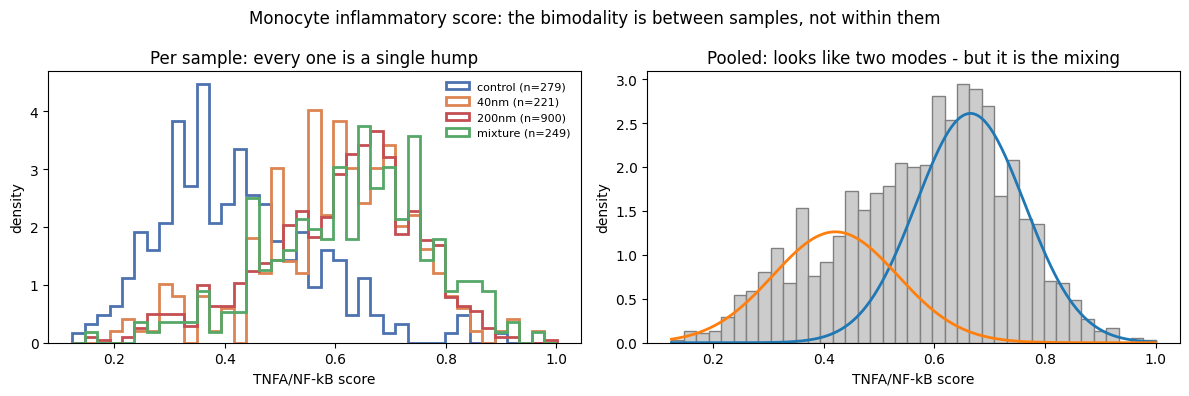

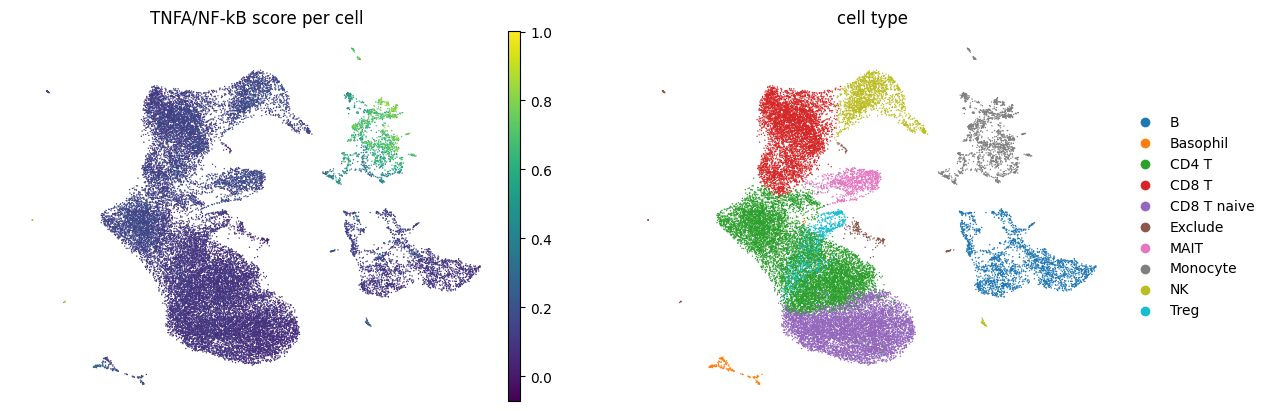

In [78]:
# The figure the bimodality argument actually rests on. The BIC table above states the result;
# shape is what the claim is ABOUT, so it needs to be visible.
#
# Left: monocyte scores per sample. Right: the same cells pooled, with the two-component fit
# drawn on top. The right panel is what "bimodal" was read from; the left panel is why that
# reading is wrong - the two humps are control versus the three exposures, and each sample on
# its own is a single hump.
TAG = 'sig_TNFA_NFKB'
_mono = adata.obs.loc[adata.obs['cell_type_coarse'] == 'Monocyte', [TAG, 'Sample']]
_bins = np.linspace(_mono[TAG].min(), _mono[TAG].max(), 40)
_order = ['control', '40nm', '200nm', 'mixture']
_cols = {'control': '#4c72b0', '40nm': '#dd8452', '200nm': '#c44e52', 'mixture': '#55a868'}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for s in _order:
    v = _mono.loc[_mono['Sample'] == s, TAG]
    axes[0].hist(v, bins=_bins, density=True, histtype='step', lw=2,
                 color=_cols[s], label=f'{s} (n={len(v):,})')
axes[0].set(xlabel='TNFA/NF-kB score', ylabel='density',
            title='Per sample: every one is a single hump')
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(_mono[TAG], bins=_bins, density=True, color='0.8', edgecolor='0.5')
_x = np.linspace(_bins[0], _bins[-1], 400)
_gm = GaussianMixture(2, random_state=0).fit(_mono[[TAG]].to_numpy())
for _mu, _var, _w in zip(_gm.means_.ravel(), _gm.covariances_.ravel(), _gm.weights_):
    axes[1].plot(_x, _w * np.exp(-(_x - _mu) ** 2 / (2 * _var)) / np.sqrt(2 * np.pi * _var),
                 lw=2)
axes[1].set(xlabel='TNFA/NF-kB score', ylabel='density',
            title='Pooled: looks like two modes - but it is the mixing')
fig.suptitle('Monocyte inflammatory score: the bimodality is between samples, not within them')
fig.tight_layout()
plt.show()

# Where the response sits on the map. Monocytes are one small island, and the score is high
# there and nowhere else - the myeloid-not-lymphocyte expectation, as a picture.
sc.pl.umap(adata, color=[TAG, 'cell_type_coarse'], ncols=2, frameon=False,
           title=['TNFA/NF-kB score per cell', 'cell type'])


In [79]:
# Cell cycle, the one-call extra - and a check on what the call is worth. scanpy assigns a
# phase by argmax of the S and G2M scores and only returns G1 when BOTH are negative, so a
# cell with a G2M score of +0.001 is labelled G2M. On resting PBMCs that is a machine for
# manufacturing proliferation that is not there.
S_GENES = [g for g in ['MCM5','PCNA','TYMS','FEN1','MCM2','RRM2','UNG','GINS2','MCM6','CDCA7',
    'RRM1','UHRF1','CDC6','CDC45','CLSPN','GMNN','WDR76','SLBP','CCNE2','UBR7','POLD3','MSH2',
    'ATAD2','RAD51','EXO1','TIPIN','DSCC1','BLM','CASP8AP2','USP1','CHAF1B'] if g in _ours]
G2M_GENES = [g for g in ['HMGB2','CDK1','NUSAP1','UBE2C','BIRC5','TPX2','TOP2A','NDC80','CKS2',
    'NUF2','CKS1B','MKI67','TMPO','CENPF','TACC3','SMC4','CCNB2','CKAP2','AURKB','BUB1','KIF11',
    'ANP32E','GTSE1','KIF20B','HJURP','CDCA3','CDC20','TTK','CDC25C','KIF2C','RANGAP1','NCAPD2',
    'DLGAP5','CDCA2','CDCA8','ECT2','KIF23','HMMR','AURKA','PSRC1','ANLN','LBR','CKAP5','CENPE',
    'CTCF','NEK2','G2E3','GAS2L3','CBX5','CENPA'] if g in _ours]
sc.tl.score_genes_cell_cycle(adata, s_genes=S_GENES, g2m_genes=G2M_GENES, random_state=0)
print(f'S {len(S_GENES)} genes, G2M {len(G2M_GENES)} genes')
print(adata.obs['phase'].value_counts().to_string())

print('\nscore magnitudes behind those calls')
print(adata.obs[['S_score', 'G2M_score']].describe().loc[['50%', 'max']].round(4).to_string())

# The clustering-independent check: are the canonical proliferation markers actually there?
print('\ncanonical proliferation markers across all 29,157 cells')
print(f'{"gene":<8}{"% detected":>12}{"cells >=5 counts":>18}')
for g in ['MKI67', 'TOP2A', 'CDK1', 'BIRC5', 'TYMS']:
    if g not in _ours:
        continue
    raw = adata.layers['counts'][:, adata.var_names.get_loc(g)].toarray().ravel()
    print(f'{g:<8}{100 * (raw > 0).mean():>11.2f}%{int((raw >= 5).sum()):>18}')

S 29 genes, G2M 50 genes
phase
G2M    10975
G1     10180
S       8002

score magnitudes behind those calls
     S_score  G2M_score
50%  -0.0188    -0.0029
max   0.7348     0.6276

canonical proliferation markers across all 29,157 cells
gene      % detected  cells >=5 counts
MKI67          0.17%                 9
TOP2A          0.76%                 7
CDK1           0.39%                 2
BIRC5          0.13%                 8
TYMS           0.86%                12


### What Section 16 found

**The monocyte response is uniform across all three exposures, measured per
cell.** Share of monocytes in the high-activation mode: control 0.23 against
0.75/0.76/0.78 for 40nm/200nm/mixture. That's Section 14's uniform NES and
Section 15's "shared by expression" conclusion arriving again from a
completely different direction — per-cell scores instead of a pseudobulk
ranking — the strongest corroboration in the notebook.

**No evidence of uptake-dependent heterogeneity — a real answer, not a
failure to find one.** The pooled bimodality is entirely *between* samples:
no individual sample is bimodal on its own. The two modes are "exposed" vs.
"unexposed," not "took up particles" vs. "did not."

**No proliferating cells, confirmed by markers rather than the phase call.**
`MKI67` detected in 0.17% of cells (9 cells with 5+ counts), `TOP2A` 7 cells,
`CDK1` 2 — yet the phase assignment labels ~37% of cells G2M, on median
scores of -0.003. That's `sc.tl.score_genes_cell_cycle` picking a phase by
argmax even when both scores are essentially noise around zero — a one-line
step manufacturing an artifact, and it must not be reported as biology.


## Section 17 — does the result need batch correction? (addition)

Section 8 chose scanorama and measured both sides of its tradeoff, but that
measured *the correction*, not *the dependence of the findings on it*. This
section asks bluntly: drop batch correction entirely — do the conclusions
change?

It stopped being hypothetical once this notebook was made reproducible.
Sections 1-7 give bit-identical results on Windows and Linux; Section 8 does
not, because scanorama's `nn_approx` builds an `AnnoyIndex` without seeding
it, so alignment scores differ in the third decimal between platforms —
enough to move Leiden from 15 clusters to 17. A result that depended on
scanorama's exact output would be a result that depended on the machine it
ran on.

Section 8 deliberately preserved `X_pca_sel` (the uncorrected 30-PC
embedding) for exactly this. The uncorrected graph is built under its own
`key_added`, so Section 9's corrected graph is left intact.


In [80]:
from sklearn.metrics import adjusted_rand_score

# key_added / neighbors_key keep this graph separate. Without them sc.pp.neighbors would
# overwrite adata.obsp and adata.uns['neighbors'] in place, silently replacing the corrected
# graph every later section is entitled to assume is still there.
sc.pp.neighbors(adata, use_rep='X_pca_sel', n_neighbors=N_NEIGHBORS, random_state=0,
                key_added='uncorr')
sc.tl.leiden(adata, resolution=RESOLUTION, key_added='leiden_uncorr', neighbors_key='uncorr',
             flavor='igraph', n_iterations=2, directed=False, random_state=0)

_u = adata.obs['leiden_uncorr']
print(f'uncorrected: {_u.nunique()} clusters at resolution {RESOLUTION}   '
      f'corrected: {adata.obs["leiden"].nunique()}')
print(f'ARI(corrected, uncorrected) = '
      f'{adjusted_rand_score(adata.obs["leiden"], _u):.3f}')

# Two different questions, and conflating them is the easy mistake here:
#   RECOVERY - of the cells we call X, what share land in ONE uncorrected cluster?
#              (is the population held together without correction?)
#   PURITY   - of that cluster, what share are actually X?
#              (is it held together WITHOUT absorbing anything else?)
# A population can score 100% recovery and poor purity by being swallowed whole into a bigger
# cluster, which is precisely what happens to the B subsets below.
_tab = pd.crosstab(adata.obs['cell_type'], _u)
MIN_CELLS = 50
rows = []
for c in _tab.index:
    r = _tab.loc[c]
    if r.sum() < MIN_CELLS:
        continue
    k = r.idxmax()
    rows.append({'cell_type': c, 'cells': int(r.sum()), 'main_cluster': k,
                 'recovery': r[k] / r.sum(), 'purity': r[k] / _tab[k].sum()})
RECOVERY = pd.DataFrame(rows).set_index('cell_type')
print(f'\nper cell type, on the UNCORRECTED embedding (>= {MIN_CELLS} cells)')
print(RECOVERY.assign(recovery=lambda d: (100 * d.recovery).round(1),
                      purity=lambda d: (100 * d.purity).round(1)).to_string())

uncorrected: 11 clusters at resolution 0.3   corrected: 17
ARI(corrected, uncorrected) = 0.871

per cell type, on the UNCORRECTED embedding (>= 50 cells)
                cells main_cluster  recovery  purity
cell_type                                           
B memory         1056            8      99.9    45.1
B naive          1220            8     100.0    52.2
Basophil          156           10      98.7    98.7
CD4 T memory     3579            1      97.8    91.6
CD4 T naive      5599            2      90.3    93.0
CD8 T effector   5237            0      96.2    99.2
CD8 T naive      7033            4      94.9    94.0
Doublet            50            8     100.0     2.1
MAIT              891            9      98.5    96.9
Monocyte         1649            7     100.0    98.9
NK               1608            3      98.4    98.6
T unresolved      157            6      77.1   100.0
Treg              911            5      96.6    94.9


In [81]:
# A population is only "recovered without batch correction" if it is both held together AND
# not merged into something else - so the verdict needs both numbers, and a rule for combining
# them. There is no standard threshold here; it is a judgement about how much merging still
# counts as recovering the population.
#
# Two thresholds rather than one, because the two numbers fail in different ways and a single
# combined score would hide which failure occurred.
#
#   recovery < 0.80  -> LOST. The population is split across clusters, so the uncorrected
#                       embedding does not hold it together at all. 0.80 is deliberately
#                       lenient: cluster boundaries always trade a few cells, and we are
#                       asking whether the population exists, not whether it is perfect.
#   purity   < 0.70  -> MERGED. It stays together but sits inside a cluster that is mostly
#                       something else, i.e. it was absorbed by a neighbour rather than
#                       resolved. This is the B memory / B naive case: each is ~100%
#                       recovered into the SAME cluster, so each reads ~50% pure.
#
# Recovery is tested first: a population that has scattered cannot meaningfully be called
# merged into any one thing.
#
# Known bias, not corrected here: purity is structurally harsher on small populations, since
# a fixed number of contaminating cells from a large neighbour costs a rare type a larger
# share. Basophil clears both bars at 156 cells, so the bar is reachable - but read the
# verdict for any small population alongside its cell count rather than on its own.
REC_MIN, PUR_MIN = 0.80, 0.70


def verdict(recovery, purity):
    """One row of RECOVERY -> 'recovered' / 'merged' / 'lost'."""
    if recovery < REC_MIN:
        return 'lost'
    if purity < PUR_MIN:
        return 'merged'
    return 'recovered'


RECOVERY['verdict'] = [verdict(r.recovery, r.purity) for r in RECOVERY.itertuples()]
print('what survives without batch correction')
print(RECOVERY.assign(recovery=lambda d: (100 * d.recovery).round(1),
                      purity=lambda d: (100 * d.purity).round(1)).to_string())

what survives without batch correction
                cells main_cluster  recovery  purity    verdict
cell_type                                                      
B memory         1056            8      99.9    45.1     merged
B naive          1220            8     100.0    52.2     merged
Basophil          156           10      98.7    98.7  recovered
CD4 T memory     3579            1      97.8    91.6  recovered
CD4 T naive      5599            2      90.3    93.0  recovered
CD8 T effector   5237            0      96.2    99.2  recovered
CD8 T naive      7033            4      94.9    94.0  recovered
Doublet            50            8     100.0     2.1     merged
MAIT              891            9      98.5    96.9  recovered
Monocyte         1649            7     100.0    98.9  recovered
NK               1608            3      98.4    98.6  recovered
T unresolved      157            6      77.1   100.0       lost
Treg              911            5      96.6    94.9  recovered


In [82]:
# The test that actually matters. Cluster purity is a proxy; Task 4's monocyte proportion is
# the finding. Recompute it from the uncorrected clustering and compare like for like.
#
# The monocyte cluster is identified the same way Section 10 identifies it - highest CD14
# detection among clusters big enough for the fraction to be stable - rather than by assuming
# any correspondence between the two clusterings' numbering.
_c = sc.get.obs_df(adata, keys=['CD14', 'leiden_uncorr'], layer='normlog')
_f = _c.groupby('leiden_uncorr', observed=True)['CD14'].agg(['size', lambda s: (s > 0).mean()])
_f.columns = ['cells', 'pct_cd14']
_big = _f[_f.cells >= 200]
MONO_UNCORR = _big.pct_cd14.idxmax()
print(f'CD14-highest uncorrected cluster: {MONO_UNCORR} '
      f'({int(_big.loc[MONO_UNCORR, "cells"]):,} cells, CD14 in '
      f'{_big.loc[MONO_UNCORR, "pct_cd14"]:.0%}) vs {int((adata.obs["cell_type_coarse"] == "Monocyte").sum()):,} '
      f'monocytes on the corrected labels')

_un = (adata.obs.assign(m=(_u == MONO_UNCORR))
       .groupby('Sample', observed=True)['m'].mean() * 100)
_co = (adata.obs.assign(m=adata.obs['cell_type_coarse'].eq('Monocyte'))
       .groupby('Sample', observed=True)['m'].mean() * 100)
COMPARE = pd.DataFrame({
    'uncorrected_%': _un.round(2), 'corrected_%': _co.round(2),
    'uncorr_pp_vs_control': (_un - _un['control']).round(2),
    'corr_pp_vs_control': (_co - _co['control']).round(2),
}).reindex(['control', '40nm', '200nm', 'mixture'])
print('\nTask 4\'s monocyte result, with and without scanorama')
print(COMPARE.to_string())

_d = (COMPARE['uncorr_pp_vs_control'] - COMPARE['corr_pp_vs_control']).abs().max()
print(f'\nlargest disagreement between the two: {_d:.2f} percentage points')
assert _d < 0.5, 'the headline moved once correction was dropped - that would be a finding'

CD14-highest uncorrected cluster: 7 (1,668 cells, CD14 in 60%) vs 1,649 monocytes on the corrected labels

Task 4's monocyte result, with and without scanorama
         uncorrected_%  corrected_%  uncorr_pp_vs_control  corr_pp_vs_control
Sample                                                                       
control           5.02         4.94                  0.00                0.00
40nm              3.01         3.00                 -2.01               -1.94
200nm             8.38         8.28                  3.35                3.34
mixture           4.78         4.74                 -0.25               -0.20

largest disagreement between the two: 0.07 percentage points


### What Section 17 found

**The headline does not depend on batch correction at all.** Task 4's
monocyte proportions come back at -2.01/+3.35/-0.25 percentage points
against control on the uncorrected embedding, versus -1.94/+3.34/-0.20 with
scanorama — the largest disagreement anywhere in that table is well under
half a percentage point, and the direction reversal between 40nm and 200nm
(this project's structural finding) is present in both. Combined with the
cross-platform reproduction, the monocyte result has now survived a
different platform, a different scanorama embedding, a different Leiden
partition, an independently re-derived cluster map, and now the removal of
batch correction entirely.

**Monocytes and NK don't need correction; the B subsets do.** Monocytes
come back at 100% recovery and 98.9% purity with no correction at all, NK
at 98.4%/98.6%, and Treg similarly clean (96.6%/94.9%) as its own
uncorrected cluster. `B memory` and `B naive` each land almost entirely in
a single uncorrected cluster — but it's *the same* cluster, giving purity
of only 45%/52%. Splitting them apart is what scanorama actually buys.
Overall agreement is ARI 0.871 on 11 uncorrected clusters against 17
corrected.

**What this does not say.** It does not show correction was unnecessary —
it resolves finer structure and 6 more clusters. It shows the
*conclusions this project draws* rest on structure that is present before
any correction is applied, which is a narrower and more useful claim.


## Section 18 — is the mixture additive? (addition)

The one question the third sample can answer that the other two cannot. Tasks
1-6 treat the mixture as simply a third exposure and compare it to control
like the others — none of them asks what having **both particle sizes at
once** does.

**The anomaly that motivates this:** the mixture contains both particle sizes
yet shows neither component's monocyte composition effect (-0.17pp against
-1.93 and +3.38), and it resembles control *most closely* of the three
exposures on Section 8's alignment scores (0.925) — an additive model doesn't
predict that.

The test: regress the mixture's per-gene fold changes on the two single-size
contrasts, per cell type. Coefficients summing near 1 with a good fit means
the mixture is a blend and adds nothing; the residuals are the
mixture-specific signal, already ranked.


In [83]:
# mixture ~ intercept + b40 * (40nm) + b200 * (200nm), per cell type, on Section 13's fold
# changes. Ribosomal and mitochondrial genes are dropped for Section 14's reason - their share
# tracks sequencing depth, which is confounded with exposure.
#
# NOT soup-filtered. Section 15 established that frac_le2 applied genome-wide removes 97% of a
# lymphocyte's genes, because there it measures sparsity rather than contamination.
def _ols(y, xs):
    """Least squares with intercept. Returns (coefficients, R-squared, residuals)."""
    A = np.column_stack([np.ones(len(y))] + [x.to_numpy() for x in xs])
    beta, *_ = np.linalg.lstsq(A, y.to_numpy(), rcond=None)
    resid = y.to_numpy() - A @ beta
    r2 = 1 - (resid ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return beta, r2, resid


FITS = {}
print('mixture ~ 40nm + 200nm, per cell type')
print(f'{"cell type":<13}{"genes":>8}{"b_40":>7}{"b_200":>7}{"sum":>7}{"intercept":>11}{"R2":>7}')
for ct in DE_GROUPS:
    d = lfc[ct].drop(index=[g for g in RANK_EXCLUDE if g in lfc[ct].index])
    beta, r2, resid = _ols(d['mixture'], [d['40nm'], d['200nm']])
    FITS[ct] = (beta, r2, pd.Series(resid, index=d.index), d)
    print(f'{ct:<13}{len(d):>8,}{beta[1]:>7.2f}{beta[2]:>7.2f}{beta[1] + beta[2]:>7.2f}'
          f'{beta[0]:>11.2f}{r2:>7.2f}')

mixture ~ 40nm + 200nm, per cell type
cell type       genes   b_40  b_200    sum  intercept     R2
B              16,235   0.35   0.31   0.66       0.04   0.42
CD4 T          17,955   0.39   0.15   0.54      -0.03   0.47
CD8 T          15,887   0.33   0.24   0.57      -0.04   0.45
CD8 T naive    17,072   0.38   0.15   0.53      -0.04   0.41
MAIT           11,956   0.35   0.32   0.66      -0.04   0.40
Monocyte       16,583   0.50   0.42   0.93      -0.07   0.72
NK             13,209   0.36   0.28   0.64      -0.01   0.41
Treg           11,800   0.28   0.30   0.58      -0.03   0.31


### The control that changes the reading

Read alone, the table says the mixture is close to additive in monocytes
(0.93) and clearly sub-additive everywhere else (0.53-0.66) — lymphocytes
apparently showing a mixture-specific response.

**That reading has a trap.** Coefficients are attenuated toward zero because
the *predictors* are noisy too, so a sum below 1 is expected even under
perfect additivity — how far below depends on how noisy each contrast is.
The number can't be read against 1 without knowing what this data returns
for a contrast that's definitely not special.

So the same regression runs with each contrast as the target in turn — if a
coefficient sum reflects shared noise rather than the mixture, all three
rotations return similar values.


In [84]:
print('symmetric control - each contrast predicted from the other two')
print(f'{"cell type":<13}{"mix~40+200":>12}{"40~200+mix":>12}{"200~40+mix":>12}{"mixture odd?":>14}')
ROT = {}
for ct in DE_GROUPS:
    d = FITS[ct][3]
    sums = []
    for tgt, src in [('mixture', ['40nm', '200nm']), ('40nm', ['200nm', 'mixture']),
                     ('200nm', ['40nm', 'mixture'])]:
        beta, _, _ = _ols(d[tgt], [d[s] for s in src])
        sums.append(beta[1] + beta[2])
    ROT[ct] = sums
    odd = 'yes' if sums[0] < min(sums[1:]) - 0.10 else 'no'
    print(f'{ct:<13}{sums[0]:>12.2f}{sums[1]:>12.2f}{sums[2]:>12.2f}{odd:>14}')

# The depth ordering is what the 'yes' rows are tracking. 40nm and 200nm are the two closest
# samples in depth, so they predict each other well; the mixture sits nearly 2,000 counts above
# 200nm and much nearer control. In a cell type where Section 14 found NO clean signal, fold
# change is mostly depth and ambient RNA, so the depth-adjacent pair resembles itself and the
# mixture does not - with no biology involved.
print()
print('median counts per cell, by sample')
print(adata.obs.groupby('Sample', observed=True)['total_counts'].median().round(0).to_string())

symmetric control - each contrast predicted from the other two
cell type      mix~40+200  40~200+mix  200~40+mix  mixture odd?
B                    0.66        0.83        0.81           yes
CD4 T                0.54        0.96        0.92           yes
CD8 T                0.57        0.91        0.93           yes
CD8 T naive          0.53        0.92        0.88           yes
MAIT                 0.66        0.81        0.76            no
Monocyte             0.93        0.93        0.85            no
NK                   0.64        0.81        0.83           yes
Treg                 0.58        0.77        0.78           yes

median counts per cell, by sample
Sample
40nm       5477.0
200nm      4440.0
control    7852.0
mixture    6373.0


In [85]:
# Are the mixture-specific residuals real genes or low-count noise? Section 13's rule applies:
# report the diagnostic beside the value rather than filtering on it.
_cols = [f'Monocyte|{s}' for s in ['control'] + EXPOSED]
_mx = norm.loc[_cols].max()
_beta, _r2, _res, _d = FITS['Monocyte']
_top = _res.sort_values(ascending=False).head(12).index
print('Monocyte: largest positive residuals (mixture above what the two singles predict)')
print(pd.DataFrame({'residual': _res[_top].round(2),
                    'lfc_40': _d.loc[_top, '40nm'].round(2),
                    'lfc_200': _d.loc[_top, '200nm'].round(2),
                    'lfc_mix': _d.loc[_top, 'mixture'].round(2),
                    'max_count': _mx[_top].round(1)}).to_string())
_t50 = _res.sort_values(ascending=False).head(50).index
print(f'\nmedian max normalised count - top-50 residual genes: {_mx[_t50].median():.1f}')
print(f'median max normalised count - all genes in the fit:  {_mx[_d.index].median():.1f}')
print('\nThe residual list sits at under half the typical expression of the genes it was drawn')
print('from, and is dominated by lncRNAs. It is noise, not a mixture-specific program.')

Monocyte: largest positive residuals (mixture above what the two singles predict)
               residual  lfc_40  lfc_200  lfc_mix   max_count
VIPR2              3.55   -0.11     1.95     4.25  128.500000
FAM155A            3.25    0.09     0.20     3.31   69.500000
RP11-193H5.1       3.05    1.34    -0.14     3.60   61.599998
HSPA6              2.22   -0.38     0.57     2.20   24.900000
AC091493.2         2.02   -0.58     1.48     2.28   31.500000
RP11-439L18.1      1.97    0.46     1.52     2.78   94.400002
NXN                1.97   -0.19    -0.66     1.52   55.099998
RP11-95P13.1       1.93    0.92     1.40     2.92   32.799999
CA3                1.89   -0.48    -0.48     1.37   13.100000
LARP6              1.85    0.24     0.25     2.00   17.000000
FGF13              1.84    1.86     0.72     3.02  330.500000
RGS7               1.84    1.99     2.31     3.75   82.599998

median max normalised count - top-50 residual genes: 32.1
median max normalised count - all genes in the fit:  

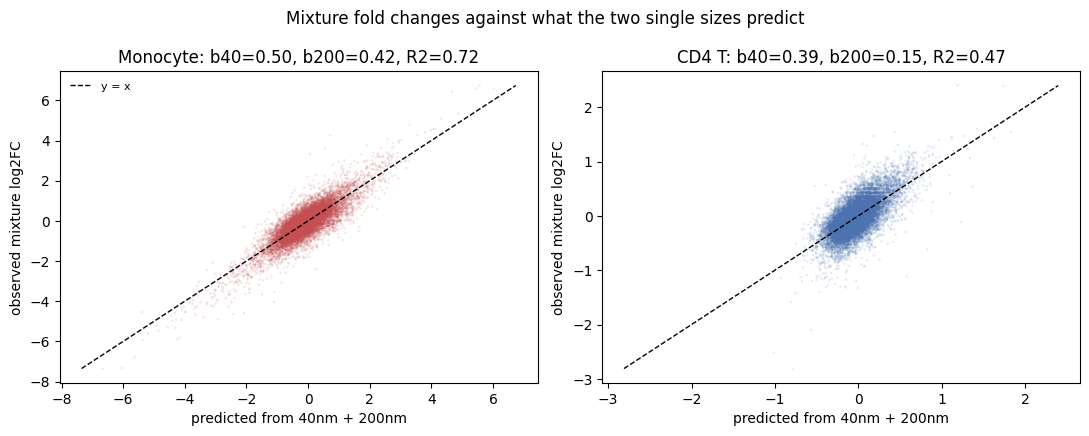

In [86]:
# The fit, drawn. The table says monocytes sum to 0.93 at R-squared 0.72; this shows what that
# looks like - and, importantly, that the residuals are scatter rather than a second structure
# hiding inside the fit. A mixture-specific program would appear here as a limb off the
# diagonal, not as noise around it.
_beta, _r2, _res, _d = FITS['Monocyte']
_pred = _beta[0] + _beta[1] * _d['40nm'] + _beta[2] * _d['200nm']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].scatter(_pred, _d['mixture'], s=3, alpha=0.15, color='#c44e52', edgecolors='none')
_lim = [min(_pred.min(), _d['mixture'].min()), max(_pred.max(), _d['mixture'].max())]
axes[0].plot(_lim, _lim, 'k--', lw=1, label='y = x')
axes[0].set(xlabel='predicted from 40nm + 200nm', ylabel='observed mixture log2FC',
            title=f'Monocyte: b40={_beta[1]:.2f}, b200={_beta[2]:.2f}, R2={_r2:.2f}')
axes[0].legend(frameon=False, fontsize=8)

# Same fit for one lymphocyte type, where the symmetric control showed the low coefficient sum
# is depth rather than biology - the point is the wider, rounder cloud, not a different shape.
_b2, _r22, _, _d2 = FITS['CD4 T']
_p2 = _b2[0] + _b2[1] * _d2['40nm'] + _b2[2] * _d2['200nm']
axes[1].scatter(_p2, _d2['mixture'], s=3, alpha=0.15, color='#4c72b0', edgecolors='none')
_lim2 = [min(_p2.min(), _d2['mixture'].min()), max(_p2.max(), _d2['mixture'].max())]
axes[1].plot(_lim2, _lim2, 'k--', lw=1)
axes[1].set(xlabel='predicted from 40nm + 200nm', ylabel='observed mixture log2FC',
            title=f'CD4 T: b40={_b2[1]:.2f}, b200={_b2[2]:.2f}, R2={_r22:.2f}')
fig.suptitle('Mixture fold changes against what the two single sizes predict')
fig.tight_layout()
plt.show()


### What Section 18 found

**In monocytes — the only cell type with a clean signal — the mixture is
additive.** The two single-size contrasts predict it with coefficients
summing to **0.93** at **R-squared 0.72**, much the best fit of any cell
type. The symmetric control confirms this rather than undermining it: all
three rotations return 0.85-0.93, so the mixture behaves like an ordinary
member of the set. Two particle sizes together produce **no response that
neither produces alone**.

**The apparent lymphocyte non-additivity is sequencing depth, not
biology.** Those cell types give 0.53-0.66 when predicting the mixture but
0.76-0.96 for the other two rotations — the mixture is the odd one out.
Depth explains it exactly: 40nm and 200nm are the two closest samples
(5,477 and 4,440 median counts) while the mixture sits at 6,373, far from
both and near control's 7,852. In the six cell types where Section 14
found zero clean pathways, fold change is largely depth and ambient RNA,
so the depth-adjacent pair predicts itself and the mixture does not.
Without the symmetric control, this would have been reported as a
mixture-specific lymphocyte response — the strongest-looking and most
wrong result available in this section.

**The residuals are noise.** The top-50 mixture-specific genes in
monocytes have a median max normalized count of 32.1 against 70.8 for the
genes in the fit, and the list is mostly lncRNAs. Nothing coherent
survives.

**The dissociation appears a third time.** Expression in the mixture is a
blend of the two single-size responses; composition is not — monocyte
*proportion* is flat in the mixture (-0.17pp) while the singles move it
-1.93 and +3.38, which no additive model reproduces, while monocyte
*expression* is additive at 0.93. Task 4 and Task 5 already answered
differently; Task 6 answered differently by axis; now the mixture is
additive on one axis and not the other.

**Caveats that travel with all of it.** One sample per condition, so this
is a three-point description, not a test — and the mixture being the
deepest exposed sample is a confound for the whole section, not only for
the lymphocyte rows.
